# Audit-first eight-window EEG experiment

New standalone notebook based on `braincodecamp-eight-window-cuda.ipynb`.
The original files are unchanged. **This is an experimental procedure, not a promise of 50% accuracy.**

Three retained procedures: classical features + CUDA SVM/LDA; scratch EEGNet/filter-bank CNN;
pretrained LaBraM frozen probe or fine-tuning. Added checks run before the full training loop.

Recommended workflow:

1. Run All with `RUN_DATA_AUDIT=True`, `RUN_EXPERIMENTS=False`. Review counts, alignment,
   timing metadata, outlier traces, mouth/eye activity and published report flags.
2. Optionally inspect a local raw BDF and run the small SVM decision-rule diagnostic.
   The EDA cells show published waves, preprocessing, spectra, and actual extracted features.
3. Enable training using smoke first. Evaluate each condition separately with shared
   original-trial splits across the three pipelines and channel counts.
4. Use pilot/full only after integrity checks pass. Compare representations inside the
   training folds, never by repeatedly selecting the best outer test result.

**Breaking scientific correction:** published FIF zero is the directional cue. The nominal
action crop is `[0.5,3.0)` cue-relative = `[1.0,3.5)` trial-start-relative.
Old runs used a different crop and probability-based SVM decisions. Their checkpoints are
not reused by this notebook; new code/config/data identities prevent accidental resume.


## Dependencies

Keep Kaggle's working PyTorch/CUDA installation. The optional installation cell supplies
the EEG libraries and checkpoint integration. Restart after an install if an import or ABI
error appears; do not mix an already-imported NumPy with a newly installed binary package.

Feature extraction and LDA run on CPU; SVM fitting defaults to CUDA. LaBraM feature extraction and both neural architectures use
CUDA automatically when available. CUDA SVM uses RAPIDS/cuML, with an explicit CPU mode available. No remote training job or paid service is launched.

PyWavelets is required for the new extractor. Burg AR estimation is vectorized NumPy code; statsmodels is not a runtime dependency.

In [1]:
INSTALL_EXTRA_PACKAGES = False
if INSTALL_EXTRA_PACKAGES:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "mne>=1.6,<2", "pyriemann>=0.7,<0.13", "braindecode[hub]==1.8.1",
        "scikit-learn>=1.4,<1.11", "cloudpickle>=3,<4", "tqdm", "matplotlib", "PyWavelets>=1.6,<2"
    ])
    print("Installation complete. Restart the kernel, set INSTALL_EXTRA_PACKAGES=False, then Run All.")

## Optional CUDA SVM installation

Enable a Kaggle T4. If cuML/CuPy already work, skip installation. Otherwise enable this
switch, install matching CUDA wheels with Internet enabled, restart the kernel, and turn
the switch off. Preserve Kaggle's working PyTorch installation.
[RAPIDS installation guide](https://docs.nvidia.com/datascience/install/).


In [2]:
INSTALL_CUDA_SVM = False  # only when cuML/CuPy is missing or incompatible
CUDA_MAJOR = 12           # match the runtime/toolkit; not the GPU model
if INSTALL_CUDA_SVM:
    import subprocess, sys, platform
    if platform.system() != "Linux":
        raise RuntimeError("Install/run RAPIDS on Linux Kaggle GPU, not macOS.")
    if CUDA_MAJOR not in (12, 13):
        raise ValueError("Choose CUDA_MAJOR 12 or 13 to match the runtime.")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        f"cuml-cu{CUDA_MAJOR}>=25.4,<27", f"cupy-cuda{CUDA_MAJOR}x",
        "--extra-index-url", "https://pypi.nvidia.com",
    ])
    print("Restart the kernel after installation. Leave this switch False, then Run All.")

## Easy settings — edit this cell

Auditing is on, training is off. All three pipeline switches are available; classical is
enabled initially for a cheap smoke check. Set all three to True to run all three.

`TRAIN_CONDITIONS=(1,)` runs inner speech only. Use `(1,0,2)` for separate inner, overt,
and visualized models; no mixing or cross-condition accuracy average is produced.
`CHANNEL_COUNTS=(128,)` means only 128, not automatically 64/32/16.

Keep `EPOCH_TIME_ORIGIN="cue"` for the published derivatives. `"trial_start"` is only
for genuinely shifted, full-length epochs whose saved extent is `[0,4.5]` seconds.
An incompatible extent raises an error instead of guessing the coordinate system.


In [3]:
PROFILE = "pilot"  # smoke -> pilot -> full; smoke is not a performance estimate
RUN_DATA_AUDIT = True
RUN_SVM_DECISION_AUDIT = True  # small diagnostic fits, not the full search
RUN_EXPERIMENTS = True       # enable only after inspecting QC
RUN_EDA = True                 # bounded wave/spectrum EDA, default training-only
RUN_EDA_FEATURES = True        # actual eight-window descriptors; no SVM fitting
RUN_EDA_REDUCTION_PREVIEW = True  # optional ANOVA demo on sampled inner-training rows

RUN_CLASSICAL = True
RUN_EEGNET = False
RUN_LABRAM = False

DATA_ROOT = "/kaggle/input/datasets/truthisneverlinear/inner-speech-recognition/inner-speech-recognition/derivatives"
OUTPUT_ROOT = "/kaggle/working/inner_speech_eight_window_audited"
CHANNEL_COUNTS = (128,)
SUBJECT_IDS = None if PROFILE == "full" else (1,)
CV_SEEDS = (42,)
RESUME = True
TRAIN_CONDITIONS = (1,)       # 1=inner, 0=overt, 2=visualized
EPOCH_TIME_ORIGIN = "cue"
CLASSICAL_FEATURE_SET = "combined"  # combined, eight_window, baseline
SVM_BACKEND = "cuda"         # actual binary cuML fitting, no silent CPU fallback
COMPARE_LONG_CROPS = True    # extra scratch EEGNet candidate in pilot/full

# Optional local raw BDF. Leave None if your Kaggle dataset has derivatives only.
RAW_BDF_PATH = None
RAW_SUBJECT = 1
RAW_SESSION = 1
RAW_TRIAL_ORDINAL = 0

# Descriptive EDA controls. These do not alter training configuration/checkpoints.
EDA_SUBJECT = None             # None = first configured subject
EDA_SESSION = None             # None = sample eligible trials across all sessions
EDA_CONDITIONS = (1, 0, 2)     # separate inner, overt, visualized panels
EDA_PARTITION = "inner_train"  # default excludes first inner validation + outer test
EDA_MAX_TRIALS_PER_CONDITION = 24
EDA_N_CHANNELS = None          # feature electrodes: None = first CHANNEL_COUNTS entry
EDA_DISPLAY_CHANNELS = ("A1", "B1", "C1", "D1")
EDA_CHANNEL = "A1"             # electrode for preprocessing/PSD/spectrogram plots
EDA_TRIAL_INDEX = 0            # row in EDA["meta"], not a raw-trigger index
EDA_WAVELET_WINDOW = 1         # 1..8; coefficient breakdown for this window


## What is being compared

| Procedure | Candidate representation/model | Fitted only on training trials |
|---|---|---|
| Classical | Eight-window AR/entropy/variance, optionally fused with bandpower; time-binned log bandpower; spatial-PCA + multiclass CSP; spatial-PCA + OAS covariance + Riemannian tangent space | Spatial projections, CSP, tangent reference, feature reduction, scaling, SVM/LDA |
| Scratch DL | EEGNet-inspired convolutional network with ordered temporal bins; compact FBCNet-inspired challenger | Channel scaling, weights, configuration, early-stopping duration |
| Pretrained | Frozen LaBraM features + PCA/logistic regression; last-two-block adaptation; full adaptation | Probe scaling/PCA/classifier, or adapted weights; winning strategy selected internally |

Classical ML selects between linear/RBF SVM and shrinkage LDA where enabled by the profile.
Scratch DL is still **one experimental procedure**, even if a different candidate wins for
different subjects/folds. The chosen model is recorded; do not label every scratch result
as standard EEGNet. The two scratch architectures are explicitly defined adaptations.

Only target-subject trials train the classical and scratch models. LaBraM starts from an
external pretrained checkpoint. This version does not add training from the other nine
dataset subjects, so that source of extra supervision is not mixed into the comparison.

The comparison uses the same outer trials and channel subsets. Search budgets differ by
computational cost and are recorded, rather than claiming equal compute or exhaustive tuning.

Pilot/full also include a scratch EEGNet candidate with three overlapping 1.5-second crops
at canonical `[1,2.5)`, `[1.5,3)`, `[2,3.5)`. Its view logits are averaged into **one trial
loss/prediction**; overlapping crops never cross folds or count as independent trials.
The full 2.5-second and late 2-second contexts remain available. Eight-window tabular
features still concatenate all eight windows into one trial row.

LaBraM retains frozen probes and partial/full fine-tuning. Scratch is the separate
EEGNet/filter-bank procedure, **not a new randomly initialized LaBraM control**.
Candidate selection compares complete procedures; OOF results alone do not establish
which individual representation is best. A prespecified representation ablation needs
separate fixed candidate lists on the same saved splits, not post-hoc test-score selection.


## Evaluation contract

For each subject and CV seed, save the outer folds once and reuse them for every pipeline
and channel count. Stratify by **session × class** when counts allow, otherwise by class.
This is a mixed-session, within-subject evaluation of new trials. It does not estimate
performance on an unseen subject or an unseen recording session.

Inside each outer-training set, inner CV chooses the candidate using balanced accuracy of
concatenated inner OOF predictions, with log loss as tie-breaker. Neural early stopping
monitors inner-validation cross-entropy. The selected candidate is then retrained on **all
outer-training trials** for the median of its selected inner epoch counts. The learning-rate
schedule retains the same horizon as during tuning. Only then is the outer test fold scored.

All views of an original trial stay together. Multi-view neural training computes one loss
per original trial. Frozen pretrained features can be cached for all trials because the
encoder is fixed, in evaluation mode, and learns no subject statistics; probe preprocessing
is still fitted inside each training split.

Final subject metrics come from exact OOF predictions, not averages of fold accuracies.
Repeated CV seeds are averaged within subjects; subjects then receive equal weight.
Bootstrap intervals resample subjects and are descriptive across-subject uncertainty,
not evidence from treating folds or trials as independent participants.

Do not choose settings, seeds, or participants by repeatedly inspecting outer scores.
Any later development informed by these results is exploratory until independently checked.

Separate conditions use the same seeds, fold counts and session/class stratification rules,
but not identical trial indices: they contain different actual trials/counts. These are
within-subject, across-trial folds, not unseen-session or unseen-subject evaluation.
Overt speech is a positive control with possible speech/muscle contamination, not proof
that an inner-speech decoder works. EXG channels are inspected, never fed to the models.


## Configuration and reproducibility

In [4]:
from __future__ import annotations
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import copy
import hashlib
import importlib.metadata
import itertools
import json
import math
import random
import re
import time
import warnings
from collections import OrderedDict
from dataclasses import dataclass, asdict, replace
from fractions import Fraction
from pathlib import Path

import cloudpickle
import numpy as np
import pandas as pd
from scipy import signal, stats
from scipy.special import softmax
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.covariance import oas
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, log_loss, classification_report)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm

VERSION = "insubject-eight-window-audited-1.0"
SOURCE_SHA256 = "development"  # replaced by the notebook builder
CLASSES = np.arange(4)
CLASS_NAMES = ("Up", "Down", "Right", "Left")
BANDS = ((2., 4.), (4., 8.), (8., 13.), (13., 20.), (20., 30.), (30., 45.))
WINDOWS = {"full": ((1., 3.5),), "late": ((1.5, 3.5),),
           "early": ((1., 3.),), "two_views": ((1., 3.), (1.5, 3.5)),
           "long_crops": ((1., 2.5), (1.5, 3.), (2., 3.5))}


@dataclass
class ExperimentConfig:
    data_root: str = "/kaggle/input/datasets/truthisneverlinear/inner-speech-recognition/inner-speech-recognition/derivatives"
    output_root: str = "/kaggle/working/inner_speech_optimized"
    profile: str = "smoke"
    subject_ids: tuple | None = (1,)
    channel_counts: tuple = (128,)
    pipelines: tuple = ("classical", "eegnet", "labram")
    cv_seeds: tuple = (42,)
    outer_folds: int = 2
    inner_folds: int = 2
    ensemble_seeds: tuple = (0,)
    max_epochs: int = 3
    min_epochs: int = 1
    patience: int = 2
    scratch_batch_size: int = 32
    labram_batch_size: int = 8
    amp: bool = True
    device: str = "auto"
    cpu_threads: int = 2
    resume: bool = True
    expected_sfreq: float = 256.
    epoch_time_origin: str = "cue"  # published FIF: -0.5..4 s, zero=directional cue
    condition_id: int = 1  # 0=overt, 1=inner, 2=visualized; never pool conditions
    require_data_audit: bool = True
    compare_long_crops: bool = True
    labram_repo: str = "braindecode/labram-pretrained"
    labram_revision: str = "0563b6c626e7b40d9a36653b763715db94d945d7"
    labram_offline: bool = False
    label_permutation_seed: int | None = None  # diagnostic only; labeled in every output
    # Optional explicit candidate lists. None selects the profile's documented list.
    svm_backend: str = "cpu"  # notebook default is CUDA; explicit CPU for local tests
    svm_calibration_folds: int = 3
    svm_cache_size: float = 512.
    svm_tol: float = 1e-3
    classical_feature_set: str = "combined"  # baseline, eight_window, or combined
    classical_candidates: tuple | None = None
    eegnet_candidates: tuple | None = None
    labram_candidates: tuple | None = None

    def validate(self):
        if self.profile not in ("smoke", "pilot", "full"):
            raise ValueError("profile must be smoke, pilot, or full")
        for field in ("channel_counts", "pipelines", "cv_seeds", "ensemble_seeds"):
            value = getattr(self, field)
            if not isinstance(value, (tuple, list)) or not value or len(set(value)) != len(value):
                raise ValueError(f"{field} must be a nonempty tuple with unique entries; use (128,), not (128)")
        if not set(self.channel_counts) <= {16, 32, 64, 128}:
            raise ValueError("Use channel counts 128, 64, 32, or 16")
        if not set(self.pipelines) <= {"classical", "eegnet", "labram"}:
            raise ValueError("Unknown pipeline")
        if self.subject_ids is not None and (not isinstance(self.subject_ids, (tuple, list)) or not self.subject_ids):
            raise ValueError("subject_ids must be None or a nonempty tuple")
        if min(self.outer_folds, self.inner_folds) < 2:
            raise ValueError("Both outer and inner CV need at least two folds")
        if not 1 <= self.min_epochs <= self.max_epochs or self.patience < 1:
            raise ValueError("Require 1 <= min_epochs <= max_epochs and patience >= 1")
        if self.cpu_threads < 1 or min(self.scratch_batch_size, self.labram_batch_size) < 1:
            raise ValueError("Thread count and batch sizes must be positive")
        if self.epoch_time_origin not in ("cue", "trial_start"):
            raise ValueError("Declare epoch_time_origin as cue or trial_start")
        if self.condition_id not in (0, 1, 2):
            raise ValueError("condition_id: 0=overt, 1=inner, 2=visualized")
        if self.svm_backend not in ("cpu", "cuda"):
            raise ValueError("svm_backend must be cpu or cuda; no silent CPU fallback")
        if self.svm_calibration_folds < 2 or self.svm_cache_size <= 0 or self.svm_tol <= 0:
            raise ValueError("Require at least two SVM calibration folds and positive cache/tolerance")
        if self.classical_feature_set not in ("baseline", "eight_window", "combined"):
            raise ValueError("classical_feature_set must be baseline, eight_window, or combined")
        for pipeline in self.pipelines:
            candidate_list(self, pipeline)
        return self


def make_config(profile="smoke", **overrides):
    presets = {
        "smoke": dict(subject_ids=(1,), outer_folds=2, inner_folds=2,
                      max_epochs=3, min_epochs=1, patience=2, ensemble_seeds=(0,)),
        "pilot": dict(subject_ids=(1,), outer_folds=5, inner_folds=3,
                      max_epochs=60, min_epochs=15, patience=12, ensemble_seeds=(0,)),
        "full": dict(subject_ids=None, outer_folds=5, inner_folds=3,
                     max_epochs=100, min_epochs=20, patience=15, ensemble_seeds=(0, 1, 2)),
    }
    if profile not in presets:
        raise ValueError(f"Unknown profile: {profile}")
    return ExperimentConfig(profile=profile, **(presets[profile] | overrides)).validate()


def serializable(value):
    if isinstance(value, (Path, np.dtype)):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Cannot serialize {type(value)}")


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=serializable).encode()).hexdigest()[:24]


def file_sha(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def relative_path(path, directory):
    # Resolve macOS /var -> /private/var aliases before computing a portable path.
    return os.path.relpath(Path(path).resolve(), Path(directory).resolve())


def save_json(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(value, indent=2, sort_keys=True, default=serializable) + "\n")
    temp.replace(path)


def save_csv(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False); temp.replace(path)


def save_pickle(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    with temp.open("wb") as f:
        cloudpickle.dump(value, f)
    temp.replace(path)


def read_pickle(path):
    # Only load checkpoint/event pickle files from sources you trust.
    with Path(path).open("rb") as f:
        return cloudpickle.load(f)


def package_versions():
    result = {}
    for name in ("numpy", "scipy", "pandas", "scikit-learn", "mne", "torch", "braindecode", "pyriemann", "cloudpickle", "PyWavelets", "cuml-cu12", "cuml-cu13", "cupy-cuda12x", "cupy-cuda13x"):
        try:
            result[name] = importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            result[name] = None
    return result


def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)


def metrics(y, prediction, probability=None):
    out = dict(accuracy=float(accuracy_score(y, prediction)),
               balanced_accuracy=float(balanced_accuracy_score(y, prediction)),
               macro_f1=float(f1_score(y, prediction, labels=CLASSES, average="macro", zero_division=0)))
    if probability is not None:
        probability = np.asarray(probability, np.float64)
        if not np.isfinite(probability).all() or (probability < 0).any() or not np.allclose(probability.sum(1), 1., atol=1e-5):
            raise ValueError("Invalid class probabilities")
        probability = probability / probability.sum(1, keepdims=True)
        out["log_loss"] = float(log_loss(y, probability, labels=CLASSES))
    return out

## Audited data loading and identical trial splits

The loader validates standardized labels 0..3 against FIF directional codes 31..34,
checks event timestamps, and aligns retained epochs without truncation. Condition IDs are
0 overt / 1 inner / 2 visualized. It selects canonical BioSemi128 electrodes and converts
MNE volts to microvolts. Channel reduction remains deterministic and geometry-only.

For published FIF epochs, `times=-0.5..4.0`, zero is the directional cue. The nominal
action interval is **cue-relative `[0.5,3.0)`**, exactly 640 samples at 256 Hz. Canonical
feature schema coordinates use trial-start `[1.0,3.5)` and also save epoch coordinates.
Raw action/relax triggers can have latency relative to these nominal values. The optional
raw audit measures that latency, but does not silently change the experimental crop.

The loader applies no new ICA, VMD, automatic interpolation, or trial rejection. Published
cleaning is inherited and recorded; current upstream preprocessing defaults are not assumed
to reproduce older published derivatives. Filtering is added to the action-only signal.

Sources: [authors' preprocessing](https://github.com/N-Nieto/Inner_Speech_Dataset/blob/main/Python_Processing/InnerSpeech_preprocessing.py),
[dataset](https://openneuro.org/datasets/ds003626),
[authors' EMG reporting](https://github.com/N-Nieto/Inner_Speech_Dataset/blob/main/Python_Processing/lib/EMG_Control.py).


In [5]:
def discover_recordings(root):
    records = []
    for path in sorted(Path(root).rglob("*_eeg-epo.fif")):
        match = re.search(r"sub-(\d+)_ses-(\d+)_eeg-epo\.fif$", path.name)
        if not match:
            continue
        subject, session = map(int, match.groups())
        events = path.with_name(path.name.replace("_eeg-epo.fif", "_events.dat"))
        if not events.exists():
            raise FileNotFoundError(events)
        records.append((subject, session, path, events))
    if not records:
        raise FileNotFoundError(f"No processed sub-XX_ses-XX_eeg-epo.fif files below {root}")
    if len({(s, r) for s, r, *_ in records}) != len(records):
        raise ValueError("Duplicate subject/session recordings: point DATA_ROOT at one dataset version")
    return records


def load_subject(cfg, subject):
    import mne
    names = mne.channels.make_standard_montage("biosemi128").ch_names
    blocks, rows, provenance = [], [], []
    for sid, session, path, event_path in discover_recordings(cfg.data_root):
        if sid != subject:
            continue
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        if not np.isclose(epochs.info["sfreq"], cfg.expected_sfreq):
            raise ValueError(f"{path.name}: expected processed {cfg.expected_sfreq} Hz data")
        labels, conditions = read_event_table(event_path, epochs)
        if set(names) - set(epochs.ch_names):
            raise ValueError("The recording does not contain the 128 BioSemi EEG electrodes")
        epochs.pick(names).reorder_channels(names)
        mask, convention = action_time_mask(epochs, cfg)
        selected = np.flatnonzero(conditions == cfg.condition_id)
        # Only action samples enter our added filters, preventing extra pre-cue smearing.
        X = epochs.get_data(copy=True)[selected][:, :, mask].astype(np.float32) * 1e6
        if not np.isfinite(X).all():
            raise ValueError("Nonfinite EEG; inspect the source rather than silently imputing waveforms")
        blocks.append(X)
        for index in selected:
            rows.append(dict(subject=sid, session=session, condition=cfg.condition_id,
                             condition_name=CONDITION_NAMES[cfg.condition_id], y_true=int(labels[index]),
                             trial_id=f"sub-{sid:02d}_ses-{session:02d}_row-{int(epochs.selection[index]):04d}"))
        provenance.append(dict(eeg_name=path.name, eeg_sha256=file_sha(path),
                               events_name=event_path.name, events_sha256=file_sha(event_path),
                               trials=len(selected), time_convention=convention,
                               sfreq=float(epochs.info["sfreq"]),
                               highpass=float(epochs.info["highpass"]), lowpass=float(epochs.info["lowpass"])))
    if not blocks:
        raise ValueError(f"No trials for subject {subject}")
    meta = pd.DataFrame(rows)
    if meta.trial_id.duplicated().any() or set(meta.y_true) != set(CLASSES):
        raise ValueError("Duplicate trial IDs or missing classes")
    X = np.concatenate(blocks)
    amplitude = np.std(X, axis=-1)
    print(f"Subject {subject:02d} ({CONDITION_NAMES[cfg.condition_id]}): {len(meta)} trials; counts {meta.y_true.value_counts().sort_index().to_dict()}; "
          f"median channel SD {np.median(amplitude):.2f} microvolts")
    audit = dict(provenance=provenance, channel_order=names, units="microvolts",
                 canonical_action_interval=[1., 3.5], time_convention=convention, condition_id=cfg.condition_id,
                 shape=list(X.shape), channel_sd_percentiles=np.percentile(amplitude, [0, 1, 50, 99, 100]).tolist(),
                 no_extra_vmd_ica_or_trial_rejection=True)
    return X, names, meta, audit


def channel_subsets(names):
    import mne
    positions = mne.channels.make_standard_montage("biosemi128").get_positions()["ch_pos"]
    xyz = np.array([positions[name] for name in names])
    chosen = [int(np.argmax(xyz[:, 2]))]
    while len(chosen) < len(names):
        distances = np.linalg.norm(xyz[:, None] - xyz[chosen][None], axis=-1).min(axis=1)
        distances[chosen] = -np.inf
        chosen.append(int(np.argmax(distances)))
    return {128: np.arange(len(names)), **{n: np.asarray(chosen[:n]) for n in (64, 32, 16)}}


def stratified_splits(y, sessions, n_folds, seed):
    y, sessions = np.asarray(y), np.asarray(sessions)
    if set(y) != set(CLASSES) or np.bincount(y, minlength=4).min() < n_folds:
        raise ValueError(f"Insufficient trials per class for {n_folds} folds")
    joint = np.asarray([f"{s}_{c}" for s, c in zip(sessions, y)])
    counts = pd.Series(joint).value_counts()
    stratify = joint if counts.min() >= n_folds else y
    mode = "session_and_class" if counts.min() >= n_folds else "class_only"
    splits = list(StratifiedKFold(n_folds, shuffle=True, random_state=seed).split(y, stratify))
    coverage = np.zeros(len(y), int)
    for train, test in splits:
        if set(train) & set(test):
            raise AssertionError("Overlapping train/test trials")
        coverage[test] += 1
    if not np.all(coverage == 1):
        raise AssertionError("CV must predict every original trial exactly once")
    return splits, mode


def make_split_plan(meta, cfg, seed):
    outer, mode = stratified_splits(meta.y_true, meta.session, cfg.outer_folds, seed)
    plans = []
    for fold, (train, test) in enumerate(outer, 1):
        inner, inner_mode = stratified_splits(meta.y_true.iloc[train], meta.session.iloc[train],
                                             cfg.inner_folds, seed + fold * 1009)
        plans.append(dict(fold=fold, train=train.tolist(), test=test.tolist(),
                          inner=[dict(train=train[a].tolist(), validation=train[b].tolist()) for a, b in inner],
                          stratification=mode, inner_stratification=inner_mode))
    return dict(seed=int(seed), trial_ids=meta.trial_id.tolist(), labels=meta.y_true.tolist(), folds=plans)

## Timing, condition, and signal-quality investigation — definitions

These functions are invoked after configuration, before the training runner.

In [6]:
CONDITION_NAMES = {0: "overt", 1: "inner", 2: "visualized"}
TIME_CONVENTION = {
    "canonical_origin": "trial_start",
    "canonical_action_seconds": [1., 3.5],
    "cue_onset_canonical_seconds": .5,
    "published_FIF_origin": "directional_cue",
    "published_FIF_extent_seconds": [-.5, 4.],
    "published_FIF_nominal_action_seconds": [.5, 3.],
    "interval_rule": "left_closed_right_open",
    "timing_type": "nominal_protocol_not_measured_trigger_latency",
}


def action_time_mask(epochs, cfg):
    """Require the declared coordinate system; never infer/guess from data values."""
    sfreq = float(epochs.info["sfreq"])
    if not np.isclose(sfreq, cfg.expected_sfreq):
        raise ValueError(f"Expected {cfg.expected_sfreq} Hz processed epochs; found {sfreq}")
    offset = .5 if cfg.epoch_time_origin == "cue" else 0.
    expected = (-.5, 4.) if cfg.epoch_time_origin == "cue" else (0., 4.5)
    if not np.allclose([epochs.times[0], epochs.times[-1]], expected, atol=.51/sfreq):
        raise ValueError(f"Declared {cfg.epoch_time_origin} origin expects {expected}, found "
                         f"{(epochs.times[0], epochs.times[-1])}. Verify provenance; do not guess.")
    interval = np.array([1., 3.5]) - offset
    mask = (epochs.times >= interval[0]-1e-9) & (epochs.times < interval[1]-1e-9)
    if mask.sum() != round(2.5*sfreq):
        raise ValueError("The nominal action interval does not have exactly 2.5 seconds of samples")
    return mask, TIME_CONVENTION | dict(declared_epoch_origin=cfg.epoch_time_origin,
                                      epoch_action_seconds=interval.tolist(), sfreq=sfreq)


def original_directional_rows(epochs):
    # MNE selection can refer to ALL raw triggers; reports/events index directional epochs.
    directional = np.flatnonzero([tuple(reasons) != ("IGNORED",) for reasons in epochs.drop_log])
    mapping = {int(raw_index): ordinal for ordinal, raw_index in enumerate(directional)}
    if any(int(index) not in mapping for index in epochs.selection):
        raise ValueError("Cannot map MNE selection to directional event rows")
    return np.array([mapping[int(index)] for index in epochs.selection], int), len(directional)


def read_event_table(path, epochs):
    """Accept official trusted pickle or the authors' newer CSV, aligning retained rows."""
    path = Path(path)
    with path.open("rb") as handle:
        is_pickle = handle.read(1) == b"\x80"
    table = pd.read_pickle(path) if is_pickle else pd.read_csv(path)
    if isinstance(table, pd.DataFrame):
        columns = {str(k).strip().lower(): k for k in table.columns}
        label = columns.get("code", columns.get("label"))
        condition = columns.get("condition")
        timestamp = columns.get("time", columns.get("sample"))
        if label is None or condition is None:
            raise ValueError(f"Unrecognized event columns: {list(table.columns)}")
        labels, conditions = table[label].to_numpy(), table[condition].to_numpy()
        samples = None if timestamp is None else table[timestamp].to_numpy()
    else:
        array = np.asarray(table)
        if array.ndim != 2 or array.shape[1] < 4:
            raise ValueError(f"Invalid event matrix: {path}")
        samples, labels, conditions = array[:, 0], array[:, 1], array[:, 2]
    if len(labels) == len(epochs.drop_log):
        retained = epochs.selection
    elif len(labels) == original_directional_rows(epochs)[1]:
        retained = original_directional_rows(epochs)[0]
    elif len(labels) == len(epochs):
        retained = np.arange(len(labels))
    else:
        raise ValueError(f"Epoch/event row mismatch: {path}; no truncation")
    labels, conditions = labels[retained], conditions[retained]
    if not np.isin(labels, CLASSES).all() or not np.isin(conditions, (0, 1, 2)).all():
        raise ValueError("Expected standardized labels 0..3 and conditions 0..2")
    if not np.array_equal(epochs.events[:, 2], labels.astype(int)+31):
        raise ValueError("FIF directional markers (31..34) do not match standardized labels")
    if samples is not None and not np.array_equal(samples[retained], epochs.events[:, 0]):
        raise ValueError("Event timestamps do not match FIF event sample indices")
    return labels.astype(int), conditions.astype(int)


def source_fingerprints(cfg):
    records = discover_recordings(cfg.data_root)
    available = {s for s, *_ in records}
    subjects = available if cfg.subject_ids is None else set(cfg.subject_ids)
    if subjects - available:
        raise ValueError(f"Missing subjects: {sorted(subjects-available)}")
    result = []
    for subject, session, eeg, events in records:
        if subject not in subjects:
            continue
        for path in (eeg, events, eeg.with_name(eeg.name.replace("_eeg-epo.fif", "_exg-epo.fif")),
                     eeg.with_name(eeg.name.replace("_eeg-epo.fif", "_report.pkl"))):
            if path.exists():
                stat = path.stat()
                result.append(dict(subject=subject, session=session, path=str(path.resolve()),
                                   size=stat.st_size, mtime_ns=stat.st_mtime_ns))
    return result


def dataset_audit_identity(cfg):
    # Fast invalidation for exploratory QC; training checkpoints separately hash EEG/events content.
    return digest(dict(sources=source_fingerprints(cfg), origin=cfg.epoch_time_origin,
                       sfreq=cfg.expected_sfreq, code=code_identity()))


def dataset_audit_directory(cfg):
    return Path(cfg.output_root) / "investigation" / dataset_audit_identity(cfg)


def require_dataset_audit(cfg):
    if not cfg.require_data_audit:
        return
    marker = dataset_audit_directory(cfg) / "audit_manifest.json"
    if not marker.exists() or not json.loads(marker.read_text()).get("integrity_passed"):
        raise RuntimeError("Run the pre-training dataset audit successfully first. "
                           "Review its plots/flags; flags do not automatically remove trials.")


def report_flags(path, epochs):
    report_path = path.with_name(path.name.replace("_eeg-epo.fif", "_report.pkl"))
    if not report_path.exists():
        return set(), dict(available=False, note="No published report; no EMG flag assumed")
    report = read_pickle(report_path)
    if not isinstance(report, dict):
        raise ValueError(f"Expected report dictionary: {report_path}")
    flags = np.asarray(report.get("EMG_trials", []))
    original_rows, original_count = original_directional_rows(epochs)
    if flags.size and (flags.ndim != 1 or not np.isfinite(flags).all() or
                       not np.all(flags == flags.astype(int)) or
                       np.any(flags < 0) or np.any(flags >= original_count)):
        raise ValueError(f"Unrecognized directional-row EMG indices: {report_path}")
    # The published report was computed on the exported EXG order, not raw-trigger indices.
    if any(reasons and tuple(reasons) != ("IGNORED",) for reasons in epochs.drop_log):
        return set(), dict(available=True, indexing_verified=False, name=report_path.name, values=report,
                           note="Additional dropped epochs: report export order cannot be verified; flags not applied")
    mapped_flags = set(epochs.selection[np.isin(original_rows, flags.astype(int))].astype(int).tolist())
    return mapped_flags, dict(available=True, indexing_verified=True, name=report_path.name, values=report,
                                                keys=sorted(map(str, report)), original_row_EMG_flags=flags.tolist(),
                                                indexing="zero_based_exported_directional_epoch_order_mapped_to_MNE_selection")


def run_dataset_audit(cfg, *, batch_size=16, plot_top=3, sd_flag_uv=100.,
                      ptp_flag_uv=500., flat_sd_uv=.1):
    """All conditions, BEFORE learning: retain every finite trial regardless of QC flags.

    Thresholds are descriptive, specified in advance, and not fitted to labels or scores.
    This reads processed EEG/EXG, not a claim to have repeated the authors' ICA.
    """
    import mne
    import matplotlib.pyplot as plt
    cfg.validate()
    if batch_size < 1 or plot_top < 0 or min(sd_flag_uv, ptp_flag_uv, flat_sd_uv) <= 0:
        raise ValueError("Require positive batch/threshold values and nonnegative plot_top")
    directory = dataset_audit_directory(cfg)
    directory.mkdir(parents=True, exist_ok=True)
    # Close a previous success marker while re-auditing. Any interrupted/failed rerun stays closed.
    save_json(dict(identity=dataset_audit_identity(cfg), integrity_passed=False, status="running"),
              directory / "audit_manifest.json")
    records = discover_recordings(cfg.data_root)
    subjects = {s for s, *_ in records} if cfg.subject_ids is None else set(cfg.subject_ids)
    names = mne.channels.make_standard_montage("biosemi128").ch_names
    trial_rows, channel_frames, metadata = [], [], []
    finite = True
    save_json(dict(time_convention=TIME_CONVENTION, declared_origin=cfg.epoch_time_origin,
                   sd_flag_uv=sd_flag_uv, ptp_flag_uv=ptp_flag_uv, flat_sd_uv=flat_sd_uv,
                   rejection="none", use_of_test_scores="none", source_fingerprints=source_fingerprints(cfg)),
              directory / "audit_settings.json")
    for subject, session, path, events in records:
        if subject not in subjects:
            continue
        epochs = mne.read_epochs(path, preload=False, verbose=False)
        mask, convention = action_time_mask(epochs, cfg)
        labels, conditions = read_event_table(events, epochs)
        if set(names) - set(epochs.ch_names):
            raise ValueError(f"Missing BioSemi128 electrodes: {path}")
        flags, report = report_flags(path, epochs)
        exg_path = path.with_name(path.name.replace("_eeg-epo.fif", "_exg-epo.fif"))
        exg = mne.read_epochs(exg_path, preload=False, verbose=False) if exg_path.exists() else None
        if exg is not None:
            exg_mask, _ = action_time_mask(exg, cfg)
            if not np.array_equal(exg.events, epochs.events) or not np.array_equal(exg.selection, epochs.selection):
                raise ValueError(f"EEG/EXG retained-trial alignment differs: {path}")
        metadata.append(dict(subject=subject, session=session, n_trials=len(epochs),
                             epoch_extent_seconds=[float(epochs.tmin), float(epochs.tmax)],
                             time_convention=convention, highpass=float(epochs.info["highpass"]),
                             lowpass=float(epochs.info["lowpass"]), bad_channels=list(epochs.info["bads"]),
                             exg_available=exg is not None, report=report))
        record_rows = []
        for start in range(0, len(epochs), batch_size):
            stop = min(start+batch_size, len(epochs))
            data = epochs[start:stop].get_data(picks=names, copy=True)[..., mask]*1e6
            sd, ptp = data.std(-1), np.ptp(data, axis=-1)
            valid = np.isfinite(data).all(axis=(1, 2))
            finite &= bool(valid.all())
            extra = None if exg is None else exg[start:stop].get_data(copy=True)[..., exg_mask]*1e6
            if extra is not None:
                finite &= bool(np.isfinite(extra).all())
            for local, row_index in enumerate(range(start, stop)):
                original = int(epochs.selection[row_index])
                trial_id = f"sub-{subject:02d}_ses-{session:02d}_row-{original:04d}"
                row = dict(subject=subject, session=session, condition=int(conditions[row_index]),
                           condition_name=CONDITION_NAMES[int(conditions[row_index])], y_true=int(labels[row_index]),
                           trial_id=trial_id, retained_row=row_index, original_row=original,
                           cue_sample=int(epochs.events[row_index, 0]), finite_EEG=bool(valid[local]),
                           median_channel_sd_uv=float(np.median(sd[local])), max_channel_sd_uv=float(sd[local].max()),
                           max_channel_ptp_uv=float(ptp[local].max()),
                           max_sd_channel=names[int(np.argmax(sd[local]))],
                           channels_high_sd=int((sd[local] > sd_flag_uv).sum()),
                           channels_high_ptp=int((ptp[local] > ptp_flag_uv).sum()),
                           channels_flat=int((sd[local] < flat_sd_uv).sum()), report_EMG_flag=original in flags)
                channel_frames.append(pd.DataFrame(dict(trial_id=trial_id, channel=names, sd_uv=sd[local],
                                                         ptp_uv=ptp[local], high_sd=sd[local] > sd_flag_uv,
                                                         high_ptp=ptp[local] > ptp_flag_uv, flat=sd[local] < flat_sd_uv)))
                if extra is not None:
                    for index, name in enumerate(exg.ch_names):
                        row[name+"_sd_uv"] = float(extra[local, index].std())
                        row[name+"_ptp_uv"] = float(np.ptp(extra[local, index]))
                    for name in ("EXG3", "EXG4", "EXG5", "EXG6", "EXG7", "EXG8"):
                        if name in exg.ch_names and valid[local]:
                            e = extra[local, exg.ch_names.index(name)]
                            d = data[local] - data[local].mean(-1, keepdims=True)
                            centered = e-e.mean()
                            denominator = np.linalg.norm(d, axis=-1)*np.linalg.norm(centered)
                            correlations = np.divide(d @ centered, denominator, out=np.zeros(128), where=denominator > 0)
                            row[name+"_max_abs_EEG_correlation"] = float(np.max(np.abs(correlations)))
                record_rows.append(row); trial_rows.append(row)
        # Illustrative highest-amplitude trials, not a score-driven rejection list.
        worst = sorted(record_rows, key=lambda r: r["max_channel_sd_uv"], reverse=True)[:plot_top]
        for rank, row in enumerate(worst, 1):
            index = row["retained_row"]
            one = epochs[index:index+1].get_data(picks=names, copy=True)[0][:, mask]*1e6
            selected = np.argsort(one.std(-1))[-4:][::-1]
            time_axis = epochs.times[mask]
            fig, axes = plt.subplots(2 if exg is not None else 1, 1, figsize=(12, 6), squeeze=False)
            for electrode in selected:
                axes[0, 0].plot(time_axis, one[electrode], label=names[electrode], alpha=.8)
            axes[0, 0].set(ylabel="Processed EEG (µV)", title=f"{row['trial_id']} | {row['condition_name']} | "
                           f"label {CLASS_NAMES[row['y_true']]} | no additional filtering")
            axes[0, 0].legend()
            if exg is not None:
                extra = exg[index:index+1].get_data(copy=True)[0][:, exg_mask]*1e6
                for name in ("EXG3", "EXG4", "EXG7", "EXG8"):
                    if name in exg.ch_names:
                        axes[1, 0].plot(time_axis, extra[exg.ch_names.index(name)], label=name, alpha=.7)
                axes[1, 0].set(ylabel="Processed EXG (µV)"); axes[1, 0].legend()
            axes[-1, 0].set_xlabel(f"Seconds relative to {cfg.epoch_time_origin} onset (nominal action only)")
            fig.tight_layout(); fig.savefig(directory / f"sub-{subject:02d}_ses-{session:02d}_outlier-{rank}.png", dpi=130)
            plt.close(fig)
        print(f"Audited subject {subject:02d}, session {session:02d}: {len(epochs)} trials, all conditions; "
              f"EEG/EXG={'yes' if exg is not None else 'EEG only'}")
    trials = pd.DataFrame(trial_rows)
    channels = pd.concat(channel_frames, ignore_index=True)
    counts = trials.groupby(["subject", "session", "condition", "condition_name", "y_true"], as_index=False).size()
    descriptive = trials.groupby(["subject", "condition_name"], as_index=False).agg(
        n_trials=("trial_id", "size"), median_trial_channel_sd_uv=("median_channel_sd_uv", "median"),
        maximum_channel_sd_uv=("max_channel_sd_uv", "max"), EMG_report_flags=("report_EMG_flag", "sum"))
    save_csv(trials, directory / "trial_quality.csv"); save_csv(channels, directory / "channel_quality.csv")
    save_csv(counts, directory / "condition_class_counts.csv"); save_csv(descriptive, directory / "condition_quality_summary.csv")
    save_csv(trials.nlargest(min(30, len(trials)), "max_channel_sd_uv"), directory / "largest_amplitude_trials.csv")
    save_json(metadata, directory / "recordings.json")
    save_json(dict(identity=dataset_audit_identity(cfg), integrity_passed=finite, time_convention=TIME_CONVENTION,
                   trials_inspected=len(trials), trials_rejected=0, flags_are_descriptive=True,
                   source_identity="path_size_mtime_for_QC; content_SHA256_for_training", reports=metadata),
              directory / "audit_manifest.json")
    if not finite:
        raise ValueError(f"Nonfinite EEG/EXG found: inspect {directory}; training gate stays closed")
    print(f"QC complete: {directory}. Flags are not exclusions. Review before enabling training.")
    return dict(directory=directory, trials=trials, channels=channels, counts=counts, summary=descriptive)


def raw_trigger_timings(events, sfreq):
    """Measured cue→action/relax offsets, bounded by the next directional cue."""
    events = np.asarray(events, int)
    cues = np.flatnonzero(np.isin(events[:, 2], (31, 32, 33, 34)))
    rows = []
    for ordinal, index in enumerate(cues):
        cue = events[index, 0]
        stop = cues[ordinal+1] if ordinal+1 < len(cues) else len(events)
        following = events[index+1:stop]
        row = dict(cue_sample=int(cue), direction_code=int(events[index, 2]))
        for code, name in ((44, "action"), (45, "relax"), (46, "rest")):
            found = following[following[:, 2] == code, 0]
            row[name+"_offset_seconds"] = float((found[0]-cue)/sfreq) if len(found) == 1 else np.nan
            row[name+"_marker_count"] = len(found)
        row["measured_action_duration_seconds"] = row["relax_offset_seconds"]-row["action_offset_seconds"]
        rows.append(row)
    return pd.DataFrame(rows)


def inspect_raw_recording(raw_path, cfg, subject=1, session=1, trial_ordinal=0):
    """Optional local BDF inspection; no downloads, reprocessing, or model selection."""
    import mne
    import matplotlib.pyplot as plt
    raw = mne.io.read_raw_bdf(raw_path, preload=False, verbose=False)
    events = mne.find_events(raw, stim_channel="Status", shortest_event=1,
                             mask=0xffff, mask_type="and", verbose=False)
    timings = raw_trigger_timings(events, raw.info["sfreq"])
    if not 0 <= trial_ordinal < len(timings):
        raise ValueError("Raw trial ordinal is out of range")
    directory = dataset_audit_directory(cfg) / "raw"; directory.mkdir(parents=True, exist_ok=True)
    save_csv(timings, directory / f"sub-{subject:02d}_ses-{session:02d}_trigger_timings.csv")
    matches = [r for r in discover_recordings(cfg.data_root) if r[:2] == (subject, session)]
    if len(matches) != 1:
        raise ValueError("Need one corresponding processed subject/session recording")
    epochs = mne.read_epochs(matches[0][2], preload=False, verbose=False)
    _, convention = action_time_mask(epochs, cfg)
    cue = int(timings.iloc[trial_ordinal].cue_sample)
    matched = np.flatnonzero(epochs.events[:, 0] == cue)
    if len(matched) != 1:
        raise ValueError("Raw cue timestamp cannot be matched to one retained processed trial")
    origin_offset = .5 if cfg.epoch_time_origin == "trial_start" else 0.
    start = max(0, cue+round((epochs.tmin-origin_offset)*raw.info["sfreq"])-raw.first_samp)
    stop = min(raw.n_times, cue+round((epochs.tmax-origin_offset)*raw.info["sfreq"])-raw.first_samp+1)
    picks = [n for n in ("A1", "EXG1", "EXG2", "EXG3", "EXG4", "EXG7", "EXG8") if n in raw.ch_names]
    raw_data = raw.get_data(picks=picks, start=start, stop=stop)*1e6
    t_raw = (np.arange(start, stop)+raw.first_samp-cue)/raw.info["sfreq"]
    processed = epochs[matched].get_data(picks=["A1"], copy=True)[0, 0]*1e6
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    if "A1" in picks:
        a1 = raw_data[picks.index("A1")]
        axes[0].plot(t_raw, a1, label="Raw A1, acquisition reference", alpha=.5)
        if "EXG1" in picks and "EXG2" in picks:
            referenced = a1-(raw_data[picks.index("EXG1")]+raw_data[picks.index("EXG2")])/2
            axes[0].plot(t_raw, referenced, label="Raw A1 minus mean ears (no cleaning)", alpha=.6)
    axes[0].plot(epochs.times-origin_offset, processed, label="Published processed A1", alpha=.8)
    for name in ("EXG3", "EXG4", "EXG7", "EXG8"):
        if name in picks:
            axes[1].plot(t_raw, raw_data[picks.index(name)], label="Raw "+name, alpha=.7)
    for ax in axes:
        ax.axvspan(.5, 3., color="green", alpha=.08, label="Nominal action")
        for name in ("action", "relax"):
            value = timings.iloc[trial_ordinal][name+"_offset_seconds"]
            if np.isfinite(value):
                ax.axvline(value, linestyle="--", color="black", alpha=.6)
        ax.set(ylabel="µV"); ax.legend(fontsize=8)
    axes[1].set_xlabel("Seconds relative to directional cue; dashed lines = measured action/relax triggers")
    fig.tight_layout(); fig.savefig(directory / f"sub-{subject:02d}_ses-{session:02d}_trial-{trial_ordinal}_raw_processed.png", dpi=130)
    plt.close(fig)
    save_json(dict(raw_path=str(Path(raw_path).resolve()), raw_sfreq=float(raw.info["sfreq"]),
                   raw_channels=raw.ch_names, cue_sample=cue, processed_trial_index=int(matched[0]),
                   time_convention=convention, preprocessing="published FIF; not newly reprocessed", 
                   cropping="main experiment uses nominal action, not these measured triggers"), directory / "raw_inspection.json")
    return timings


def prediction_audit(y, direct, probability):
    probability_labels = CLASSES[np.asarray(probability).argmax(1)]
    return dict(direct_accuracy=float(accuracy_score(y, direct)),
                direct_balanced_accuracy=float(balanced_accuracy_score(y, direct)),
                probability_argmax_accuracy=float(accuracy_score(y, probability_labels)),
                probability_argmax_balanced_accuracy=float(balanced_accuracy_score(y, probability_labels)),
                disagreement_rate=float(np.mean(np.asarray(direct) != probability_labels)))


def run_svm_prediction_audit(cfg, subject=None, n_channels=16):
    """Two fixed diagnostic SVMs, ONLY first inner split of first outer TRAIN partition.

    No outer test scoring or automatic candidate/threshold choice. Main nested selection
    subsequently chooses using direct predictions, with its own saved probability audit.
    """
    require_dataset_audit(cfg)
    if subject is None:
        subject = sorted({s for s, *_ in discover_recordings(cfg.data_root)})[0] if cfg.subject_ids is None else cfg.subject_ids[0]
    X, names, meta, audit = load_subject(cfg, subject)
    subset = channel_subsets(names)[n_channels]
    views = SubjectViews(X[:, subset], cfg.expected_sfreq)
    plan = make_split_plan(meta, cfg, cfg.cv_seeds[0])["folds"][0]
    split = plan["inner"][0]
    train, validation = np.array(split["train"]), np.array(split["validation"])
    if set(validation) & set(plan["test"]):
        raise AssertionError("Diagnostic validation leaked into outer test")
    directory = dataset_audit_directory(cfg) / f"svm_{CONDITION_NAMES[cfg.condition_id]}"
    summaries = []
    for kernel in ("linear", "rbf"):
        spec = dict(representation="bandpower", view="full", classifier="svm", kernel=kernel,
                    C=1., gamma="scale", dimension=32, svm_backend=cfg.svm_backend,
                    svm_calibration_folds=cfg.svm_calibration_folds, svm_cache_size=cfg.svm_cache_size, svm_tol=cfg.svm_tol)
        data = classical_data(views, spec)
        model = build_classical(spec, int(cfg.cv_seeds[0])).fit(data[train], meta.y_true.to_numpy()[train])
        for stage, indices in (("training", train), ("inner_validation", validation)):
            direct, probability = model.predict(data[indices]), model.predict_proba(data[indices])
            rows = meta.iloc[indices].copy()
            rows["y_pred"] = direct; rows["y_pred_probability"] = probability.argmax(1)
            rows["prediction_disagreement"] = rows.y_pred != rows.y_pred_probability
            for c in CLASSES:
                rows[f"p_{c}"] = probability[:, c]
            save_csv(rows, directory / f"{kernel}_{stage}_predictions.csv")
            summaries.append(dict(subject=subject, n_channels=n_channels, kernel=kernel, stage=stage,
                                  **prediction_audit(rows.y_true, direct, probability)))
        save_pickle(model, directory / f"{kernel}_diagnostic_estimator.pkl")
        if isinstance(model.named_steps["classifier"], PortableCudaSVC):
            save_json(model.named_steps["classifier"].metadata(), directory / f"{kernel}_backend.json")
    save_json(dict(subject=subject, seed=int(cfg.cv_seeds[0]), train=train, validation=validation,
                   excluded_outer_test=plan["test"], trial_ids=meta.trial_id.tolist(),
                   purpose="prediction_rule_diagnostic_not_hyperparameter_selection"), directory / "split.json")
    frame = pd.DataFrame(summaries); save_csv(frame, directory / "decision_audit.csv")
    return frame


def run_condition_experiments(cfg, condition_ids=(1,)):
    """Separate subjects/models/splits/results for each condition; no cross-condition pooling."""
    if not isinstance(condition_ids, (tuple, list)) or not condition_ids or len(set(condition_ids)) != len(condition_ids):
        raise ValueError("condition_ids must be a nonempty unique tuple, e.g. (1,) or (1,0,2)")
    if not set(condition_ids) <= set(CONDITION_NAMES):
        raise ValueError("Conditions: 0=overt, 1=inner, 2=visualized")
    require_dataset_audit(cfg)
    results, summaries = {}, []
    for condition in condition_ids:
        active = replace(cfg, condition_id=int(condition),
                         output_root=str(Path(cfg.output_root) / "conditions" / CONDITION_NAMES[condition]),
                         require_data_audit=False)
        result = run_experiments(active)
        result["summary"]["condition"] = int(condition)
        result["summary"]["condition_name"] = CONDITION_NAMES[condition]
        save_csv(result["summary"], result["directory"] / "summary.csv")
        results[CONDITION_NAMES[condition]] = result
        summaries.append(result["summary"])
    combined = pd.concat(summaries, ignore_index=True)
    save_csv(combined, Path(cfg.output_root) / "condition_comparison_summary.csv")
    return dict(conditions=results, summary=combined)

## Deterministic signal views and compact classical representations

The six filter bands are 2–4, 4–8, 8–13, 13–20, 20–30, and 30–45 Hz. Fixed fourth-order
Butterworth filters run separately on each trial. Their coefficients use no dataset estimates.
Bandpower features retain both the whole-window power and three ordered temporal bins.
Spatial PCA and all feature selection are fitted again inside each training split.

Riemannian candidates use OAS covariance shrinkage and an affine-invariant tangent-space
reference learned from training trials only (`tsupdate=False`). A compact PCA representation
then regularizes the classifier. This is not an all-electrode connectivity interpretation.

Window choices are `full=[1.0,3.5)`, `late=[1.5,3.5)`, and, for selected neural candidates,
`two_views=[1.0,3.0)` plus `[1.5,3.5)`. All remain within the action interval.

In [7]:
def resample(data, source_sfreq, target_sfreq):
    if np.isclose(source_sfreq, target_sfreq):
        return np.asarray(data, np.float32)
    ratio = Fraction(float(target_sfreq) / float(source_sfreq)).limit_denominator(10000)
    return signal.resample_poly(data, ratio.numerator, ratio.denominator, axis=-1).astype(np.float32)


def bandpass(data, sfreq, band):
    sos = signal.butter(4, band, btype="bandpass", fs=sfreq, output="sos")
    return signal.sosfiltfilt(sos, data, axis=-1).astype(np.float32)


def cut_views(data, sfreq, view):
    result = [data[..., round((start-1.)*sfreq):round((stop-1.)*sfreq)] for start, stop in WINDOWS[view]]
    return np.stack(result, axis=1)


class SubjectViews:
    """Fixed per-trial transforms only. No labels or fitted statistics here."""
    def __init__(self, X, sfreq):
        self.X, self.sfreq = np.asarray(X, np.float32), sfreq
        self.cache = OrderedDict()

    def get(self, family, view):
        key = (family, view)
        if key in self.cache:
            self.cache.move_to_end(key)
            return self.cache[key]
        if family in ("eight_window", "bandpower_eight_window"):
            broadband = bandpass(self.X, self.sfreq, (2., 45.))
            signals = [broadband]
            if family == "bandpower_eight_window":
                signals += [bandpass(self.X, self.sfreq, band) for band in BANDS]
            # Preserve the original 256-Hz bandpower; extractor resamples broadband to 128 Hz.
            output = cut_views(np.stack(signals, axis=1), self.sfreq, view)
        elif family in ("classical", "fbcnet"):
            rate = self.sfreq if family == "classical" else 128.
            data = np.stack([resample(bandpass(self.X, self.sfreq, band), self.sfreq, rate) for band in BANDS], axis=1)
            # [trial, view, band, electrode, time]
            output = cut_views(data, rate, view)
        elif family == "eegnet":
            data = resample(bandpass(self.X, self.sfreq, (2., 45.)), self.sfreq, 128.)
            output = cut_views(data, 128., view)
        elif family == "labram":
            # Preserve the pretrained amplitude convention: microvolts / 100.
            data = resample(self.X, self.sfreq, 200.) / 100.
            output = cut_views(data, 200., view)
            padding = (-output.shape[-1]) % 200
            if padding:
                pads = [(0, 0)] * output.ndim
                pads[-1] = (0, padding)  # right-padding preserves the action-start alignment
                output = np.pad(output, pads)
        else:
            raise ValueError(f"Unknown signal family {family}")
        if len(self.cache) >= 2:
            self.cache.popitem(last=False)
        self.cache[key] = np.ascontiguousarray(output, np.float32)
        return self.cache[key]


class SpatialFeatures(BaseEstimator, TransformerMixin):
    """Train-fitted spatial PCA, then multiclass CSP or Riemannian tangent mapping.

    Input: trials x bands x electrodes x samples (one temporal view).
    OAS shrinks covariance matrices, including when average referencing reduced rank.
    """
    def __init__(self, representation="bandpower", rank=16, components=4, bins=3):
        self.representation, self.rank = representation, rank
        self.components, self.bins = components, bins

    def fit(self, X, y):
        self.n_features_in_ = X.shape[2]
        self.models_ = []
        if self.representation == "bandpower":
            return self
        for band in range(X.shape[1]):
            data = np.asarray(X[:, band], np.float64)
            centered = data - data.mean(axis=-1, keepdims=True)
            cov = np.einsum("nct,ndt->cd", centered, centered) / (len(data) * data.shape[-1])
            _, vectors = np.linalg.eigh(cov)
            rank = min(self.rank, data.shape[1] - 1)
            projection = vectors[:, -rank:]
            projected = np.einsum("cr,nct->nrt", projection, centered)
            if self.representation == "csp":
                from mne.decoding import CSP
                model = CSP(n_components=min(self.components, rank), reg="oas", log=True,
                            cov_est="concat", norm_trace=False, rank="full")
                import mne
                with mne.utils.use_log_level("ERROR"):
                    model.fit(projected, y)
            elif self.representation == "riemann":
                from pyriemann.tangentspace import TangentSpace
                model = TangentSpace(metric="riemann", tsupdate=False).fit(self._covariances(projected))
            else:
                raise ValueError(self.representation)
            self.models_.append((projection, model))
        return self

    @staticmethod
    def _covariances(X):
        return np.stack([oas(trial.T, assume_centered=True)[0] for trial in X])

    def transform(self, X):
        if self.representation == "bandpower":
            slices = [slice(None)] + [slice(int(a), int(b)) for a, b in zip(
                np.linspace(0, X.shape[-1], self.bins+1)[:-1], np.linspace(0, X.shape[-1], self.bins+1)[1:])]
            return np.concatenate([np.log(np.maximum(np.mean(X[..., s]**2, axis=-1), 1e-12)).reshape(len(X), -1)
                                   for s in slices], axis=1)
        features = []
        for band, (projection, model) in enumerate(self.models_):
            centered = np.asarray(X[:, band], np.float64)
            centered = centered - centered.mean(axis=-1, keepdims=True)
            projected = np.einsum("cr,nct->nrt", projection, centered)
            features.append(model.transform(projected if self.representation == "csp" else self._covariances(projected)))
        return np.concatenate(features, axis=1)


class CompactFeatures(BaseEstimator, TransformerMixin):
    """Dimension limits adapt to the available training samples only."""
    def __init__(self, dimension=32, method="anova"):
        self.dimension, self.method = dimension, method

    def fit(self, X, y):
        self.variance_ = VarianceThreshold(1e-12).fit(X)
        X = self.variance_.transform(X)
        self.scaler_ = StandardScaler().fit(X)
        X = self.scaler_.transform(X)
        dimension = min(self.dimension, X.shape[1], max(1, len(X)-len(CLASSES)))
        self.reducer_ = (PCA(n_components=dimension, svd_solver="full") if self.method == "pca"
                         else SelectKBest(f_classif, k=dimension))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            self.reducer_.fit(X, y)
        return self

    def transform(self, X):
        return self.reducer_.transform(self.scaler_.transform(self.variance_.transform(X)))

## Eight-window AR, wavelet entropy and wavelet variance

Every original trial produces **one feature row**, with all eight windows kept together.
This is a clearly specified adaptation of the paper's feature idea, rather than its ambiguous
120/170-feature construction. All three methods are applied to **every window and electrode**.

1. Use the corrected cue-relative [0.5,3.0) action-only microvolt EEG, filtered to 2-45 Hz. Resample the broadband signal
   from 256 to 128 Hz with polyphase anti-aliasing.
2. Split the full or late view into eight non-overlapping, contiguous windows. Full trials
   contain 320 samples: eight windows of 40 samples (312.5 ms). Late trials contain
   256 samples: eight windows of 32 samples (250 ms).
3. Estimate univariate Burg AR coefficients after centering each window. Pilot/smoke use
   order 4; full also tests order 1. No labels or cross-trial statistics enter this estimation.
4. Apply `db2`, **three-level decimated DWT**, with symmetric boundary extension. Retain
   A3, D3, D2, D1 coefficient sets. At 128 Hz their nominal ranges are 0-8, 8-16,
   16-32, 32-64 Hz; they are approximate overlapping filter responses, with input already
   limited to 2-45 Hz. This is not the paper's undecimated wavelet-packet entropy method.
5. Extract normalized Shannon entropy and log population variance from each coefficient set.
   Entropy uses normalized squared coefficients, the conventional minus sign, and division
   by log(coefficient count). Zero-energy components receive entropy zero. Boundary
   coefficients are retained and this choice is recorded.
6. Flatten windows, electrodes and descriptors into one row. Optionally append our original
   six-band, whole-window/three-bin bandpower features, computed at the original 256 Hz.
7. Fit constant-feature removal, standardization and ANOVA selection using training trials
   only. Test compact representations with linear/RBF SVM within nested CV.

With AR order 4, each electrode/window contributes 4 AR + 4 entropy + 4 log-variance
values: **12,288 raw columns at 128 electrodes**, or **15,360 with bandpower fusion**.
These are reduced to the candidate dimension (usually 32) before classification. They are
not additional independent training samples. Short windows cannot provide precise estimates
of slow rhythms; increased temporal detail may or may not improve performance.

`CLASSICAL_FEATURE_SET="combined"` compares the original representations and both new
ones. `"eight_window"` runs only the new standalone/fused representations; `"baseline"`
runs the original representations. With combined defaults, classical candidate counts are
5 / 26 / 92 for smoke / pilot / full. All candidates share the original trial splits.

Scratch EEGNet/filter-bank CNN and LaBraM remain available using their existing EEG inputs.
The default switches enable classical only for this focused feature experiment.

Sources: [paper](https://doi.org/10.1109/ACCESS.2024.3474854),
[PyWavelets](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html),
[Burg AR estimation](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.burg.html).

In [8]:
"""Fixed per-trial descriptors: eight windows of Burg AR, wavelet entropy and variance.

This is an explicit adaptation of the paper's idea, not a reconstruction of its
ambiguous 120/170-column recipe. All eight windows form one row per original trial.
"""
import numpy as np
import pywt
from scipy import signal
from fractions import Fraction
from sklearn.base import BaseEstimator, TransformerMixin


def burg_coefficients(data, order=4):
    """Vectorized univariate Burg estimates; returns positive prediction coefficients.

Each row is estimated independently, including test rows. There is no fitting of
population statistics or use of labels here. Constant signals return zero.
"""
    x = np.asarray(data, dtype=np.float64)
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError("Burg input must be finite [signals, samples]")
    if not isinstance(order, (int, np.integer)) or not 1 <= order < x.shape[1] - 1:
        raise ValueError("AR order must be positive and smaller than samples minus one")
    x = x - x.mean(axis=-1, keepdims=True)
    scale = np.sqrt(np.mean(x*x, axis=-1, keepdims=True))
    x = x / np.maximum(scale, 1e-15)
    forward, backward = x[:, 1:].copy(), x[:, :-1].copy()
    coefficients = np.empty((len(x), 0), dtype=np.float64)
    for lag in range(order):
        denominator = np.sum(forward*forward + backward*backward, axis=-1)
        reflection = np.divide(-2*np.sum(forward*backward, axis=-1), denominator,
                               out=np.zeros(len(x)), where=denominator > 1e-15)
        reflection = np.clip(reflection, -1 + 1e-7, 1 - 1e-7)
        previous = coefficients
        coefficients = np.concatenate([
            previous + reflection[:, None]*previous[:, ::-1], reflection[:, None]], axis=1)
        updated_forward = forward + reflection[:, None]*backward
        updated_backward = backward + reflection[:, None]*forward
        forward, backward = updated_forward[:, 1:], updated_backward[:, :-1]
    return -coefficients


def wavelet_statistics(coefficients):
    """Normalized coefficient-energy entropy and log population variance.

Entropy is -sum(p log p)/log(number of coefficients). It is zero for
zero-energy or one-coefficient components. Boundary coefficients are retained;
the symmetric extension mode and this choice are recorded in every checkpoint.
"""
    values = np.asarray(coefficients, dtype=np.float64)
    energy = values*values
    total = energy.sum(axis=-1, keepdims=True)
    probability = np.divide(energy, total, out=np.zeros_like(energy), where=total > 1e-24)
    entropy = -np.sum(probability*np.log(np.maximum(probability, 1e-300)), axis=-1)
    entropy = entropy/np.log(values.shape[-1]) if values.shape[-1] > 1 else np.zeros_like(entropy)
    variance = np.log(np.maximum(np.var(values, axis=-1, ddof=0), 1e-12))
    return np.clip(entropy, 0., 1.), variance


class EightWindowFeatures(BaseEstimator, TransformerMixin):
    """Eight contiguous windows; all channels/descriptors concatenate into ONE trial row.

Input slots are broadband 2-45 Hz and, for fusion, the existing six filter bands.
Broadband input is resampled from 256 to 128 Hz for compact wavelet/AR analysis.
Bandpower fusion uses the six 256-Hz bands, exactly as the original representation.
No fitted spatial projection, normalization, imputation or label use occurs here.
"""
    def __init__(self, representation="eight_window", n_windows=8, wavelet="db2",
                 wavelet_level=3, ar_order=4, input_sfreq=256., feature_sfreq=128.):
        self.representation = representation
        self.n_windows = n_windows
        self.wavelet = wavelet
        self.wavelet_level = wavelet_level
        self.ar_order = ar_order
        self.input_sfreq = input_sfreq
        self.feature_sfreq = feature_sfreq

    def _validate(self, X):
        X = np.asarray(X)
        slots = 7 if self.representation == "bandpower_eight_window" else 1
        if self.representation not in ("eight_window", "bandpower_eight_window"):
            raise ValueError("Unknown eight-window representation")
        if X.ndim != 4 or X.shape[1] != slots or min(X.shape) < 1 or not np.isfinite(X).all():
            raise ValueError(f"Expected finite [trials, {slots} signal slots, channels, samples]")
        if self.n_windows != 8:
            raise ValueError("This experiment requires exactly eight windows")
        if self.input_sfreq <= 0 or self.feature_sfreq <= 0:
            raise ValueError("Sampling frequencies must be positive")
        ratio = Fraction(float(self.feature_sfreq)/float(self.input_sfreq)).limit_denominator(10000)
        samples = (X.shape[-1]*ratio.numerator + ratio.denominator - 1)//ratio.denominator
        minimum_window = samples//self.n_windows
        maximum = pywt.dwt_max_level(minimum_window, self.wavelet)
        if not isinstance(self.wavelet_level, (int, np.integer)) or not 1 <= self.wavelet_level <= maximum:
            raise ValueError(f"Wavelet level {self.wavelet_level} is too deep for {minimum_window}-sample windows; maximum {maximum}")
        if not isinstance(self.ar_order, (int, np.integer)) or not 1 <= self.ar_order < minimum_window - 1:
            raise ValueError("AR order is too large for the window")
        return X, ratio, samples

    def fit(self, X, y=None):
        X, _, samples = self._validate(X)
        self.n_channels_ = X.shape[2]
        self.input_samples_ = X.shape[-1]
        self.window_lengths_ = [len(window) for window in np.array_split(np.arange(samples), self.n_windows)]
        self.component_labels_ = [f"A{self.wavelet_level}"] + [f"D{level}" for level in range(self.wavelet_level, 0, -1)]
        self.n_features_out_ = self.n_windows*self.n_channels_*(self.ar_order + 2*len(self.component_labels_))
        if self.representation == "bandpower_eight_window":
            self.n_features_out_ += 4*6*self.n_channels_
        return self

    def transform(self, X):
        X, ratio, _ = self._validate(X)
        if not hasattr(self, "n_channels_"):
            raise ValueError("Fit the extractor before transform")
        if X.shape[2:] != (self.n_channels_, self.input_samples_):
            raise ValueError("Channel count or window length differs from the fitted extractor")
        broadband = signal.resample_poly(X[:, 0], ratio.numerator, ratio.denominator, axis=-1)
        windows = np.array_split(broadband, self.n_windows, axis=-1)
        all_windows = []
        for window in windows:
            rows = window.reshape(-1, window.shape[-1])
            ar = burg_coefficients(rows, self.ar_order)
            coefficients = pywt.wavedec(rows.astype(np.float64), self.wavelet,
                                       mode="symmetric", level=self.wavelet_level, axis=-1)
            summaries = [wavelet_statistics(component) for component in coefficients]
            entropy = np.stack([item[0] for item in summaries], axis=-1)
            variance = np.stack([item[1] for item in summaries], axis=-1)
            descriptors = np.concatenate([ar, entropy, variance], axis=-1)
            all_windows.append(descriptors.reshape(len(X), -1))
        features = np.concatenate(all_windows, axis=1)
        if self.representation == "bandpower_eight_window":
            edges = np.linspace(0, X.shape[-1], 4).astype(int)
            slices = [slice(None)] + [slice(a, b) for a, b in zip(edges[:-1], edges[1:])]
            power = [np.log(np.maximum(np.mean(X[:, 1:, :, section]**2, axis=-1), 1e-12)).reshape(len(X), -1)
                     for section in slices]
            features = np.concatenate([features, *power], axis=1)
        if features.shape != (len(X), self.n_features_out_) or not np.isfinite(features).all():
            raise ValueError("Invalid eight-window feature matrix")
        return features.astype(np.float32)

    def describe(self, channel_names=None):
        """Map every raw feature column to its electrode, window and descriptor."""
        import pandas as pd
        names = list(channel_names) if channel_names is not None else [f"electrode_{i:03d}" for i in range(self.n_channels_)]
        if len(names) != self.n_channels_ or len(set(names)) != len(names):
            raise ValueError("Feature names require the fitted number of unique channels")
        rows = []
        descriptors = [("ar", f"lag{lag}") for lag in range(1, self.ar_order+1)]
        descriptors += [("wavelet_entropy", label) for label in self.component_labels_]
        descriptors += [("wavelet_log_variance", label) for label in self.component_labels_]
        offset = 0
        for window, length in enumerate(self.window_lengths_, 1):
            for channel in names:
                for family, component in descriptors:
                    rows.append(dict(feature_name=f"window{window:02d}__{channel}__{family}__{component}",
                                     family=family, channel=channel, window=window, component=component,
                                     start_offset_s=offset/self.feature_sfreq,
                                     stop_offset_s=(offset+length)/self.feature_sfreq))
            offset += length
        if self.representation == "bandpower_eight_window":
            edges = np.linspace(0, self.input_samples_, 4).astype(int)
            bounds = [(0, self.input_samples_)] + list(zip(edges[:-1], edges[1:]))
            bands = ("2-4Hz", "4-8Hz", "8-13Hz", "13-20Hz", "20-30Hz", "30-45Hz")
            for temporal, (start, stop) in enumerate(bounds):
                for band in bands:
                    for channel in names:
                        rows.append(dict(feature_name=f"bandpower{temporal:02d}__{channel}__{band}",
                                         family="bandpower", channel=channel, window=temporal, component=band,
                                         start_offset_s=start/self.input_sfreq, stop_offset_s=stop/self.input_sfreq))
        frame = pd.DataFrame(rows)
        frame.insert(0, "input_column", np.arange(len(frame)))
        if len(frame) != self.n_features_out_ or frame.feature_name.duplicated().any():
            raise AssertionError("Feature schema does not match the extracted columns")
        return frame

    def get_feature_names_out(self, input_features=None):
        return self.describe(input_features).feature_name.to_numpy()

    def metadata(self):
        return dict(representation=self.representation, n_windows=self.n_windows,
                    wavelet=self.wavelet, wavelet_level=self.wavelet_level,
                    wavelet_mode="symmetric", boundary_coefficients="retained",
                    ar_method="univariate_burg_demeaned", ar_order=self.ar_order,
                    entropy="negative_sum_p_log_p_divided_by_log_coefficient_count",
                    variance="log_population_variance_floor_1e-12", input_units="microvolts",
                    input_sfreq=self.input_sfreq, feature_sfreq=self.feature_sfreq,
                    window_lengths=self.window_lengths_, window_lengths_s=[n/self.feature_sfreq for n in self.window_lengths_],
                    wavelet_components=self.component_labels_, raw_feature_count=self.n_features_out_,
                    paper_exact_reproduction=False, one_row_per_original_trial=True)

## CUDA SVM backend and portable checkpoints

SVM training defaults to **CUDA using cuML**. Four-class fitting uses six explicit binary
linear/RBF SVMs; it never calls cuML's sklearn multiclass wrapper. Inputs are CuPy float32
arrays. Native margins and support vectors are converted explicitly before NumPy aggregation,
avoiding the mixed NumPy/CuPy multiclass error.

Binary probabilities use three-fold, classifier-only OOF sigmoid calibration wholly within
the current training split. Pairwise probabilities use Wu-Lin-Weng coupling. This differs
from sklearn SVC's built-in five-fold probability calibration; backend, calibration recipe
and hardware are saved. Calibration adds fits because reports retain probability/log-loss
evaluation. The feature transformations are fitted on the current training split before
this classifier-only calibration; outer test data are never used.

Support vectors, coefficients and calibration are saved as NumPy arrays. Each export is
checked against the native binary decision function. Saved models make portable CPU
predictions without requiring cuML/CUDA. GPU acceleration applies to **SVM fitting**;
feature extraction, selection, sigmoid calibration/coupling, portable prediction and LDA
remain CPU operations.

The runner performs an actual four-class linear/RBF CUDA preflight before EEG processing.
It fails if CUDA cannot be used: no silent CPU fallback. One visible GPU is used. Small
subject SVMs may not be faster because launch/transfer overhead can dominate; CPU feature
extraction can still limit total runtime.

Sources: [cuML SVC](https://docs.nvidia.com/cuml/latest/api/generated/cuml.svm.SVC/),
[RAPIDS installation](https://docs.nvidia.com/datascience/install/),
[LIBSVM probability coupling](https://github.com/cjlin1/libsvm/blob/master/svm.cpp).

**Primary labels are direct, uncalibrated SVM decisions**, including inner candidate selection,
training scores, outer OOF scores, confusion matrices and restored predictions.
The explicit CUDA OVO votes use bounded margin confidence only for vote ties; CPU SVC uses
`break_ties=True`. Exact equivalence across solver/backends is not promised.
Platt/coupled probabilities are retained for log loss and a separate probability-argmax audit.
Changing sigmoid calibration cannot alter the CUDA direct classifier's decision rule.
Negative sigmoid slopes are saved as a diagnostic, not automatically flipped/repaired.

The inner leaderboard reports direct and probability-argmax accuracy and their disagreement.
Primary selection uses direct balanced accuracy, with log loss then a stable candidate ID
as tie-breakers. Outer test diagnostics are saved only after selection; they never choose
hyperparameters. [scikit-learn probability caveat](https://scikit-learn.org/stable/modules/svm.html#scores-and-probabilities).


In [9]:
"""CUDA binary SVM fitting, explicit OVO probability coupling, portable inference.

cuML is imported only for fitting on CUDA. Saved estimators contain NumPy arrays,
not CUDA objects. CPU mode uses the same explicit algorithm for backend tests.
"""
import itertools
import numpy as np
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC


def cuda_svm_libraries():
    """Require a functioning cuML/CuPy CUDA environment; never switch to CPU silently."""
    try:
        import cupy as cp
        import cuml
        from cuml.svm import SVC as CuSVC
        if cp.cuda.runtime.getDeviceCount() < 1:
            raise RuntimeError("No visible CUDA device")
        device = int(cp.cuda.runtime.getDevice())
        properties = cp.cuda.runtime.getDeviceProperties(device)
        major, minor = int(properties["major"]), int(properties["minor"])
        if (major, minor) < (7, 0):
            raise RuntimeError("This RAPIDS setup requires compute capability 7.0 or later")
        name = properties["name"]
        name = name.decode() if isinstance(name, bytes) else str(name)
        cp.asarray([1., 2.], dtype=cp.float32).sum().get()
        cp.cuda.runtime.deviceSynchronize()
    except Exception as exc:
        raise RuntimeError(
            "CUDA SVM is required but cuML/CuPy could not use an NVIDIA GPU. "
            "Enable a Kaggle T4 and run the CUDA installation/preflight cells. "
            "Use SVM_BACKEND='cpu' only if you explicitly want CPU fitting. "
            f"Original error: {exc}") from exc
    return cp, CuSVC, dict(backend="cuda", device=device, name=name,
                           compute_capability=f"{major}.{minor}",
                           cupy_version=cp.__version__, cuml_version=cuml.__version__,
                           cuda_runtime=int(cp.cuda.runtime.runtimeGetVersion()),
                           cuda_driver=int(cp.cuda.runtime.driverGetVersion()))


def svm_host_array(value):
    """Explicit CUDA-to-host conversion before any NumPy aggregation."""
    if hasattr(value, "to_output"):
        value = value.to_output("numpy")
    elif hasattr(value, "get"):
        value = value.get()
    return np.asarray(value)


def svm_portable_margin(parameters, X):
    """Evaluate a binary linear/RBF support-vector model on CPU after restoration."""
    X = np.asarray(X, np.float64)
    support = parameters["support_vectors"]
    alpha = parameters["dual_coef"]
    if parameters["kernel"] == "linear":
        return X @ (alpha @ support) + parameters["intercept"]
    result = []
    support_norm = np.sum(support*support, axis=1)
    for start in range(0, len(X), 1024):
        block = X[start:start+1024]
        squared = np.maximum(np.sum(block*block, axis=1)[:, None] + support_norm[None] - 2*block@support.T, 0.)
        result.append(np.exp(-parameters["gamma"]*squared) @ alpha + parameters["intercept"])
    return np.concatenate(result) if result else np.empty(0)


def svm_export_binary(model, X_probe, native_margin, kernel, gamma):
    """Validate the portable representation against the native binary decision function."""
    parameters = dict(kernel=kernel, gamma=float(gamma),
                      support_vectors=svm_host_array(model.support_vectors_).astype(np.float64),
                      dual_coef=svm_host_array(model.dual_coef_).astype(np.float64).reshape(-1),
                      intercept=float(svm_host_array(model.intercept_).reshape(-1)[0]))
    native = svm_host_array(native_margin).astype(np.float64).reshape(-1)
    portable = svm_portable_margin(parameters, X_probe)
    direct_error = np.max(np.abs(portable-native), initial=0.)
    reverse_error = np.max(np.abs(-portable-native), initial=0.)
    if reverse_error < direct_error:
        parameters["dual_coef"] *= -1
        parameters["intercept"] *= -1
        portable = -portable
    if not np.allclose(portable, native, atol=2e-3, rtol=2e-3):
        raise RuntimeError("Exported SVM margins do not match native margins; stop rather than save an incompatible model")
    if not all(np.isfinite(parameters[key]).all() for key in ("support_vectors", "dual_coef")):
        raise ValueError("Nonfinite support-vector parameters")
    return parameters


def svm_sigmoid_fit(scores, labels):
    """Platt-style sigmoid on classifier-only OOF margins, with smoothed targets."""
    scores, labels = np.asarray(scores, np.float64), np.asarray(labels, int)
    if not np.isfinite(scores).all() or set(labels) != {0, 1}:
        raise ValueError("Calibration requires finite OOF margins and both classes")
    positive, negative = int(labels.sum()), int((labels == 0).sum())
    target = np.where(labels == 1, (positive+1.)/(positive+2.), 1./(negative+2.))
    mean, scale = float(scores.mean()), max(float(scores.std()), 1e-12)
    normalized = (scores-mean)/scale
    def objective(parameters):
        z = parameters[0]*normalized + parameters[1]
        error = expit(z)-target
        loss = np.mean(np.logaddexp(0., z)-target*z) + 1e-8*parameters[0]**2
        gradient = np.array([np.mean(error*normalized) + 2e-8*parameters[0], error.mean()])
        return loss, gradient
    optimum = minimize(objective, [0., np.log((positive+1.)/(negative+1.))],
                       method="L-BFGS-B", jac=True, options={"maxiter": 200, "ftol": 1e-12})
    if not optimum.success or not np.isfinite(optimum.x).all():
        raise RuntimeError(f"SVM sigmoid calibration failed: {optimum.message}")
    return dict(slope=float(optimum.x[0]), bias=float(optimum.x[1]), mean=mean, scale=scale)


def svm_pairwise_coupling(pairwise):
    """Wu-Lin-Weng coupling of binary probabilities, as used by LIBSVM.

pairwise[:,i,j] is the probability of class i conditional on i or j.
All operations are NumPy; no sklearn multiclass/CuPy mixture is involved.
"""
    pairwise = np.asarray(pairwise, np.float64)
    if pairwise.ndim != 3 or pairwise.shape[1] != pairwise.shape[2] or not np.isfinite(pairwise).all():
        raise ValueError("Expected finite [trials, classes, classes] pairwise probabilities")
    n_classes = pairwise.shape[1]
    if n_classes < 2:
        raise ValueError("At least two classes required")
    if n_classes == 2:
        return np.stack([pairwise[:, 0, 1], pairwise[:, 1, 0]], axis=1)
    result = []
    for matrix in pairwise:
        Q = -matrix.T*matrix
        np.fill_diagonal(Q, np.sum(matrix*matrix, axis=0))
        probability = np.full(n_classes, 1./n_classes)
        for iteration in range(max(100, n_classes)):
            Qp = Q @ probability
            pQp = float(probability @ Qp)
            if np.max(np.abs(Qp-pQp)) < .005/n_classes:
                break
            for index in range(n_classes):
                difference = (-Qp[index]+pQp)/Q[index, index]
                probability[index] += difference
                denominator = 1.+difference
                pQp = (pQp+difference*(difference*Q[index, index]+2*Qp[index]))/denominator**2
                Qp = (Qp+difference*Q[:, index])/denominator
                probability /= denominator
        else:
            raise RuntimeError("Pairwise probability coupling did not converge")
        probability = np.maximum(probability, 1e-12)
        result.append(probability/probability.sum())
    return np.asarray(result).reshape(-1, n_classes)


class PortableCudaSVC(ClassifierMixin, BaseEstimator):
    """Six binary CUDA SVMs for four classes; no cuML multiclass wrapper.

Fit uses cuML on CUDA. Calibration and aggregation run on CPU. Portable CPU
prediction avoids requiring GPU libraries to load saved checkpoints.
Three-fold classifier-only OOF calibration differs from sklearn's default
probability=True five-fold implementation; the method is saved explicitly.
"""
    def __init__(self, C=1., kernel="rbf", gamma="scale", backend="cuda",
                 calibration_folds=3, cache_size=512., tol=1e-3, random_state=42):
        self.C, self.kernel, self.gamma = C, kernel, gamma
        self.backend, self.calibration_folds = backend, calibration_folds
        self.cache_size, self.tol, self.random_state = cache_size, tol, random_state

    def _fit_binary(self, X, labels, gamma):
        probe = X[:min(16, len(X))]
        if self.backend == "cuda":
            import cupy as cp
            from cuml.svm import SVC as CuSVC
            gpu_X = cp.asarray(X, dtype=cp.float32, order="F")
            gpu_y = cp.asarray(labels, dtype=cp.float32)
            model = CuSVC(C=self.C, kernel=self.kernel, gamma=gamma,
                          tol=self.tol, cache_size=self.cache_size, output_type="cupy")
            model.fit(gpu_X, gpu_y)
            status = svm_host_array(getattr(model, "fit_status_", 0)).reshape(-1)[0]
            if status != 0:
                raise RuntimeError(f"cuML binary SVM fit failed with status {status}")
            native = model.decision_function(cp.asarray(probe, dtype=cp.float32, order="F"))
            exported = svm_export_binary(model, probe, native, self.kernel, gamma)
            cp.cuda.runtime.deviceSynchronize()
            del model, gpu_X, gpu_y, native
        else:
            model = SVC(C=self.C, kernel=self.kernel, gamma=gamma, tol=self.tol,
                        cache_size=self.cache_size, probability=False)
            model.fit(X, labels)
            exported = svm_export_binary(model, probe, model.decision_function(probe), self.kernel, gamma)
        return exported

    def fit(self, X, y):
        X, y = np.asarray(X, np.float32), np.asarray(y)
        if X.ndim != 2 or len(X) != len(y) or not np.isfinite(X).all():
            raise ValueError("Expected finite SVM feature rows and matching labels")
        if self.backend not in ("cuda", "cpu") or self.kernel not in ("linear", "rbf") or self.C <= 0:
            raise ValueError("Use cuda/cpu, linear/rbf, and a positive C")
        if not isinstance(self.calibration_folds, (int, np.integer)) or self.calibration_folds < 2:
            raise ValueError("At least two calibration folds required")
        self.classes_, counts = np.unique(y, return_counts=True)
        if len(self.classes_) < 2 or counts.min() < 2:
            raise ValueError("SVM calibration requires at least two examples per class")
        self.n_features_in_ = X.shape[1]
        if self.gamma == "scale":
            variance = float(np.var(X, dtype=np.float64))
            gamma = 1./(X.shape[1]*variance) if variance > 0 else 1.
        elif self.gamma == "auto":
            gamma = 1./X.shape[1]
        else:
            gamma = float(self.gamma)
            if gamma <= 0:
                raise ValueError("gamma must be positive")
        self.resolved_gamma_ = gamma
        self.runtime_ = cuda_svm_libraries()[2] if self.backend == "cuda" else dict(backend="cpu")
        self.binary_models_ = []
        self.calibration_assignments_ = []
        for pair_index, (first, second) in enumerate(itertools.combinations(range(len(self.classes_)), 2)):
            indices = np.flatnonzero(np.isin(y, self.classes_[[first, second]]))
            pair_X = X[indices]
            pair_y = (y[indices] == self.classes_[second]).astype(int)
            folds = min(self.calibration_folds, int(np.bincount(pair_y).min()))
            splitter = StratifiedKFold(folds, shuffle=True, random_state=self.random_state+pair_index*1009)
            scores, coverage = np.empty(len(indices)), np.zeros(len(indices), int)
            assignments = []
            for train, validation in splitter.split(pair_X, pair_y):
                parameters = self._fit_binary(pair_X[train], pair_y[train], gamma)
                scores[validation] = svm_portable_margin(parameters, pair_X[validation])
                coverage[validation] += 1
                assignments.append(dict(train=indices[train], validation=indices[validation]))
            if not np.all(coverage == 1):
                raise AssertionError("Calibration must give exactly one held-out margin per training row")
            sigmoid = svm_sigmoid_fit(scores, pair_y)
            final = self._fit_binary(pair_X, pair_y, gamma)
            self.binary_models_.append(dict(first=first, second=second, parameters=final, sigmoid=sigmoid))
            self.calibration_assignments_.append(assignments)
        self.training_backend_ = self.backend
        return self

    def predict_proba(self, X):
        if not hasattr(self, "binary_models_"):
            raise ValueError("Fit the SVM before prediction")
        X = np.asarray(X, np.float32)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_ or not np.isfinite(X).all():
            raise ValueError("SVM prediction feature count or values differ from training")
        pairwise = np.zeros((len(X), len(self.classes_), len(self.classes_)))
        for member in self.binary_models_:
            scores = svm_portable_margin(member["parameters"], X)
            sigmoid = member["sigmoid"]
            positive = np.clip(expit(sigmoid["slope"]*(scores-sigmoid["mean"])/sigmoid["scale"]+sigmoid["bias"]), 1e-7, 1-1e-7)
            first, second = member["first"], member["second"]
            pairwise[:, first, second] = 1.-positive
            pairwise[:, second, first] = positive
        return svm_pairwise_coupling(pairwise)

    def decision_function(self, X):
        """Uncalibrated OVO votes, with bounded margin confidence breaking vote ties."""
        if not hasattr(self, "binary_models_"):
            raise ValueError("Fit the SVM before prediction")
        X = np.asarray(X, np.float32)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_ or not np.isfinite(X).all():
            raise ValueError("Prediction features differ from training")
        votes = np.zeros((len(X), len(self.classes_)))
        confidence = np.zeros_like(votes)
        for member in self.binary_models_:
            margin = svm_portable_margin(member["parameters"], X)
            first, second = member["first"], member["second"]
            positive = margin > 0  # native binary labels are explicitly 0,1
            votes[:, first] += ~positive
            votes[:, second] += positive
            confidence[:, first] -= margin
            confidence[:, second] += margin
        # Confidence stays in (-1/3,1/3), so it cannot overturn a non-tied vote.
        return votes + confidence/(3*(np.abs(confidence)+1))

    def predict(self, X):
        return self.classes_[self.decision_function(X).argmax(axis=1)]

    def metadata(self):
        return dict(training_backend=self.training_backend_, inference_backend="portable_numpy_cpu",
                    multiclass="explicit_one_vs_one", binary_models=len(self.binary_models_),
                    prediction_rule="uncalibrated_OVO_votes_bounded_margin_tiebreak_then_class_order",
                    negative_calibration_slopes=sum(m["sigmoid"]["slope"] < 0 for m in self.binary_models_),
                    calibration_slopes=[m["sigmoid"]["slope"] for m in self.binary_models_],
                    probability_method="training_only_classifier_OOF_Platt_sigmoid_and_Wu_Lin_Weng_coupling",
                    calibration_folds_requested=self.calibration_folds, runtime=self.runtime_,
                    kernel=self.kernel, C=self.C, resolved_gamma=self.resolved_gamma_,
                    gpu_objects_saved=False, native_margin_export_checked=True)


def cuda_svm_preflight():
    """Actually fit four-class linear/RBF GPU SVMs and validate portable prediction."""
    cp, _, runtime = cuda_svm_libraries()
    rng = np.random.default_rng(42)
    labels = np.tile(np.arange(4), 12)
    features = rng.normal(0., .15, (len(labels), 8)).astype(np.float32)
    features[np.arange(len(labels)), labels] += 3.
    for kernel in ("linear", "rbf"):
        estimator = PortableCudaSVC(kernel=kernel, backend="cuda", calibration_folds=2).fit(features, labels)
        probabilities = estimator.predict_proba(features)
        if probabilities.shape != (48, 4) or not np.isfinite(probabilities).all() or not np.allclose(probabilities.sum(1), 1.):
            raise RuntimeError(f"CUDA {kernel} SVM preflight produced invalid probabilities")
        if (estimator.predict(features) == labels).mean() < .95 or (probabilities.argmax(1) == labels).mean() < .95:
            raise RuntimeError(f"CUDA {kernel} SVM preflight failed a simple separable-signal check")
    cp.cuda.runtime.deviceSynchronize()
    print(f"CUDA SVM CHECK PASSED: {runtime['name']} (device {runtime['device']}); linear/RBF binary fitting and four-class probabilities verified.")
    return runtime


def classical_data(views, spec):
    family = spec["representation"] if spec["representation"] in ("eight_window", "bandpower_eight_window") else "classical"
    return views.get(family, spec["view"])[:, 0]


def classical_extractor(spec):
    if spec["representation"] in ("eight_window", "bandpower_eight_window"):
        return EightWindowFeatures(
            representation=spec["representation"], n_windows=spec.get("n_windows", 8),
            wavelet=spec.get("wavelet", "db2"), wavelet_level=spec.get("wavelet_level", 3),
            ar_order=spec.get("ar_order", 4), input_sfreq=256.,
            feature_sfreq=spec.get("feature_sfreq", 128.))
    return SpatialFeatures(spec["representation"], spec.get("rank", 16), spec.get("components", 4))

## Classical model construction and controlled candidate search

Each candidate fits the appropriate extractor and training-only reduction. Cache identities include all wavelet and AR settings.

In [10]:
def build_classical(spec, seed):
    if spec["classifier"] == "lda":
        classifier = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    elif spec.get("svm_backend", "cpu") == "cuda":
        classifier = PortableCudaSVC(
            kernel=spec["kernel"], C=spec["C"], gamma=spec.get("gamma", "scale"),
            backend="cuda", calibration_folds=spec.get("svm_calibration_folds", 3),
            cache_size=spec.get("svm_cache_size", 512.), tol=spec.get("svm_tol", 1e-3),
            random_state=seed)
    else:
        classifier = SVC(kernel=spec["kernel"], C=spec["C"], gamma=spec.get("gamma", "scale"),
                         probability=True, random_state=seed, cache_size=512,
                         break_ties=True)  # OVO-derived score tie-break, not probability argmax
    return Pipeline([
        ("features", classical_extractor(spec)),
        ("compact", CompactFeatures(spec["dimension"], "pca" if spec["representation"] == "riemann" else "anova")),
        ("classifier", classifier),
    ])


def candidate_list(cfg, pipeline):
    override = getattr(cfg, f"{pipeline}_candidates")
    if override is not None:
        candidates = [dict(c) for c in override]
    elif pipeline == "classical":
        representations = ("bandpower", "csp", "riemann")
        views = ("full",) if cfg.profile == "smoke" else ("full", "late")
        candidates = []
        classifiers = (("svm", "linear", 1.), ("svm", "rbf", 1.), ("lda", "linear", 1.))
        if cfg.profile == "full":
            classifiers += (("svm", "linear", .1), ("svm", "rbf", 10.))
        dimensions = (32,) if cfg.profile != "full" else (16, 64)
        for representation, view, dimension, (classifier, kernel, C) in itertools.product(representations, views, dimensions, classifiers):
            candidates.append(dict(representation=representation, view=view, dimension=dimension,
                                   rank=16, components=4, classifier=classifier, kernel=kernel, C=C, gamma="scale"))
        if cfg.profile == "smoke":
            candidates = [c for c in candidates if c["classifier"] == "svm" and c["kernel"] == "linear"]
    elif pipeline == "eegnet":
        candidates = [dict(architecture="eegnet", view="full", width=8, kernel=64, bins=4, dropout=.25, lr=.001),
                      dict(architecture="fbcnet", view="full", width=4, kernel=64, bins=4, dropout=.25, lr=.001)]
        if cfg.profile != "smoke":
            candidates += [dict(architecture="eegnet", view="late", width=8, kernel=32, bins=4, dropout=.5, lr=.001),
                           dict(architecture="fbcnet", view="late", width=4, kernel=64, bins=4, dropout=.5, lr=.001)]
        if cfg.profile == "full":
            candidates += [dict(architecture="eegnet", view="full", width=16, kernel=32, bins=8, dropout=.5, lr=.0003),
                           dict(architecture="eegnet", view="two_views", width=8, kernel=64, bins=4, dropout=.25, lr=.0003)]
    else:
        candidates = [dict(mode="probe", view="late", C=.1, dimension=32)]
        if cfg.profile != "smoke":
            candidates += [dict(mode="probe", view="two_views", C=1., dimension=32),
                           dict(mode="partial", view="late", lr=.0003, encoder_lr=.00001),
                           dict(mode="full", view="late", lr=.0003, encoder_lr=.000003)]
        if cfg.profile == "full":
            candidates += [dict(mode="probe", view="full", C=.01, dimension=64),
                           dict(mode="partial", view="two_views", lr=.0003, encoder_lr=.00001)]
    if override is None and pipeline == "eegnet" and cfg.compare_long_crops and cfg.profile != "smoke":
        candidates.append(dict(architecture="eegnet", view="long_crops", width=8, kernel=32,
                               bins=4, dropout=.5, lr=.001))
    if override is None and pipeline == "classical":
        additions = []
        views = ("full",) if cfg.profile == "smoke" else ("full", "late")
        dimensions = (16, 32) if cfg.profile == "full" else (32,)
        orders = (1, 4) if cfg.profile == "full" else (4,)
        kernels = ("linear",) if cfg.profile == "smoke" else ("linear", "rbf")
        for representation, view, dimension, order, kernel in itertools.product(
                ("eight_window", "bandpower_eight_window"), views, dimensions, orders, kernels):
            additions.append(dict(representation=representation, view=view, dimension=dimension,
                                  classifier="svm", kernel=kernel, C=1., gamma="scale",
                                  n_windows=8, wavelet="db2", wavelet_level=3,
                                  ar_order=order, feature_sfreq=128.))
        if cfg.classical_feature_set == "eight_window":
            candidates = additions
        elif cfg.classical_feature_set == "combined":
            candidates += additions
    if pipeline == "classical":
        for candidate in candidates:
            if candidate.get("classifier") == "svm":
                candidate.setdefault("svm_backend", cfg.svm_backend)
                candidate.setdefault("svm_calibration_folds", cfg.svm_calibration_folds)
                candidate.setdefault("svm_cache_size", cfg.svm_cache_size)
                candidate.setdefault("svm_tol", cfg.svm_tol)
                if candidate["svm_backend"] not in ("cpu", "cuda"):
                    raise ValueError("Unknown SVM backend")
    if not candidates or len({digest(c) for c in candidates}) != len(candidates):
        raise ValueError(f"{pipeline}: candidate list must be nonempty and unique")
    for candidate in candidates:
        if candidate.get("view") not in WINDOWS:
            raise ValueError(f"Invalid window in {candidate}")
        if pipeline == "classical" and len(WINDOWS[candidate["view"]]) > 1:
            raise ValueError("Classical features use one window with temporal bins; use full, late, or early")
    return candidates

## Scratch networks that retain temporal information

The EEGNet-inspired model retains four or eight ordered temporal bins. The filter-bank
challenger learns separate spatial filters per band and classifies binned log variances.
Inputs are resampled to 128 Hz after filtering. Channel scaling is estimated across training
trials and samples, preserving amplitude differences between trials; there is no per-trial
unit-variance normalization. Mild noise, amplitude scaling, and channel dropout affect
training batches only. Both architectures can train on a T4.

The new optional long-crop candidate uses deterministic trial views, not a claim of more
independent data. Early stopping and normalization still use only inner-training trials.
Scratch candidate counts are now 2 / 5 / 7 for smoke / pilot / full with long crops enabled;
setting `COMPARE_LONG_CROPS=False` restores the original 2 / 4 / 6.


In [11]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


class TemporalEEGNet(nn.Module):
    """EEGNet-inspired network with an ordered temporal-bin classifier."""
    def __init__(self, n_channels, width=8, kernel=64, bins=4, dropout=.25):
        super().__init__()
        depth = 2 * width
        self.temporal = nn.Sequential(nn.Conv2d(1, width, (1, kernel), padding="same", bias=False),
                                      nn.BatchNorm2d(width))
        self.spatial_conv = nn.Conv2d(width, depth, (n_channels, 1), groups=width, bias=False)
        self.spatial = nn.Sequential(nn.BatchNorm2d(depth), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout))
        self.temporal_refine = nn.Sequential(
            nn.Conv2d(depth, depth, (1, 16), padding="same", groups=depth, bias=False),
            nn.Conv2d(depth, depth, 1, bias=False), nn.BatchNorm2d(depth), nn.ELU(),
            nn.AvgPool2d((1, 4)), nn.Dropout(dropout), nn.AdaptiveAvgPool2d((1, bins)))
        self.classifier = nn.Linear(depth * bins, 4)

    def forward(self, X):
        out = self.temporal(X.unsqueeze(1))
        out = self.spatial(self.spatial_conv(out))
        return self.classifier(self.temporal_refine(out).flatten(1))

    def constrain(self):
        with torch.no_grad():
            w = self.spatial_conv.weight
            norm = w.flatten(1).norm(dim=1).clamp_min(1e-8)
            w.mul_((norm.clamp(max=1.) / norm).view(-1, 1, 1, 1))


class CompactFilterBankNet(nn.Module):
    """Small FBCNet-inspired challenger; not claimed to replicate FBCNet."""
    def __init__(self, n_channels, width=4, bins=4, dropout=.25):
        super().__init__()
        self.bins = bins
        self.spatial_conv = nn.Conv2d(len(BANDS), len(BANDS)*width, (n_channels, 1), groups=len(BANDS), bias=False)
        self.norm = nn.BatchNorm2d(len(BANDS)*width)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(len(BANDS)*width*bins, 4)

    def forward(self, X):
        X = torch.nn.functional.elu(self.norm(self.spatial_conv(X))).squeeze(2)
        temporal = [chunk.float().var(dim=-1, unbiased=False).clamp_min(1e-6).log()
                    for chunk in torch.tensor_split(X, self.bins, dim=-1)]
        return self.classifier(self.dropout(torch.cat(temporal, dim=1)))

    constrain = TemporalEEGNet.constrain


def scratch_model(spec, n_channels):
    common = dict(n_channels=n_channels, width=spec["width"], bins=spec["bins"], dropout=spec["dropout"])
    if spec["architecture"] == "eegnet":
        return TemporalEEGNet(kernel=spec["kernel"], **common)
    if spec["architecture"] == "fbcnet":
        return CompactFilterBankNet(**common)
    raise ValueError(spec["architecture"])


def choose_device(cfg):
    device = "cuda" if cfg.device == "auto" and torch.cuda.is_available() else ("cpu" if cfg.device == "auto" else cfg.device)
    if device.startswith("cuda") and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but unavailable. Enable a Kaggle GPU or use device='cpu'.")
    return torch.device(device)


def fit_normalizer(data):
    # Axes: trial, view, [band], electrode, sample. Preserve differences between trials.
    axes = (0, 1, data.ndim-1)
    return dict(mean=data.mean(axis=axes, keepdims=True, dtype=np.float64).astype(np.float32),
                std=np.maximum(data.std(axis=axes, keepdims=True, dtype=np.float64), 1e-6).astype(np.float32))


def normalize(data, norm):
    return np.ascontiguousarray(data if norm is None else (data - norm["mean"]) / norm["std"], np.float32)


def augment_batch(X):
    shape = (len(X),) + (1,) * (X.ndim-1)
    X = X * torch.empty(shape, device=X.device).uniform_(.95, 1.05)
    scale = X.std(dim=-1, keepdim=True).clamp_min(1e-6)
    X = X + torch.randn_like(X) * scale * .01
    # Same channel mask across views/bands, one mask per original trial.
    mask_shape = (len(X),) + (1,) * (X.ndim-3) + (X.shape[-2], 1)
    return X * (torch.rand(mask_shape, device=X.device) > .03)


def trial_logits(model, batch):
    n, views = batch.shape[:2]
    logits = model(batch.flatten(0, 1)).float()
    if logits.shape != (n*views, 4):
        raise ValueError(f"Expected four class logits, got {tuple(logits.shape)}")
    # One loss and one prediction per original trial, even when it has two views.
    return logits.reshape(n, views, 4).mean(dim=1)


def predict_neural(model, X, batch_size, device):
    model.to(device).eval()
    probabilities = []
    with torch.inference_mode():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(np.ascontiguousarray(X[start:start+batch_size])).to(device)
            probabilities.append(trial_logits(model, batch).softmax(dim=-1).cpu().numpy())
    probability = np.concatenate(probabilities).astype(np.float64)
    return probability / probability.sum(1, keepdims=True)

## Pretrained LaBraM with checked weights and geometry-only montage adaptation

LaBraM is pinned to an immutable Hugging Face checkpoint revision, and its downloaded file
hash is recorded. Loading fails if any learned encoder tensor is missing or incompatible;
there is no silent random-initialization fallback.

BioSemi labels such as `A1/A2` are not canonical mastoid labels. Interpolation uses electrode
geometry with `interpolation_mode="always"`; its matrix stays frozen. The adapter maps to
128 canonical positions, but interpolation cannot create measurements that were not recorded.
The library's canonical set also contains approximated bipolar positions, so this remains an
experimental montage adaptation, not an exact reconstruction of those recording derivations.

Input is resampled to 200 Hz and scaled as microvolts/100. Two-second views contain exactly
two 200-sample patches. The full 2.5-second view receives 0.5 seconds of **right padding**.
Short inputs retain the first pretrained temporal embeddings rather than stretching the
full pretraining duration across a short trial. All adaptations are saved in the load report.

Smoke uses a frozen probe. Pilot/full compare frozen, partial, and full adaptation as
separate candidates; a later stage cannot overwrite a better earlier strategy automatically.

In [12]:
def labram_channels(names):
    import mne
    info = mne.create_info(names, sfreq=200., ch_types="eeg")
    info.set_montage(mne.channels.make_standard_montage("biosemi128"))
    return info["chs"]


def instantiate_labram(names, n_times):
    try:
        from braindecode.models import InterpolatedLaBraM
    except ImportError as exc:
        raise RuntimeError("Install braindecode[hub]>=1.8,<2 and restart the kernel to use LaBraM") from exc
    # Important: BioSemi A1/A2 are not the canonical mastoid A1/A2.
    # Always interpolate geometrically; never identify electrodes by those names.
    return InterpolatedLaBraM(chs_info=labram_channels(names), n_times=n_times, n_outputs=4,
                              sfreq=200., patch_size=200, interpolation_mode="always", trainable=False)


def resolve_labram(cfg):
    from huggingface_hub import HfApi, hf_hub_download
    directory = Path(cfg.output_root) / "pretrained"
    lock = directory / f"labram_{digest([cfg.labram_repo, cfg.labram_revision])}.json"
    if lock.exists():
        metadata = json.loads(lock.read_text())
        revision = metadata["revision"]
    elif re.fullmatch(r"[0-9a-f]{40}", cfg.labram_revision):
        revision = cfg.labram_revision
    elif cfg.labram_offline:
        raise RuntimeError("Offline LaBraM needs a saved pretrained lock file or an explicit immutable commit SHA")
    else:
        revision = HfApi().model_info(cfg.labram_repo, revision=cfg.labram_revision).sha
    path = hf_hub_download(cfg.labram_repo, "model.safetensors", revision=revision,
                           cache_dir=str(directory / "hub"), local_files_only=cfg.labram_offline)
    metadata = dict(repo=cfg.labram_repo, revision=revision, weights_sha256=file_sha(path))
    if lock.exists() and json.loads(lock.read_text()) != metadata:
        raise RuntimeError("Pretrained checkpoint hash changed")
    save_json(metadata, lock)
    return str(path), metadata


def adapted_labram(names, n_times, pretrained_path):
    from safetensors.torch import load_file
    model = instantiate_labram(names, n_times)
    incoming = load_file(pretrained_path, device="cpu")
    target = model.state_dict()
    adapted, missing, resized = {}, [], []
    for name, value in target.items():
        if name.startswith(("final_layer.", "interpolation_layer.")):
            continue
        if name not in incoming:
            # Deterministic metadata buffers can be rebuilt; learned weights cannot.
            if name in dict(model.named_parameters()):
                missing.append(name)
            continue
        old = incoming[name]
        if old.shape == value.shape:
            adapted[name] = old
        elif name == "temporal_embedding" and old.shape[0] == value.shape[0] and old.shape[2] == value.shape[2] and old.shape[1] >= value.shape[1]:
            # Keep the pretrained first positions; do not stretch 15-second time over 2 seconds.
            adapted[name] = old[:, :value.shape[1]].clone()
            resized.append(dict(name=name, source=list(old.shape), target=list(value.shape), method="prefix_slice"))
        else:
            missing.append(f"{name}: {tuple(old.shape)} -> {tuple(value.shape)}")
    if missing:
        raise RuntimeError(f"Pretrained encoder mismatch (no random fallback): {missing}")
    parameter_names = set(dict(model.named_parameters()))
    expected = {name for name in parameter_names if not name.startswith(("final_layer.", "interpolation_layer."))}
    if not expected <= set(adapted):
        raise RuntimeError("Not every encoder parameter was loaded")
    model.load_state_dict(adapted, strict=False)
    matrix = model.interpolation_layer.matrix.detach().cpu().numpy()
    if matrix.shape != (128, len(names)) or not np.isfinite(matrix).all():
        raise ValueError("Invalid LaBraM channel interpolation matrix")
    report = dict(encoder_parameters_loaded=len(expected), tensors_loaded=len(adapted),
                  temporal_adaptation=resized, projection_shape=list(matrix.shape),
                  projection_sha256=hashlib.sha256(matrix.tobytes()).hexdigest(), interpolation_mode="always")
    return model, report


def configure_labram(model, mode):
    for parameter in model.parameters():
        parameter.requires_grad_(mode == "full")
    if mode in ("head", "partial"):
        modules = [model.final_layer]
        if mode == "partial":
            modules += [*model.blocks[-2:], model.norm]
            if getattr(model, "fc_norm", None) is not None:
                modules.append(model.fc_norm)
        for module in modules:
            for parameter in module.parameters():
                parameter.requires_grad_(True)
    for parameter in model.interpolation_layer.parameters():
        parameter.requires_grad_(False)


def extract_labram_features(model, data, cfg):
    # Deterministic frozen encoder, no fit on this subject (even unlabeled).
    device = choose_device(cfg)
    model.final_layer = nn.Identity()
    model.to(device).eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(data), cfg.labram_batch_size):
            X = torch.from_numpy(np.ascontiguousarray(data[start:start+cfg.labram_batch_size])).to(device)
            features = model(X.flatten(0, 1)).float()
            outputs.append(features.reshape(len(X), -1).cpu().numpy())
    features = np.concatenate(outputs)
    if not np.isfinite(features).all():
        raise ValueError("Nonfinite pretrained embeddings")
    return features


def get_frozen_features(views, spec, names, cfg, data_identity, pretrained):
    data = views.get("labram", spec["view"])
    path, metadata = pretrained
    feature_identity = {key: value for key, value in data_identity.items() if key != "labels"}
    key = digest(dict(data=feature_identity, channels=names, view=spec["view"], pretrained=metadata,
                      code=code_identity(), versions=package_versions()))
    directory = Path(cfg.output_root) / "frozen_features" / key
    feature_path = directory / "features.npy"
    model_path = directory / "encoder.pt"
    if cfg.resume and feature_path.exists() and model_path.exists() and (directory / "complete.json").exists():
        return np.load(feature_path), model_path
    model, report = adapted_labram(names, data.shape[-1], path)
    # Save before replacing the head with Identity; restore logic expects the four-class skeleton.
    directory.mkdir(parents=True, exist_ok=True)
    torch_save(dict(state={k: v.detach().cpu() for k, v in model.state_dict().items()},
                    names=names, n_times=data.shape[-1], pretrained=metadata, report=report), model_path)
    features = extract_labram_features(model, data, cfg)
    with feature_path.with_suffix(".tmp").open("wb") as f:
        np.save(f, features)
    feature_path.with_suffix(".tmp").replace(feature_path)
    save_json(dict(identity=key, report=report, shape=list(features.shape)), directory / "complete.json")
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return features, model_path


def build_probe(spec):
    return Pipeline([("compact", CompactFeatures(spec["dimension"], "pca")),
                     ("classifier", LogisticRegression(C=spec["C"], max_iter=3000))])

## Neural training, inner early stopping, and outer-training refits

Maximum epochs are a ceiling. Search training stops after validation loss fails to improve
for the patience setting, subject to the minimum search duration. The selected checkpoint
can be earlier than that minimum. Final refits train for the chosen duration without seeing
outer test loss or labels. This is why a completed model need not run to the maximum epochs.

The `full` profile averages three independent neural refits. LaBraM frozen probes remain
deterministic classical fits and do not need three identical repeats. CUDA uses mixed precision
when enabled. Set `cfg.amp=False` if your hardware produces nonfinite losses. Seeds and
deterministic settings improve repeatability; hardware/library changes need not be bit-identical.

In [13]:
def torch_save(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    torch.save(value, temp); temp.replace(path)


def cpu_state(model):
    return {key: tensor.detach().cpu().clone() for key, tensor in model.state_dict().items()}


def neural_fit(model, X, y, spec, cfg, seed, pipeline, validation=None, epochs=None):
    seed_everything(seed)
    device = choose_device(cfg)
    model.to(device)
    if pipeline == "labram":
        configure_labram(model, spec["mode"])
        head, encoder = [], []
        for name, p in model.named_parameters():
            if p.requires_grad:
                (head if name.startswith("final_layer.") else encoder).append(p)
        groups = [{"params": head, "lr": spec["lr"]}]
        if encoder:
            groups.append({"params": encoder, "lr": spec["encoder_lr"]})
        optimizer = torch.optim.AdamW(groups, weight_decay=.01)
        batch_size = cfg.labram_batch_size
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=spec["lr"], weight_decay=1e-4)
        batch_size = cfg.scratch_batch_size
    total_epochs = int(epochs or cfg.max_epochs)
    # Warmup/cosine uses the same original horizon in tuning and fixed-epoch refits.
    # Otherwise refitting for fewer epochs would change the optimization schedule.
    def schedule(epoch):
        warmup = min(5, max(1, cfg.max_epochs // 10))
        if epoch < warmup:
            return (epoch+1) / warmup
        return .05 + .95 * .5 * (1 + math.cos(math.pi * min(1., (epoch-warmup)/max(1, cfg.max_epochs-warmup))))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)
    dataset = TensorDataset(torch.from_numpy(np.ascontiguousarray(X)), torch.as_tensor(y, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False,
                        generator=torch.Generator().manual_seed(seed), num_workers=0, pin_memory=device.type == "cuda")
    use_amp = cfg.amp and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    best_loss, best_epoch, best_state, stale = np.inf, 1, None, 0
    history = []
    progress = tqdm(range(1, total_epochs+1), desc=f"{pipeline} {'inner epochs' if validation is not None else 'refit epochs'}",
                    leave=False, mininterval=2.)
    for epoch in progress:
        model.train()
        if pipeline == "labram" and spec["mode"] != "full":
            model.eval()  # keep frozen blocks deterministic
            model.final_layer.train()
            if spec["mode"] == "partial":
                for block in model.blocks[-2:]:
                    block.train()
        loss_sum, correct, count = 0., 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if pipeline == "eegnet":
                xb = augment_batch(xb)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = trial_logits(model, xb)
                loss = nn.functional.cross_entropy(logits, yb)
            if not torch.isfinite(loss):
                raise FloatingPointError("Nonfinite training loss; inspect scaling or disable AMP")
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.)
            scaler.step(optimizer); scaler.update()
            if hasattr(model, "constrain"):
                model.constrain()
            loss_sum += loss.item() * len(yb)
            correct += int((logits.argmax(1) == yb).sum())
            count += len(yb)
        row = dict(epoch=epoch, train_loss=loss_sum/count, train_accuracy=correct/count,
                   learning_rate=max(g["lr"] for g in optimizer.param_groups))
        scheduler.step()
        if validation is not None:
            Xv, yv = validation
            prob = predict_neural(model, Xv, batch_size, device)
            score = metrics(yv, prob.argmax(1), prob)
            row.update({"val_"+k: v for k, v in score.items()})
            if score["log_loss"] < best_loss - 1e-5:
                best_loss, best_epoch, best_state, stale = score["log_loss"], epoch, cpu_state(model), 0
            else:
                stale += 1
        history.append(row)
        status = dict(train_loss=f"{row['train_loss']:.3f}")
        if validation is not None:
            status.update(val_loss=f"{row['val_log_loss']:.3f}", best_epoch=best_epoch)
        progress.set_postfix(status, refresh=False)
        if validation is not None and epoch >= cfg.min_epochs and stale >= cfg.patience:
            break
    if validation is not None:
        if best_state is None:
            raise RuntimeError("No finite validation checkpoint")
        model.load_state_dict(best_state)
    else:
        best_epoch = total_epochs
    return model, int(best_epoch), pd.DataFrame(history)


def neural_data(views, spec, pipeline):
    family = spec["architecture"] if pipeline == "eegnet" else "labram"
    return views.get(family, spec["view"])


def new_neural_model(spec, pipeline, names, n_times, pretrained, seed):
    seed_everything(seed)
    if pipeline == "eegnet":
        return scratch_model(spec, len(names)), {}
    return adapted_labram(names, n_times, pretrained[0])

## Nested model selection and portable model bundles

Each completed candidate search and outer model is saved. Resume works at candidate/outer-fold
boundaries, with additional reuse of completed neural ensemble members. An interrupted epoch
or inner candidate restarts; optimizer state is not resumed in the middle of an epoch.

Cache identities include data hashes, labels, exact splits, code, package versions, model
configuration, electrode order, and pretrained identity. Changed settings are separate
experiments. Loading trusted pickle checkpoints executes Python object deserialization.

In [14]:
def code_identity():
    if SOURCE_SHA256 != "development":
        return SOURCE_SHA256
    return file_sha(__file__)


def fit_candidate_inner(spec, pipeline, views, y, names, plan, cfg, seed, directory,
                        pretrained, data_identity, feature_cache):
    """Receives the split plan but only fits/scores on its INNER train/validation rows."""
    inner_predictions, chosen_epochs = [], []
    if pipeline == "labram" and spec["mode"] == "probe":
        features, _ = get_frozen_features(views, spec, names, cfg, data_identity, pretrained)
    for inner_fold, split in enumerate(plan["inner"], 1):
        train, validation = np.array(split["train"]), np.array(split["validation"])
        fold_seed = int(seed + inner_fold * 7919)
        if pipeline == "classical":
            data = classical_data(views, spec)
            key = digest(dict(extraction={key: value for key, value in spec.items()
                                          if key not in ("classifier", "kernel", "C", "gamma", "dimension",
                                                         "svm_backend", "svm_calibration_folds", "svm_cache_size", "svm_tol")},
                              train=train, validation=validation))
            if key not in feature_cache:
                transform = classical_extractor(spec)
                training_features = transform.fit_transform(data[train], y[train])
                validation_features = transform.transform(data[validation])
                feature_cache[key] = (training_features, validation_features)
            training_features, validation_features = feature_cache[key]
            pipeline_model = build_classical(spec, fold_seed)
            # Features above are already fitted separately for this exact training split.
            classifier = Pipeline(pipeline_model.steps[1:]).fit(training_features, y[train])
            probability = classifier.predict_proba(validation_features)
            prediction = classifier.predict(validation_features)
        elif pipeline == "labram" and spec["mode"] == "probe":
            classifier = build_probe(spec).fit(features[train], y[train])
            probability = classifier.predict_proba(features[validation])
            prediction = classifier.predict(features[validation])
        else:
            data = neural_data(views, spec, pipeline)
            norm = fit_normalizer(data[train]) if pipeline == "eegnet" else None
            model, _ = new_neural_model(spec, pipeline, names, data.shape[-1], pretrained, fold_seed)
            model, duration, history = neural_fit(model, normalize(data[train], norm), y[train], spec, cfg,
                                                   fold_seed, pipeline, validation=(normalize(data[validation], norm), y[validation]))
            probability = predict_neural(model, normalize(data[validation], norm),
                                         cfg.labram_batch_size if pipeline == "labram" else cfg.scratch_batch_size,
                                         choose_device(cfg))
            prediction = probability.argmax(1)
            chosen_epochs.append(duration)
            save_csv(history, directory / f"inner_{inner_fold:02d}_history.csv")
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        rows = pd.DataFrame(dict(trial_index=validation, inner_fold=inner_fold, y_true=y[validation],
                                 y_pred=prediction, y_pred_probability=probability.argmax(1)))
        rows["prediction_disagreement"] = rows.y_pred != rows.y_pred_probability
        for c in CLASSES:
            rows[f"p_{c}"] = probability[:, c]
        inner_predictions.append(rows)
    oof = pd.concat(inner_predictions).sort_values("trial_index")
    if oof.trial_index.duplicated().any() or set(oof.trial_index) != set(plan["train"]):
        raise AssertionError("Inner OOF did not cover exactly the outer training set")
    probability = oof[[f"p_{c}" for c in CLASSES]].to_numpy()
    score = metrics(oof.y_true, oof.y_pred, probability)
    result = dict(spec=spec, score=score, decision_audit=prediction_audit(oof.y_true, oof.y_pred, probability), epochs=chosen_epochs,
                  refit_epochs=max(1, int(np.rint(np.median(chosen_epochs)))) if chosen_epochs else None)
    save_csv(oof, directory / "inner_oof.csv")
    save_json(result, directory / "complete.json")
    return result


def select_candidate(specs, pipeline, views, y, names, plan, cfg, seed, directory, pretrained, data_identity):
    results, feature_cache = [], {}
    progress = tqdm(specs, desc=f"{pipeline} inner search", leave=False)
    for spec in progress:
        candidate_directory = directory / "inner_search" / digest(spec)
        candidate_directory.mkdir(parents=True, exist_ok=True)
        completed = candidate_directory / "complete.json"
        if cfg.resume and completed.exists():
            result = json.loads(completed.read_text())
        else:
            result = fit_candidate_inner(spec, pipeline, views, y, names, plan, cfg, seed,
                                          candidate_directory, pretrained, data_identity, feature_cache)
        results.append(result)
        progress.set_postfix(bal=f"{result['score']['balanced_accuracy']:.3f}")
    # Use all inner OOF trials, rather than unweighted means of unequal fold scores.
    best = sorted(results, key=lambda r: (-r["score"]["balanced_accuracy"], r["score"]["log_loss"], digest(r["spec"])))[0]
    leaderboard = pd.DataFrame([dict(candidate=digest(r["spec"]), **r["score"],
                                      refit_epochs=r["refit_epochs"], **r["decision_audit"], specification=json.dumps(r["spec"], sort_keys=True)) for r in results])
    save_csv(leaderboard, directory / "inner_leaderboard.csv")
    save_json(best, directory / "selected.json")
    return best


def refit_and_predict(selected, pipeline, views, y, names, plan, cfg, seed, directory, pretrained, data_identity):
    spec = selected["spec"]
    train, test = np.asarray(plan["train"]), np.asarray(plan["test"])
    bundle = dict(version=VERSION, code=code_identity(), pipeline=pipeline, spec=spec,
                  channel_names=names, input_sfreq=cfg.expected_sfreq, canonical_action_interval=[1., 3.5],
                  time_convention=TIME_CONVENTION | dict(declared_epoch_origin=cfg.epoch_time_origin),
                  condition_id=cfg.condition_id, prediction_rule="direct_classifier_predict_or_neural_argmax",
                  input_units="microvolts", train_indices=train, test_indices=test,
                  selected_inner_score=selected["score"], package_versions=package_versions())
    if pipeline == "classical":
        data = classical_data(views, spec)
        model = build_classical(spec, seed).fit(data[train], y[train])
        probability = model.predict_proba(data[test])
        train_probability = model.predict_proba(data[train])
        test_prediction, train_prediction = model.predict(data[test]), model.predict(data[train])
        bundle["estimator"] = model
        if isinstance(model.named_steps["classifier"], PortableCudaSVC):
            backend_metadata = model.named_steps["classifier"].metadata()
            bundle["svm_backend_metadata"] = backend_metadata
            save_json(backend_metadata, directory / "svm_backend.json")
        reducer = model.named_steps["compact"]
        np.savez(directory / "feature_reduction.npz", kept_nonconstant=reducer.variance_.get_support(indices=True),
                 selected_after_variance=reducer.reducer_.get_support(indices=True) if hasattr(reducer.reducer_, "get_support") else np.array([], int),
                 pca_components=getattr(reducer.reducer_, "components_", np.empty((0, 0))))
        if isinstance(model.named_steps["features"], EightWindowFeatures):
            extractor = model.named_steps["features"]
            schema = extractor.describe(names)
            start_time = WINDOWS[spec["view"]][0][0]
            schema["start_time_s"] = start_time + schema.start_offset_s
            schema["stop_time_s"] = start_time + schema.stop_offset_s
            schema["time_origin"] = "trial_start"
            schema["epoch_start_time_s"] = schema.start_time_s - (.5 if cfg.epoch_time_origin == "cue" else 0.)
            schema["epoch_stop_time_s"] = schema.stop_time_s - (.5 if cfg.epoch_time_origin == "cue" else 0.)
            schema["epoch_time_origin"] = cfg.epoch_time_origin
            save_csv(schema, directory / "raw_feature_schema.csv")
            kept = reducer.variance_.get_support(indices=True)
            selected_columns = kept[reducer.reducer_.get_support(indices=True)]
            selected_schema = schema.iloc[selected_columns].copy()
            selected_schema["training_ANOVA_F"] = reducer.reducer_.scores_[reducer.reducer_.get_support(indices=True)]
            save_csv(selected_schema, directory / "selected_feature_schema.csv")
            feature_metadata = extractor.metadata() | dict(
                view=spec["view"], view_interval=WINDOWS[spec["view"]][0], time_convention=bundle["time_convention"],
                final_feature_count=len(selected_columns), reduction="training_only_variance_scaling_ANOVA",
                feature_order="window_then_electrode_then_AR_entropy_log_variance_then_optional_bandpower")
            save_json(feature_metadata, directory / "feature_extraction.json")
            bundle["feature_extraction"] = feature_metadata
    elif pipeline == "labram" and spec["mode"] == "probe":
        features, encoder_path = get_frozen_features(views, spec, names, cfg, data_identity, pretrained)
        model = build_probe(spec).fit(features[train], y[train])
        probability, train_probability = model.predict_proba(features[test]), model.predict_proba(features[train])
        test_prediction, train_prediction = model.predict(features[test]), model.predict(features[train])
        bundle.update(estimator=model, encoder_relative_path=relative_path(encoder_path, directory), pretrained=pretrained[1])
    else:
        data = neural_data(views, spec, pipeline)
        norm = fit_normalizer(data[train]) if pipeline == "eegnet" else None
        Xtrain, Xtest = normalize(data[train], norm), normalize(data[test], norm)
        predictions, training_predictions, members = [], [], []
        for member in cfg.ensemble_seeds:
            member_seed = int(seed + int(member)*104729)
            model_path = directory / f"member_{member}.pt"
            history_path = directory / f"member_{member}_refit_history.csv"
            if cfg.resume and model_path.exists() and history_path.exists():
                payload = torch.load(model_path, map_location="cpu", weights_only=False)
                model = scratch_model(spec, len(names)) if pipeline == "eegnet" else instantiate_labram(names, data.shape[-1])
                model.load_state_dict(payload["state"], strict=True)
            else:
                model, load_report = new_neural_model(spec, pipeline, names, data.shape[-1], pretrained, member_seed)
                model, _, history = neural_fit(model, Xtrain, y[train], spec, cfg, member_seed, pipeline,
                                                epochs=selected["refit_epochs"])
                payload = dict(state=cpu_state(model), norm=norm, seed=member_seed, spec=spec,
                               n_times=data.shape[-1], report=load_report,
                               pretrained=None if pretrained is None else pretrained[1])
                torch_save(payload, model_path)
                save_csv(history, history_path)
            batch_size = cfg.labram_batch_size if pipeline == "labram" else cfg.scratch_batch_size
            predictions.append(predict_neural(model, Xtest, batch_size, choose_device(cfg)))
            training_predictions.append(predict_neural(model, Xtrain, batch_size, choose_device(cfg)))
            members.append(model_path.name)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        probability = np.mean(predictions, axis=0)
        train_probability = np.mean(training_predictions, axis=0)
        test_prediction, train_prediction = probability.argmax(1), train_probability.argmax(1)
        bundle.update(members=members, norm=norm, n_times=data.shape[-1], refit_epochs=selected["refit_epochs"])
    save_pickle(bundle, directory / "bundle.pkl")
    decision_audits = dict(training=prediction_audit(y[train], train_prediction, train_probability),
                           outer_test=prediction_audit(y[test], test_prediction, probability))
    save_json(decision_audits, directory / "decision_audit.json")
    training_metrics = metrics(y[train], train_prediction, train_probability) | decision_audits["training"]
    return probability, training_metrics, test_prediction


def predict_saved_fold(bundle_path, action_eeg, channel_names, sfreq, cfg=None, return_labels=False):
    """Restore a fold model without fitting. Input is [trials,channels,time], microvolts,
    exactly canonical [1.0,3.5), i.e. published cue-relative [0.5,3.0), in saved order.
    return_labels=True restores direct classifier predictions; default returns probabilities.
    Keep the complete output root so relative pretrained/ensemble paths resolve.
    """
    bundle_path = Path(bundle_path)
    bundle = read_pickle(bundle_path)
    if list(channel_names) != bundle["channel_names"] or not np.isclose(sfreq, bundle["input_sfreq"]):
        raise ValueError("Checkpoint channel order or sampling frequency does not match input")
    X = np.asarray(action_eeg, np.float32)
    if X.ndim != 3 or X.shape[1:] != (len(channel_names), round(2.5*sfreq)) or not np.isfinite(X).all():
        raise ValueError("Expected finite action-only microvolt EEG with the saved shape")
    cfg = cfg or make_config("smoke")
    views = SubjectViews(X, sfreq)
    spec, pipeline = bundle["spec"], bundle["pipeline"]
    if pipeline == "classical":
        data = classical_data(views, spec)
        return bundle["estimator"].predict(data) if return_labels else bundle["estimator"].predict_proba(data)
    data = neural_data(views, spec, pipeline)
    if pipeline == "labram" and spec["mode"] == "probe":
        encoder = torch.load(bundle_path.parent / bundle["encoder_relative_path"], map_location="cpu", weights_only=False)
        model = instantiate_labram(channel_names, encoder["n_times"])
        model.load_state_dict(encoder["state"], strict=True)
        features = extract_labram_features(model, data, cfg)
        return bundle["estimator"].predict(features) if return_labels else bundle["estimator"].predict_proba(features)
    predictions = []
    for filename in bundle["members"]:
        payload = torch.load(bundle_path.parent / filename, map_location="cpu", weights_only=False)
        model = scratch_model(spec, len(channel_names)) if pipeline == "eegnet" else instantiate_labram(channel_names, payload["n_times"])
        model.load_state_dict(payload["state"], strict=True)
        predictions.append(predict_neural(model, normalize(data, payload["norm"]),
                                          cfg.labram_batch_size if pipeline == "labram" else cfg.scratch_batch_size,
                                          choose_device(cfg)))
        del model
    probability = np.mean(predictions, axis=0)
    return probability.argmax(1) if return_labels else probability

## Exact OOF reports, saved error analysis, and the easy runner

Reports include accuracy, balanced accuracy, macro-F1, log loss, trial probabilities, per-class
metrics, confusion matrices, inner-search results, training histories, and resubstitution
training metrics for diagnosing training/test gaps. SVM probabilities use its internal
training-only calibration; they should not be assumed perfectly calibrated on unseen trials.

Checkpoints contain feature transforms or neural weights and normalization, plus portable
relative paths. Copy the whole output root when transferring runs to another machine.
The notebook does not automatically choose the best of the three outer-scored procedures
and present that maximum as an unbiased combined-model result.

New `y_pred_probability` and `prediction_disagreement` columns accompany primary `y_pred`.
`prediction_rule_audit.csv`, per-fold `decision_audit.json`, inner OOF files and leaderboards
make calibration disagreements inspectable. The stored primary labels drive all accuracy,
balanced accuracy, F1 and confusion reports; log loss always uses probabilities.


In [15]:
def aggregate_oof(frame):
    keys = ["pipeline", "n_channels", "subject", "cv_seed", "diagnostic"]
    rows = []
    for values, group in frame.groupby(keys, sort=True):
        if group.trial_id.duplicated().any():
            raise AssertionError(f"Duplicate OOF trials in {values}")
        probability = group[[f"p_{c}" for c in CLASSES]].to_numpy()
        rows.append(dict(zip(keys, values)) | dict(n_trials=len(group), **metrics(group.y_true, group.y_pred, probability)))
    by_seed = pd.DataFrame(rows)
    scores = ["accuracy", "balanced_accuracy", "macro_f1", "log_loss"]
    # A subject, not a fold or a repeated seed, is the independent summary unit.
    by_subject = by_seed.groupby(["pipeline", "n_channels", "subject", "diagnostic"], as_index=False)[scores].mean()
    summaries = []
    for (pipeline, channels, diagnostic), group in by_subject.groupby(["pipeline", "n_channels", "diagnostic"]):
        row = dict(pipeline=pipeline, n_channels=channels, diagnostic=diagnostic, n_subjects=len(group))
        for score in scores:
            values = group[score].to_numpy()
            row[score+"_mean"] = float(values.mean())
            row[score+"_sd"] = float(values.std(ddof=1)) if len(values) > 1 else np.nan
        if len(group) > 1:
            rng = np.random.default_rng(826)
            draws = rng.choice(group.accuracy.to_numpy(), size=(5000, len(group)), replace=True).mean(axis=1)
            row["accuracy_ci_low"], row["accuracy_ci_high"] = np.quantile(draws, [.025, .975])
        else:
            row["accuracy_ci_low"] = row["accuracy_ci_high"] = np.nan
        summaries.append(row)
    return by_seed, by_subject, pd.DataFrame(summaries)


def write_reports(frame, directory, fold_rows):
    directory = Path(directory)
    by_seed, by_subject, summary = aggregate_oof(frame)
    save_csv(frame, directory / "oof_predictions.csv")
    save_csv(pd.DataFrame(fold_rows), directory / "fold_metrics.csv")
    save_csv(by_seed, directory / "subject_seed_metrics.csv")
    save_csv(by_subject, directory / "subject_metrics.csv")
    save_csv(summary, directory / "summary.csv")
    decisions = [dict(zip(["pipeline", "n_channels", "subject", "cv_seed"], key),
                      **prediction_audit(group.y_true, group.y_pred, group[[f"p_{c}" for c in CLASSES]].to_numpy()))
                 for key, group in frame.groupby(["pipeline", "n_channels", "subject", "cv_seed"])]
    save_csv(pd.DataFrame(decisions), directory / "prediction_rule_audit.csv")
    for (pipeline, channels, subject, seed), group in frame.groupby(["pipeline", "n_channels", "subject", "cv_seed"]):
        stem = f"{pipeline}_{channels}ch_sub-{subject:02d}_seed-{seed}"
        matrix = confusion_matrix(group.y_true, group.y_pred, labels=CLASSES)
        save_csv(pd.DataFrame(matrix, columns=CLASS_NAMES).assign(true_class=CLASS_NAMES), directory / "confusion_matrices" / f"{stem}.csv")
        report = classification_report(group.y_true, group.y_pred, labels=CLASSES, target_names=CLASS_NAMES,
                                       output_dict=True, zero_division=0)
        save_json(report, directory / "classification_reports" / f"{stem}.json")
    return dict(oof=frame, subject_seed_metrics=by_seed, subject_metrics=by_subject, summary=summary, directory=directory)


def preview_run(cfg):
    cfg.validate()
    available = sorted({r[0] for r in discover_recordings(cfg.data_root)})
    subjects = available if cfg.subject_ids is None else list(cfg.subject_ids)
    missing = set(subjects) - set(available)
    if missing:
        raise ValueError(f"Requested subjects are missing: {sorted(missing)}")
    outer_tasks = len(subjects)*len(cfg.channel_counts)*len(cfg.cv_seeds)*cfg.outer_folds
    rows = []
    for pipeline in cfg.pipelines:
        specs = candidate_list(cfg, pipeline)
        rows.append(dict(pipeline=pipeline, candidates=len(specs), outer_tasks=outer_tasks,
                         inner_fits=outer_tasks*cfg.inner_folds*len(specs),
                         final_fits_max=outer_tasks*(1 if pipeline == "classical" else len(cfg.ensemble_seeds))))
    print(f"Profile={cfg.profile}; subjects={subjects}; channels={cfg.channel_counts}; device={choose_device(cfg)}")
    print("SMOKE IS AN EXECUTION CHECK, NOT A PERFORMANCE ESTIMATE." if cfg.profile == "smoke"
          else "Each pipeline is selected inside outer training; each original trial receives one OOF prediction per CV seed.")
    print(f"Classical features/scaling: CPU. SVM requested backend: {cfg.svm_backend}. "
          "LDA remains CPU; neural training uses CUDA when available.")
    if cfg.svm_backend == "cuda":
        print("CUDA SVM is mandatory: the runner checks actual cuML fitting; no automatic CPU fallback.")
    return pd.DataFrame(rows)


def scientific_identity(cfg, pipeline):
    config = asdict(cfg)
    for key in ("data_root", "output_root", "subject_ids", "channel_counts", "pipelines", "resume", "labram_offline"):
        config.pop(key)
    for name in ("classical", "eegnet", "labram"):
        config.pop(f"{name}_candidates")
    config["candidates"] = candidate_list(cfg, pipeline)
    return dict(config=config, code=code_identity(), versions=package_versions())


def bundle_inventory(directory):
    bundle = read_pickle(directory / "bundle.pkl")
    files = [directory / "bundle.pkl", directory / "test_predictions.csv", directory / "decision_audit.json"] + [directory / name for name in bundle.get("members", [])]
    if "encoder_relative_path" in bundle:
        files.append(directory / bundle["encoder_relative_path"])
    if "svm_backend_metadata" in bundle:
        files.append(directory / "svm_backend.json")
    if "feature_extraction" in bundle:
        files += [directory / name for name in
                  ("raw_feature_schema.csv", "selected_feature_schema.csv", "feature_extraction.json", "feature_reduction.npz")]
    return {relative_path(path, directory): file_sha(path) for path in files}


def checkpoint_complete(directory, identity):
    marker = directory / "complete.json"
    if not marker.exists() or not (directory / "test_predictions.csv").exists():
        return False
    metadata = json.loads(marker.read_text())
    if metadata.get("identity") != identity:
        return False
    inventory = metadata.get("files", {})
    return bool(inventory) and all((directory / name).exists() and file_sha(directory / name) == checksum
                                    for name, checksum in inventory.items())


def run_experiments(cfg):
    cfg.validate()
    require_dataset_audit(cfg)
    needs_cuda_svm = "classical" in cfg.pipelines and any(
        candidate.get("classifier") == "svm" and candidate.get("svm_backend") == "cuda"
        for candidate in candidate_list(cfg, "classical"))
    svm_runtime = cuda_svm_preflight() if needs_cuda_svm else None
    print(preview_run(cfg).to_string(index=False))
    torch.set_num_threads(cfg.cpu_threads)
    available = sorted({r[0] for r in discover_recordings(cfg.data_root)})
    subjects = available if cfg.subject_ids is None else list(cfg.subject_ids)
    pretrained = resolve_labram(cfg) if "labram" in cfg.pipelines else None
    root = Path(cfg.output_root)
    source_manifest = [dict(subject=s, session=session, eeg_sha256=file_sha(eeg), events_sha256=file_sha(events))
                       for s, session, eeg, events in discover_recordings(cfg.data_root) if s in subjects]
    run_id = digest(dict(config=asdict(cfg), code=code_identity(), versions=package_versions(),
                         sources=source_manifest, pretrained=None if pretrained is None else pretrained[1]))
    directory = root / "runs" / run_id
    save_json(dict(config=asdict(cfg), versions=package_versions(), code=code_identity(),
                   sources=source_manifest, pretrained=None if pretrained is None else pretrained[1],
                   svm_cuda_preflight=svm_runtime), directory / "run_config.json")
    frames, fold_rows = [], []
    with threadpool_limits(limits=cfg.cpu_threads):
        for subject in subjects:
            X, names, meta, audit = load_subject(cfg, subject)
            if cfg.label_permutation_seed is not None:
                rng = np.random.default_rng(cfg.label_permutation_seed + int(subject)*101)
                meta["original_label"] = meta.y_true.copy()
                for session in meta.session.unique():
                    indices = np.flatnonzero(meta.session.to_numpy() == session)
                    meta.loc[indices, "y_true"] = rng.permutation(meta.loc[indices, "y_true"].to_numpy())
            data_identity = dict(audit=audit, trial_ids=meta.trial_id.tolist(), labels=meta.y_true.tolist())
            save_json(audit, directory / "data_audits" / f"subject_{subject:02d}.json")
            save_csv(meta, directory / "data_audits" / f"subject_{subject:02d}_trials.csv")
            subsets = channel_subsets(names)
            save_json({n: [names[i] for i in indices] for n, indices in subsets.items()}, directory / "channel_subsets.json")
            for cv_seed in cfg.cv_seeds:
                split_plan = make_split_plan(meta, cfg, cv_seed)
                split_id = digest(dict(data=data_identity, plan=split_plan))
                split_path = root / "splits" / f"sub-{subject:02d}_{split_id}.json"
                save_json(split_plan, split_path)
                for n_channels in cfg.channel_counts:
                    indices = subsets[n_channels]
                    subset_names = [names[i] for i in indices]
                    views = SubjectViews(X[:, indices], cfg.expected_sfreq)
                    for pipeline in cfg.pipelines:
                        for plan in split_plan["folds"]:
                            identity = dict(**scientific_identity(cfg, pipeline), subject=subject, channels=subset_names,
                                            split=split_id, fold=plan["fold"], data=data_identity,
                                            pretrained=pretrained[1] if pipeline == "labram" else None)
                            task_id = digest(identity)
                            task_dir = root / "checkpoints" / f"sub-{subject:02d}" / pipeline / f"{n_channels}ch" / task_id
                            task_dir.mkdir(parents=True, exist_ok=True)
                            completed = task_dir / "complete.json"
                            prediction_path = task_dir / "test_predictions.csv"
                            fold_seed = int(cv_seed + subject*100003 + plan["fold"]*1009)
                            if cfg.resume and checkpoint_complete(task_dir, task_id):
                                saved = json.loads(completed.read_text())
                                frame = pd.read_csv(prediction_path)
                                if saved["identity"] != task_id or set(frame.trial_id) != set(meta.trial_id.iloc[plan["test"]]):
                                    raise RuntimeError("Checkpoint identity or trial coverage mismatch")
                                fold_row = saved["fold_result"]
                                print(f"Resumed {pipeline} subject {subject:02d} {n_channels}ch fold {plan['fold']}")
                            else:
                                started = time.perf_counter()
                                save_json(identity, task_dir / "identity.json")
                                try:
                                    selected = select_candidate(candidate_list(cfg, pipeline), pipeline, views,
                                        meta.y_true.to_numpy(), subset_names, plan, cfg, fold_seed, task_dir,
                                        pretrained, data_identity)
                                    probability, train_metrics, test_prediction = refit_and_predict(selected, pipeline, views,
                                        meta.y_true.to_numpy(), subset_names, plan, cfg, fold_seed, task_dir,
                                        pretrained, data_identity)
                                except Exception as exc:
                                    save_json(dict(error=repr(exc), stage="selection_or_refit", identity=task_id), task_dir / "error.json")
                                    raise
                                test = np.array(plan["test"])
                                if probability.shape != (len(test), 4) or not np.isfinite(probability).all():
                                    raise ValueError("Invalid probability matrix")
                                frame = meta.iloc[test].copy()
                                frame["trial_index"] = test
                                frame["pipeline"], frame["n_channels"], frame["cv_seed"] = pipeline, n_channels, cv_seed
                                frame["outer_fold"] = plan["fold"]
                                frame["diagnostic"] = "real_labels" if cfg.label_permutation_seed is None else f"permuted_{cfg.label_permutation_seed}"
                                frame["y_pred"] = test_prediction
                                frame["y_pred_probability"] = probability.argmax(1)
                                frame["prediction_disagreement"] = frame.y_pred != frame.y_pred_probability
                                frame["candidate"] = digest(selected["spec"])
                                frame["checkpoint"] = relative_path(task_dir / "bundle.pkl", directory)
                                for c in CLASSES:
                                    frame[f"p_{c}"] = probability[:, c]
                                result = metrics(frame.y_true, frame.y_pred, probability) | prediction_audit(frame.y_true, frame.y_pred, probability)
                                fold_row = dict(pipeline=pipeline, subject=subject, n_channels=n_channels, cv_seed=cv_seed,
                                                outer_fold=plan["fold"], n_train=len(plan["train"]), n_test=len(test),
                                                diagnostic=frame.diagnostic.iloc[0], **result,
                                                **{"train_"+k: v for k, v in train_metrics.items()},
                                                selected_candidate=json.dumps(selected["spec"], sort_keys=True),
                                                svm_backend=selected["spec"].get("svm_backend", "not_svm"),
                                                refit_epochs=selected["refit_epochs"], seconds=time.perf_counter()-started,
                                                split_manifest=relative_path(split_path, directory))
                                save_csv(frame, prediction_path)
                                save_json(dict(identity=task_id, fold_result=fold_row, files=bundle_inventory(task_dir)), completed)
                                print(f"{pipeline} | subject {subject:02d} | {n_channels}ch | fold {plan['fold']}/{cfg.outer_folds} "
                                      f"| inner={selected['score']['balanced_accuracy']:.3f} | test={result['accuracy']:.3f}")
                            frames.append(frame); fold_rows.append(fold_row)
                            save_json(dict(status="running", finished_outer_tasks=len(fold_rows)), directory / "progress.json")
                        group = pd.concat(frames[-cfg.outer_folds:])
                        if len(group) != len(meta) or set(group.trial_id) != set(meta.trial_id) or group.trial_id.duplicated().any():
                            raise AssertionError("Outer OOF coverage is not exact")
                        # Write partial-but-complete subject groups for recovery during long runs.
                        result = write_reports(pd.concat(frames, ignore_index=True), directory, fold_rows)
                    del views
            del X
    save_json(dict(status="complete", finished_outer_tasks=len(fold_rows)), directory / "progress.json")
    print(f"Saved results: {directory}")
    return result


def run_permutation_control(cfg, n_permutations=1):
    """Re-run the complete selection procedure on within-session shuffled labels.
    One permutation is a smoke diagnostic, not a significance test. Exchangeability
    within sessions is an assumption; block-correlated data require block-aware nulls.
    """
    if n_permutations < 1:
        raise ValueError("n_permutations must be positive")
    results = []
    for repeat in range(n_permutations):
        result = run_experiments(replace(cfg, label_permutation_seed=901+repeat))
        results.append(result["summary"].assign(permutation=repeat))
    return pd.concat(results, ignore_index=True)


def plot_results(result):
    import matplotlib.pyplot as plt
    directory = Path(result["directory"]) / "figures"
    directory.mkdir(exist_ok=True, parents=True)
    subjects = result["subject_metrics"]
    fig, ax = plt.subplots(figsize=(9, 4))
    for (pipeline, channels), group in subjects.groupby(["pipeline", "n_channels"]):
        ax.plot(group.subject, 100*group.accuracy, marker="o", label=f"{pipeline} {channels}ch")
    ax.axhline(25, color="gray", linestyle="--", label="Chance (25%)")
    ax.set(xlabel="Subject", ylabel="Out-of-fold accuracy (%)", ylim=(0, 100))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout(); fig.savefig(directory / "subject_accuracy.png", dpi=180)
    plt.show()
    for (pipeline, channels), group in result["oof"].groupby(["pipeline", "n_channels"]):
        # Display average per-subject recall matrices, not trial-weighted large-subject results.
        matrices = [confusion_matrix(g.y_true, g.y_pred, labels=CLASSES, normalize="true")
                    for _, g in group.groupby(["subject", "cv_seed"])]
        matrix = np.mean(matrices, axis=0)
        fig, ax = plt.subplots(figsize=(4.8, 4.3))
        im = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
        for i, j in itertools.product(range(4), repeat=2):
            ax.text(j, i, f"{100*matrix[i,j]:.1f}%", ha="center", va="center", color="white" if matrix[i,j] > .5 else "black")
        ax.set(xticks=range(4), yticks=range(4), xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
               xlabel="Predicted", ylabel="True", title=f"{pipeline} · {channels} channels")
        fig.colorbar(im, ax=ax, label="Mean subject recall")
        fig.tight_layout(); fig.savefig(directory / f"confusion_{pipeline}_{channels}ch.png", dpi=180)
        plt.show()

In [16]:
SOURCE_SHA256 = "8c0418b0a3f3103bdf3db8aef02fa847d3153d11ce857ea9c5b4c7f1b139de16"
print("Implementation:", VERSION)
print("Source SHA256:", SOURCE_SHA256)
print("Package versions:", package_versions())

Implementation: insubject-eight-window-audited-1.0
Source SHA256: 8c0418b0a3f3103bdf3db8aef02fa847d3153d11ce857ea9c5b4c7f1b139de16
Package versions: {'numpy': '2.0.2', 'scipy': '1.16.3', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'mne': '1.12.1', 'torch': '2.10.0+cu128', 'braindecode': '1.8.1', 'pyriemann': '0.12', 'cloudpickle': '3.1.2', 'PyWavelets': '1.9.0', 'cuml-cu12': '26.2.0', 'cuml-cu13': None, 'cupy-cuda12x': '14.0.1', 'cupy-cuda13x': None}


## Build the configuration and inspect the run

Profiles change budgets and candidate sets. You can override individual fields below before
running. For example, `cfg.outer_folds=5` changes outer evaluation; `cfg.inner_folds=3`
changes internal selection. They are not train/validation/test percentages.

For a first full comparison, keep 128 channels. The optional reduced sets are fixed, nested,
geometry-based sets: they contain no label information and are shared by all models.
Task-optimized electrode selection is not part of this notebook's first experiment.

In [17]:
enabled = tuple(name for name, enabled in (
    ("classical", RUN_CLASSICAL), ("eegnet", RUN_EEGNET), ("labram", RUN_LABRAM)
) if enabled)
cfg = make_config(
    PROFILE, data_root=DATA_ROOT, output_root=OUTPUT_ROOT,
    subject_ids=SUBJECT_IDS, channel_counts=CHANNEL_COUNTS,
    pipelines=enabled, cv_seeds=CV_SEEDS, resume=RESUME, classical_feature_set=CLASSICAL_FEATURE_SET, svm_backend=SVM_BACKEND,
    epoch_time_origin=EPOCH_TIME_ORIGIN, condition_id=TRAIN_CONDITIONS[0],
    require_data_audit=True, compare_long_crops=COMPARE_LONG_CROPS,
)

# Optional overrides. Re-run this cell and the runner after editing.
# cfg.outer_folds = 5
# cfg.inner_folds = 3
# cfg.max_epochs = 100
# cfg.min_epochs = 20
# cfg.patience = 15
# cfg.ensemble_seeds = (0, 1, 2)
# cfg.labram_batch_size = 4  # reduce if a T4 runs out of memory
# cfg.labram_offline = True # only after restoring the pretrained cache

cfg.validate()
if Path(DATA_ROOT).exists():
    display(preview_run(cfg))
else:
    print("Set DATA_ROOT to the attached processed dataset before enabling the runner.")

for pipeline in cfg.pipelines:
    print(f"\n{pipeline} candidates:")
    display(pd.DataFrame(candidate_list(cfg, pipeline)))

Profile=pilot; subjects=[1]; channels=(128,); device=cuda
Each pipeline is selected inside outer training; each original trial receives one OOF prediction per CV seed.
Classical features/scaling: CPU. SVM requested backend: cuda. LDA remains CPU; neural training uses CUDA when available.
CUDA SVM is mandatory: the runner checks actual cuML fitting; no automatic CPU fallback.


,pipeline,candidates,outer_tasks,inner_fits,final_fits_max
0,classical,26,5,390,5



classical candidates:


,representation,view,dimension,rank,components,classifier,kernel,C,gamma,svm_backend,svm_calibration_folds,svm_cache_size,svm_tol,n_windows,wavelet,wavelet_level,ar_order,feature_sfreq
0,bandpower,full,32,16.0,4.0,svm,linear,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
1,bandpower,full,32,16.0,4.0,svm,rbf,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
2,bandpower,full,32,16.0,4.0,lda,linear,1.0,scale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bandpower,late,32,16.0,4.0,svm,linear,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
4,bandpower,late,32,16.0,4.0,svm,rbf,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
5,bandpower,late,32,16.0,4.0,lda,linear,1.0,scale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,csp,full,32,16.0,4.0,svm,linear,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
7,csp,full,32,16.0,4.0,svm,rbf,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN
8,csp,full,32,16.0,4.0,lda,linear,1.0,scale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,csp,late,32,16.0,4.0,svm,linear,1.0,scale,cuda,3.0,512.0,0.001,NaN,NaN,NaN,NaN,NaN


## 1. Pre-training dataset audit — inspect before training

This audits **all three conditions** for the configured subjects, in batches to limit memory.
Saved per-trial/per-electrode SD and peak-to-peak values locate the amplitude outliers.
Illustrative traces show the three largest-amplitude trials in each session with eye/mouth
EXG where available. Missing EXG/report files are recorded, not silently treated as clean.
Eye/mouth correlations are descriptive and cannot distinguish neural signal from artifact.

Fixed flags: SD > 100 µV, peak-to-peak > 500 µV, or SD < 0.1 µV. These values are **not**
optimal rejection thresholds. No trials are removed, and no thresholds are tuned on scores.
The published report's EMG indices refer to exported directional-epoch order, not raw
trigger selection indices; the audit verifies/matches that convention or marks it unverified.
Overt speech intentionally contains mouth activity. Review report and traces together.

Do not use these exploratory plots/labels to keep modifying a pipeline until outer test
scores improve. An exclusion policy would need prespecification or training-only selection.


In [18]:
DATA_AUDIT = None
if RUN_DATA_AUDIT:
    if Path(cfg.data_root).exists():
        DATA_AUDIT = run_dataset_audit(cfg, batch_size=16, plot_top=3)
        display(DATA_AUDIT["counts"])
        display(DATA_AUDIT["summary"])
        display(DATA_AUDIT["trials"].nlargest(12, "max_channel_sd_uv"))
        print("Saved audit and figures:", DATA_AUDIT["directory"])
    else:
        print("Attach the processed dataset and set DATA_ROOT. No audit/training was run.")

Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...


/tmp/ipykernel_466/3605714686.py:188: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return cloudpickle.load(f)


Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 even

/tmp/ipykernel_466/3605714686.py:188: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return cloudpickle.load(f)


Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 even

...

Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 16 events and 1153 original time points ...
Loading data for 4 events and 1153 original time points ...
Loading data for 4 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Loading data for 1 events and 1153 original time points ...
Audited subject 01, session 03: 

,subject,session,condition,condition_name,y_true,size
0,1,1,0,overt,0,10
1,1,1,0,overt,1,10
2,1,1,0,overt,2,10
3,1,1,0,overt,3,10
4,1,1,1,inner,0,20
5,1,1,1,inner,1,20
6,1,1,1,inner,2,20
7,1,1,1,inner,3,20
8,1,1,2,visualized,0,20
9,1,1,2,visualized,1,20


,subject,condition_name,n_trials,median_trial_channel_sd_uv,maximum_channel_sd_uv,EMG_report_flags
0,1,inner,200,10.239026,568.303273,6
1,1,overt,100,10.923038,123.587443,0
2,1,visualized,200,10.302249,164.403111,7


,subject,session,condition,condition_name,y_true,trial_id,retained_row,original_row,cue_sample,finite_EEG,...,EXG7_sd_uv,EXG7_ptp_uv,EXG8_sd_uv,EXG8_ptp_uv,EXG3_max_abs_EEG_correlation,EXG4_max_abs_EEG_correlation,EXG5_max_abs_EEG_correlation,EXG6_max_abs_EEG_correlation,EXG7_max_abs_EEG_correlation,EXG8_max_abs_EEG_correlation
86,1,1,1,inner,3,sub-01_ses-01_row-0470,86,470,790884,True,...,9.606577,71.901720,7.105477,45.208530,0.492134,0.253787,0.504933,0.338097,0.344635,0.419007
155,1,1,2,visualized,3,sub-01_ses-01_row-0859,155,859,1414073,True,...,34.683497,198.193497,32.694971,181.594295,0.596121,0.406629,0.443710,0.343805,0.527009,0.513487
416,1,3,0,overt,0,sub-01_ses-03_row-0086,16,86,151270,True,...,109.274641,508.208407,122.145308,604.757556,0.636129,0.628748,0.614252,0.358564,0.705580,0.505794
81,1,1,1,inner,0,sub-01_ses-01_row-0441,81,441,743764,True,...,6.912924,45.803908,5.739059,29.442287,0.402222,0.501892,0.425526,0.462493,0.227257,0.284573
187,1,1,2,visualized,2,sub-01_ses-01_row-1039,187,1039,1721520,True,...,12.860460,102.059930,8.735937,56.779303,0.576639,0.427070,0.326886,0.327434,0.245754,0.296253
467,1,3,2,visualized,0,sub-01_ses-03_row-0357,67,357,644056,True,...,946.103756,3764.463971,367.479756,1711.699733,0.730483,0.734960,0.618277,0.434458,0.355218,0.340563
390,1,2,2,visualized,2,sub-01_ses-02_row-0994,190,994,1553099,True,...,37.492833,259.113514,56.593431,376.199332,0.435170,0.637261,0.574300,0.401609,0.402407,0.389514
272,1,2,1,inner,3,sub-01_ses-02_row-0374,72,374,575002,True,...,11.410106,69.572784,9.060960,56.530019,0.374534,0.456189,0.203960,0.203442,0.435783,0.382758
185,1,1,2,visualized,2,sub-01_ses-01_row-1029,185,1029,1708089,True,...,13.522731,93.821300,8.251203,61.443827,0.337949,0.506712,0.462190,0.469270,0.468513,0.290241
333,1,2,2,visualized,2,sub-01_ses-02_row-0697,133,697,1102398,True,...,117.979000,569.700186,71.807763,506.304597,0.396596,0.651092,0.533995,0.585387,0.434625,0.538647


Saved audit and figures: /kaggle/working/inner_speech_eight_window_audited/investigation/94aab6898f7845834e9e1132


### View the saved EEG/EXG outlier traces

The CSV lists all trials; these plots illustrate the largest amplitudes, not an automatic
decision about which trials are usable. Set the display limit higher to inspect more.

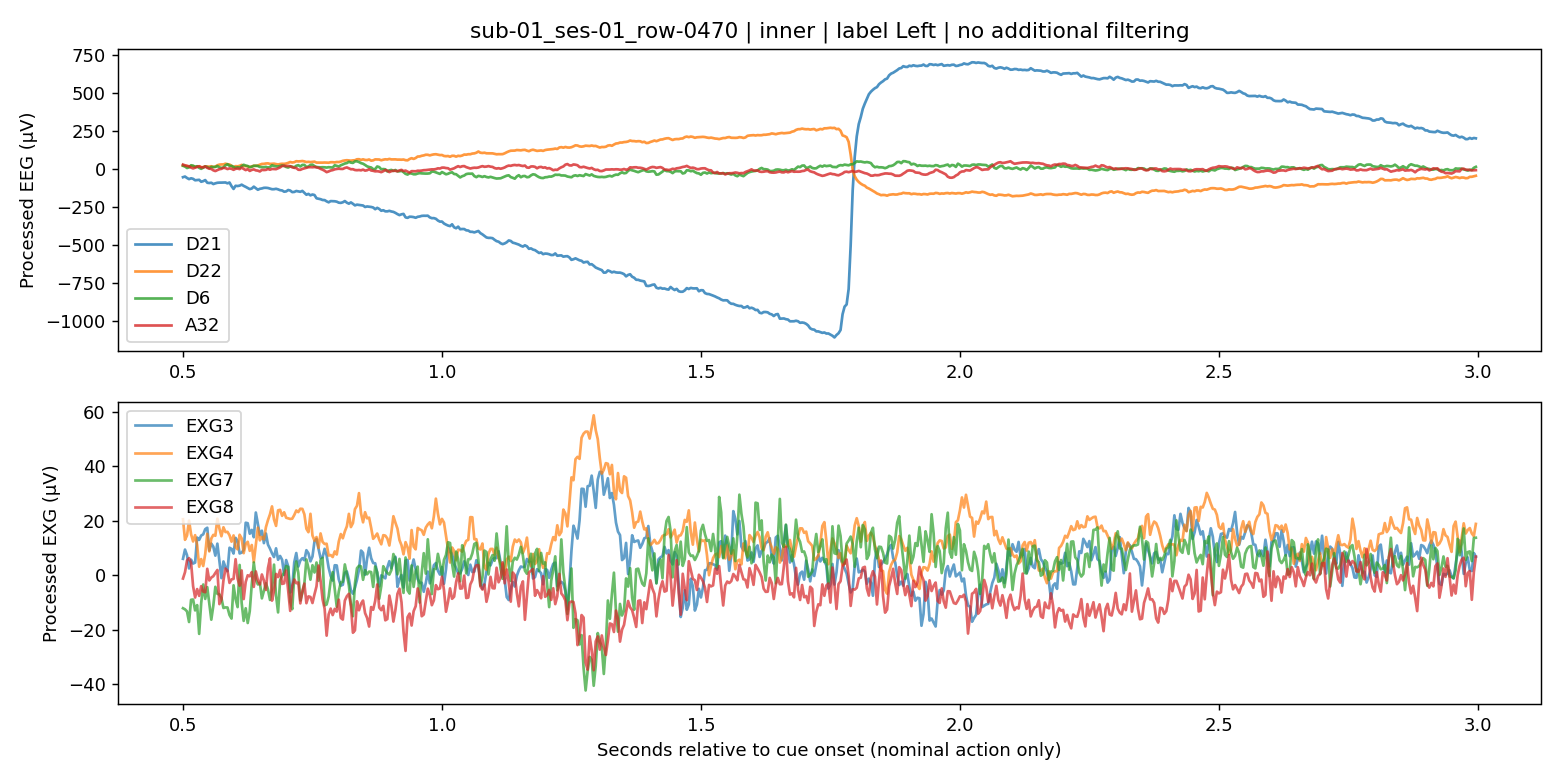

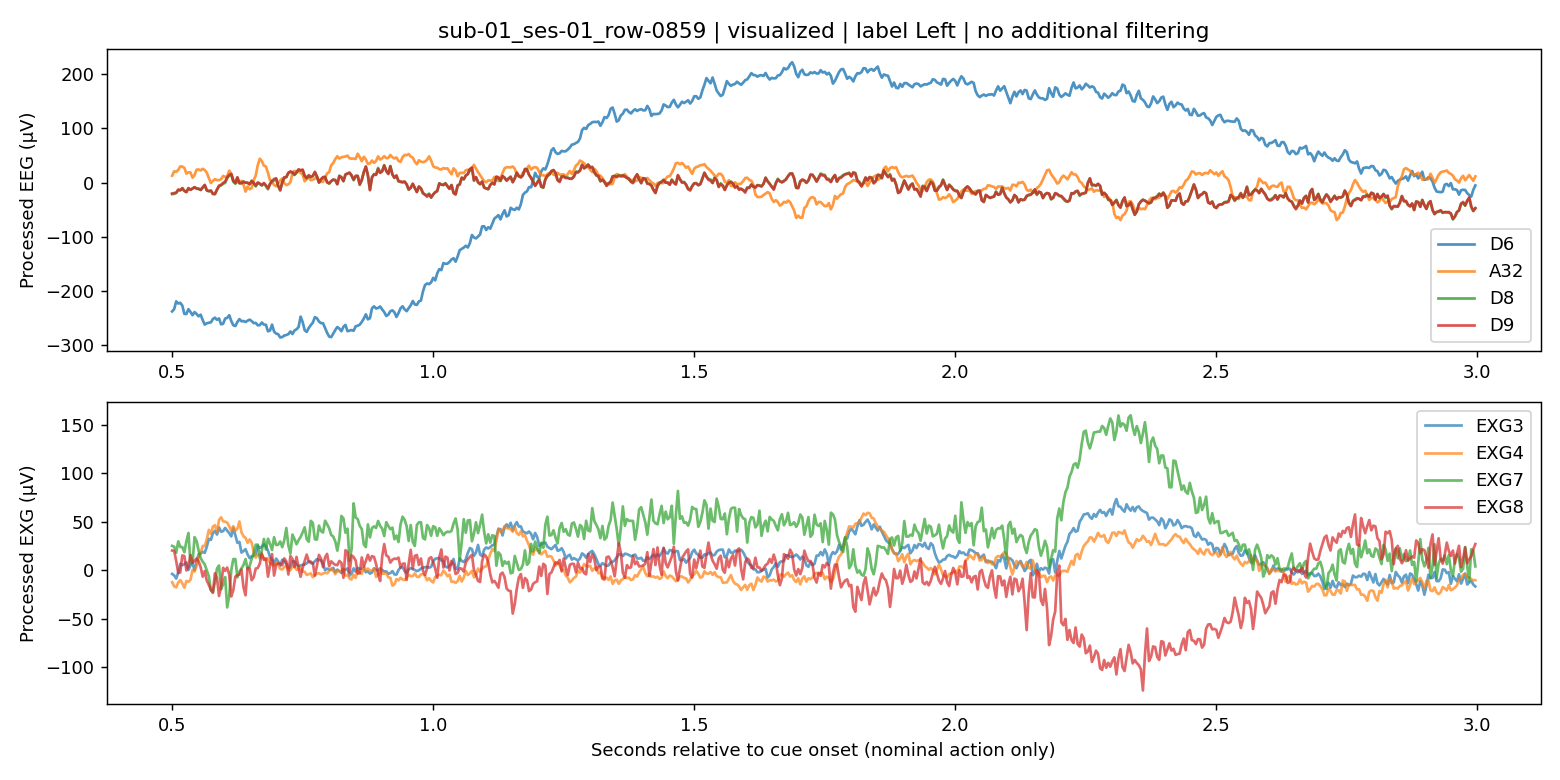

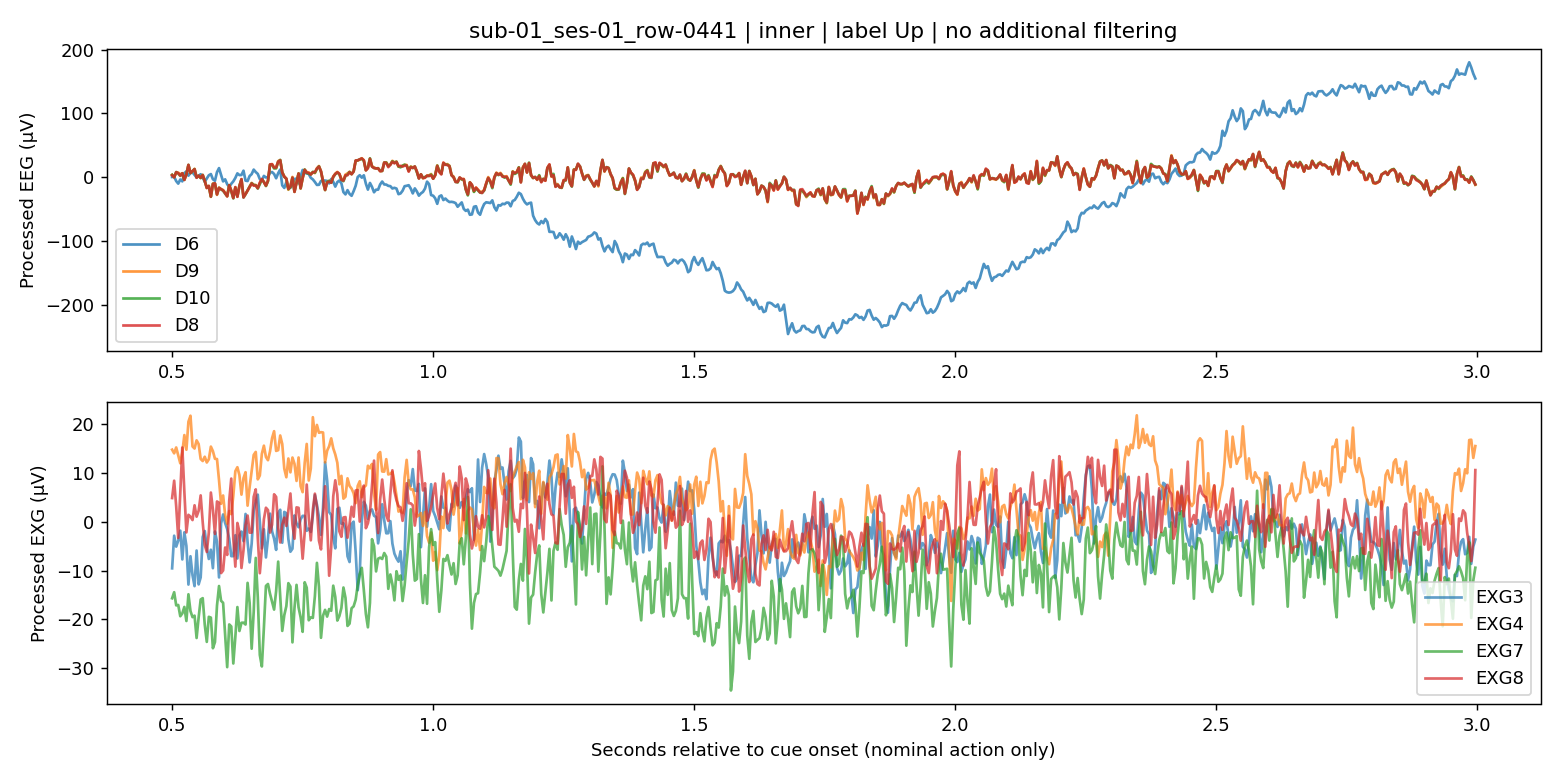

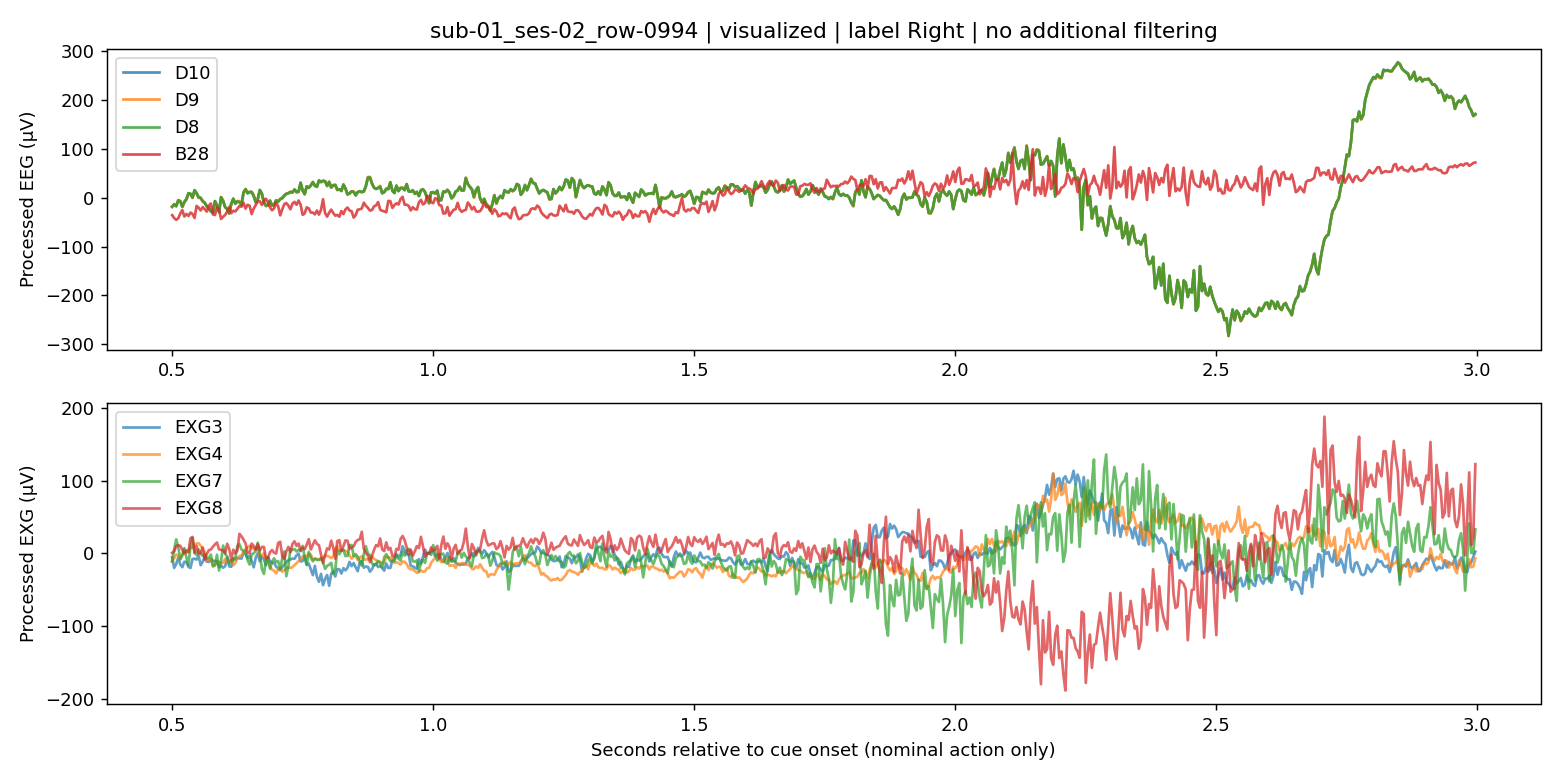

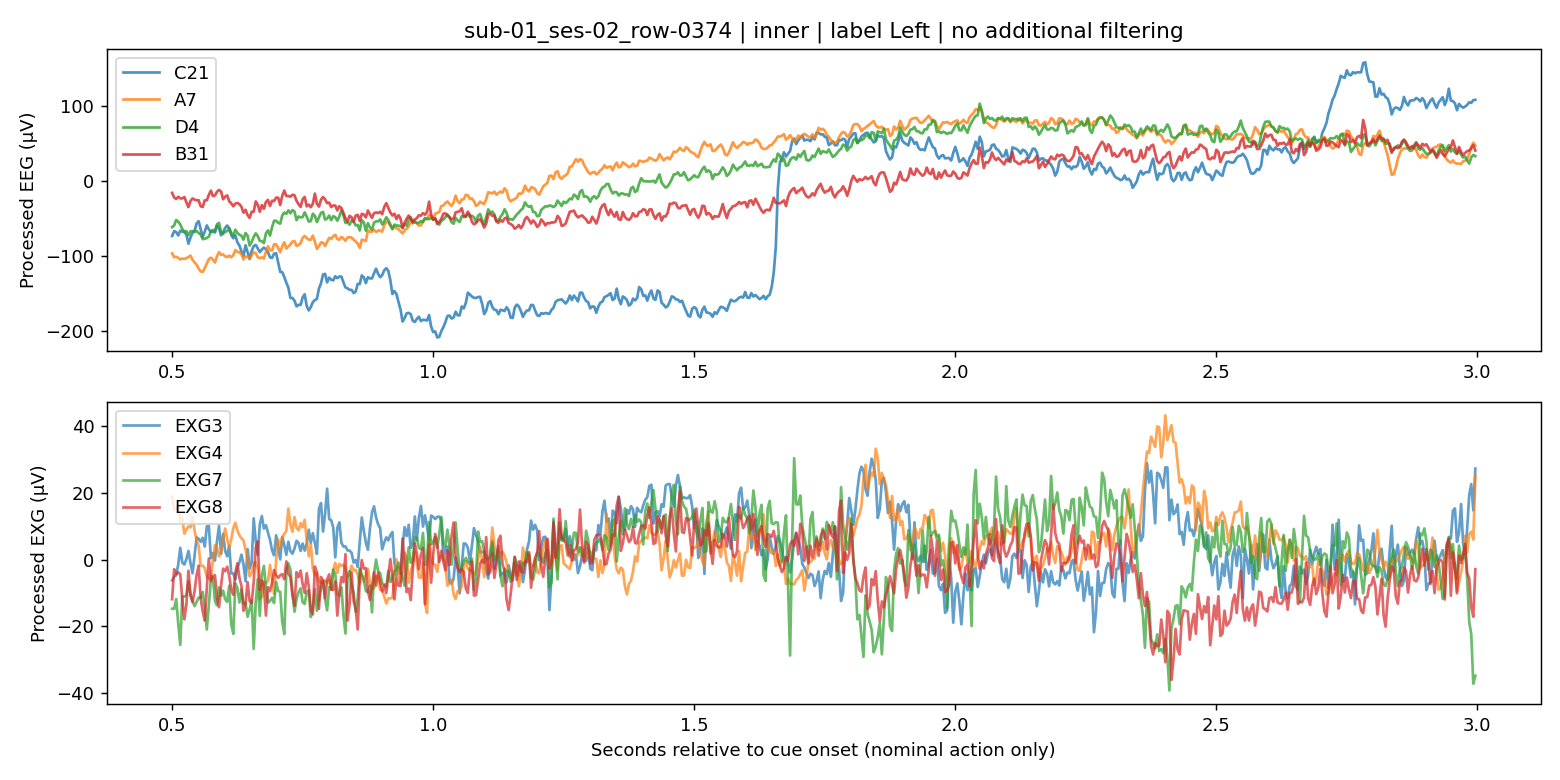

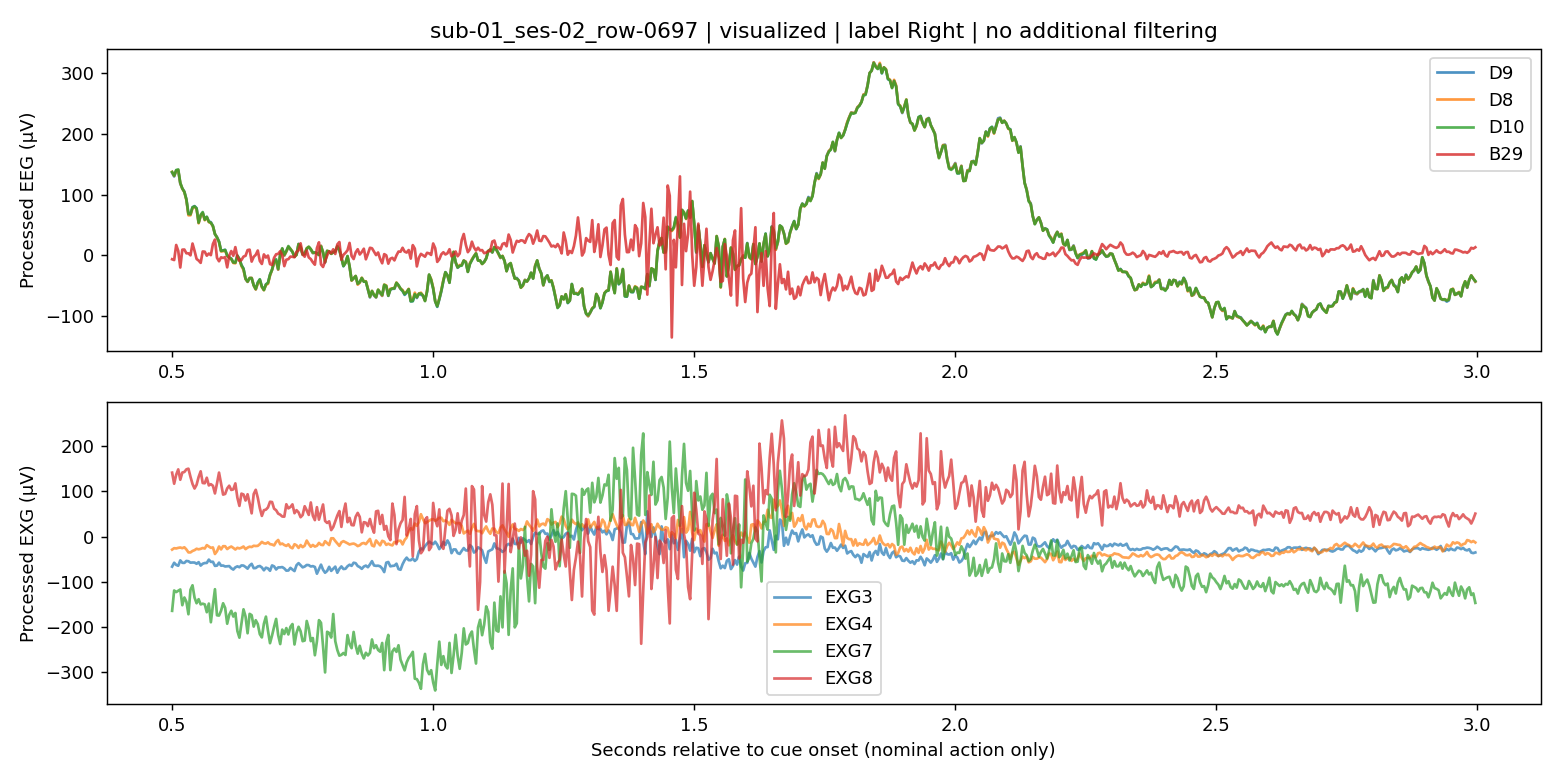

In [19]:
if DATA_AUDIT is not None:
    from IPython.display import Image, display
    for figure in sorted(DATA_AUDIT["directory"].glob("*_outlier-*.png"))[:6]:
        display(Image(filename=str(figure)))

## 2. Optional raw-versus-processed inspection

Set `RAW_BDF_PATH` and its subject/session in Easy settings. This does not download the
large raw dataset or repeat ICA. It matches the raw directional cue sample to a retained
processed epoch, saves measured action/relax timing and shows raw/processed A1 plus EXG.
Different sampling rates, references and bandwidths are recorded; raw and processed SD
are not directly interchangeable. The training crop remains the declared nominal crop.
Source recordings can require the authors' event corrections; an unmatched raw cue fails
instead of fabricating alignment. This optional inspection does not rederive condition tags.


In [20]:
RAW_TIMINGS = None
if RAW_BDF_PATH is not None:
    RAW_TIMINGS = inspect_raw_recording(RAW_BDF_PATH, cfg, subject=RAW_SUBJECT,
                                       session=RAW_SESSION, trial_ordinal=RAW_TRIAL_ORDINAL)
    display(RAW_TIMINGS.head(12))
    print(RAW_TIMINGS[["action_offset_seconds", "relax_offset_seconds",
                       "measured_action_duration_seconds"]].describe())
    from IPython.display import Image, display
    for figure in sorted((dataset_audit_directory(cfg)/"raw").glob("*.png")):
        display(Image(filename=str(figure)))

## EEG waveform and feature EDA — definitions

These are ordinary Matplotlib notebook figures, also saved as PNGs. No classifier is trained.
EDA has its own code hash and outputs; the three-pipeline implementation and checkpoint
identity are unchanged. "Published processed" means the supplied FIF, **not raw BDF EEG**.
The optional raw-inspection cell above is the actual raw-versus-processed comparison.


In [21]:
"""Notebook-embedded descriptive EDA; does not change the training implementation."""
EDA_VERSION = "eeg-wave-feature-eda-1.0"
EDA_SOURCE_SHA256 = "development"  # builder inserts a separate EDA hash


def prepare_eeg_eda(cfg, subject=None, session=None, condition_ids=(1, 0, 2),
                    max_trials_per_condition=24, n_channels=None,
                    plot_channels=("A1", "B1", "C1", "D1"), partition="inner_train", seed=42):
    """Bounded, deterministic sample. Default excludes first inner validation/outer test.

    Construct the SAME subject-level plans as training using metadata from all sessions;
    only then apply display-session and sample limits. No fits, rejection or label changes.
    """
    import mne
    cfg.validate()
    if partition not in ("inner_train", "all"):
        raise ValueError("EDA partition must be inner_train or all")
    if partition == "all":
        warnings.warn("EDA includes holdout trials. Do not use class-visible plots to tune the pipeline; "
                      "the supervised reduction preview is disabled for this partition.", UserWarning)
    if not condition_ids or len(set(condition_ids)) != len(condition_ids) or not set(condition_ids) <= set(CONDITION_NAMES):
        raise ValueError("Choose unique conditions from 1=inner, 0=overt, 2=visualized")
    if not isinstance(max_trials_per_condition, int) or max_trials_per_condition < 4:
        raise ValueError("Use at least four display trials per condition")
    available = discover_recordings(cfg.data_root)
    subject = int((cfg.subject_ids or sorted({r[0] for r in available}))[0] if subject is None else subject)
    if cfg.subject_ids is not None and subject not in cfg.subject_ids:
        raise ValueError("EDA subject must be among configured SUBJECT_IDS")
    n_channels = cfg.channel_counts[0] if n_channels is None else n_channels
    if n_channels not in (16, 32, 64, 128):
        raise ValueError("Use 16, 32, 64 or 128 feature electrodes")
    names = mne.channels.make_standard_montage("biosemi128").ch_names
    plot_channels = tuple(plot_channels)
    if not plot_channels or len(set(plot_channels)) != len(plot_channels) or not set(plot_channels) <= set(names):
        raise ValueError("Choose unique BioSemi128 display electrodes")
    records, tables, source_metadata = {}, [], []
    for sid, ses, path, events in available:
        if sid != subject:
            continue
        epochs = mne.read_epochs(path, preload=False, verbose=False)
        action_time_mask(epochs, cfg)
        labels, conditions = read_event_table(events, epochs)
        if set(names) - set(epochs.ch_names):
            raise ValueError("Missing BioSemi128 electrodes")
        records[ses] = (epochs, path)
        source_metadata.append(dict(subject=sid, session=ses, path=str(path.resolve()),
                                    highpass=float(epochs.info["highpass"]), lowpass=float(epochs.info["lowpass"]),
                                    epoch_origin=cfg.epoch_time_origin, epoch_extent=[epochs.tmin, epochs.tmax]))
        for index in range(len(epochs)):
            tables.append(dict(subject=sid, session=ses, retained_row=index,
                               trial_id=f"sub-{sid:02d}_ses-{ses:02d}_row-{int(epochs.selection[index]):04d}",
                               y_true=int(labels[index]), condition=int(conditions[index]),
                               condition_name=CONDITION_NAMES[int(conditions[index])]))
    if not records:
        raise ValueError(f"No recordings for subject {subject}")
    if session is not None and session not in records:
        raise ValueError("Requested EDA session is absent")
    full_meta = pd.DataFrame(tables)
    rows, split_evidence = [], {}
    rng = np.random.default_rng(seed)
    for condition in condition_ids:
        meta = full_meta[full_meta.condition == condition].reset_index(drop=True)
        if meta.empty:
            raise ValueError(f"No {CONDITION_NAMES[condition]} trials")
        if partition == "inner_train":
            plan = make_split_plan(meta, cfg, cfg.cv_seeds[0])["folds"][0]
            inner = plan["inner"][0]
            indices = np.asarray(inner["train"])
            split_evidence[CONDITION_NAMES[condition]] = dict(
                cv_seed=int(cfg.cv_seeds[0]), outer_fold=plan["fold"], inner_fold=1,
                allowed_trial_ids=meta.trial_id.iloc[indices].tolist(),
                excluded_inner_validation_ids=meta.trial_id.iloc[inner["validation"]].tolist(),
                excluded_outer_test_ids=meta.trial_id.iloc[plan["test"]].tolist())
        else:
            indices = np.arange(len(meta))
        pool = meta.iloc[indices]
        if session is not None:
            pool = pool[pool.session == session]
        if pool.empty:
            raise ValueError("No eligible EDA trials for this session/partition")
        # Round-robin across classes, without duplicating short classes or replacing trials.
        queues = {c: list(rng.permutation(pool.index[pool.y_true == c])) for c in CLASSES}
        chosen = []
        while len(chosen) < max_trials_per_condition and any(queues.values()):
            for c in CLASSES:
                if queues[c] and len(chosen) < max_trials_per_condition:
                    chosen.append(queues[c].pop())
        rows.append(meta.loc[sorted(chosen)])
    meta = pd.concat(rows, ignore_index=True)
    if meta.trial_id.duplicated().any():
        raise AssertionError("Duplicate EDA trials")
    action = np.empty((len(meta), 128, round(2.5*cfg.expected_sfreq)), np.float32)
    trace_indices = [names.index(name) for name in plot_channels]
    extent = next(iter(records.values()))[0].times
    complete_traces = np.empty((len(meta), len(plot_channels), len(extent)), np.float32)
    for ses, (epochs, _) in records.items():
        selected = np.flatnonzero(meta.session.to_numpy() == ses)
        if not len(selected):
            continue
        if not np.allclose(epochs.times, extent):
            raise ValueError("EDA sessions have incompatible time axes")
        mask, convention = action_time_mask(epochs, cfg)
        for start in range(0, len(selected), 8):
            output_indices = selected[start:start+8]
            retained = meta.retained_row.iloc[output_indices].to_numpy(int)
            block = epochs[retained].get_data(picks=names, copy=True, verbose=False)*1e6
            if not np.isfinite(block).all():
                raise ValueError("Nonfinite EDA waveforms; inspect source QC")
            action[output_indices] = block[..., mask]
            complete_traces[output_indices] = block[:, trace_indices]
    feature_indices = channel_subsets(names)[n_channels]
    settings = dict(version=EDA_VERSION, eda_source_sha256=EDA_SOURCE_SHA256, training_code=code_identity(),
                    subject=subject, session=session, conditions=list(condition_ids), partition=partition,
                    n_channels=n_channels, feature_channels=[names[i] for i in feature_indices],
                    plot_channels=plot_channels, sampling_seed=seed, cap_per_condition=max_trials_per_condition,
                    time_convention=convention, sources=source_metadata,
                    source_fingerprints=source_fingerprints(cfg), selected_trial_ids=meta.trial_id.tolist(),
                    split_evidence=split_evidence, trial_rejection="none",
                    purpose="descriptive_only_no_classifier_or_pipeline_changes")
    directory = Path(cfg.output_root)/"eda"/digest(settings)
    save_json(settings, directory/"eda_manifest.json")
    save_csv(meta, directory/"sampled_trials.csv")
    counts = meta.groupby(["condition_name", "session", "y_true"], as_index=False).size()
    save_csv(counts, directory/"sample_counts.csv")
    print(f"EDA subject {subject:02d}: {len(meta)} sampled original trials; partition={partition}; "
          f"features={n_channels} electrodes; no classifier training. Saved to {directory}")
    return dict(meta=meta, action=action, full_traces=complete_traces,
                full_times_cue=extent-(.5 if cfg.epoch_time_origin == "trial_start" else 0.),
                plot_channels=plot_channels, channel_names=names, feature_indices=feature_indices,
                sfreq=cfg.expected_sfreq, partition=partition, directory=directory,
                counts=counts, manifest=settings)


def _eda_plot_finish(eda, fig, filename, show):
    import matplotlib.pyplot as plt
    fig.tight_layout()
    fig.savefig(eda["directory"]/filename, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    return eda["directory"]/filename


def _eda_trial(eda, trial_index, channel):
    if not isinstance(trial_index, (int, np.integer)) or not 0 <= trial_index < len(eda["meta"]):
        raise ValueError("EDA_TRIAL_INDEX is out of range; inspect EDA['meta']")
    if channel not in eda["channel_names"]:
        raise ValueError("Unknown EEG electrode")
    return eda["meta"].iloc[trial_index], eda["channel_names"].index(channel)


def plot_eda_waveforms(eda, trial_index=0, show=True):
    """Published complete epoch, real microvolt axes, no new preprocessing."""
    import matplotlib.pyplot as plt
    row, _ = _eda_trial(eda, trial_index, eda["plot_channels"][0])
    fig, axes = plt.subplots(len(eda["plot_channels"]), 1, figsize=(12, 2*len(eda["plot_channels"])),
                             sharex=True, squeeze=False)
    for i, name in enumerate(eda["plot_channels"]):
        ax = axes[i, 0]
        ax.plot(eda["full_times_cue"], eda["full_traces"][trial_index, i], lw=.8)
        ax.axvline(0, color="gray", linestyle="--", label="Directional cue")
        ax.axvspan(.5, 3., color="green", alpha=.1, label="Nominal action used by models")
        ax.set_ylabel(f"{name}\nµV")
        ax.grid(alpha=.15)
    axes[0, 0].set_title(f"Published processed EEG, complete epoch | {row.trial_id} | "
                         f"{row.condition_name} | {CLASS_NAMES[int(row.y_true)]}")
    axes[0, 0].legend(loc="upper right", fontsize=8)
    axes[-1, 0].set_xlabel("Seconds relative to directional cue (not trial start)")
    return _eda_plot_finish(eda, fig, f"waveforms_trial-{trial_index}.png", show)


def plot_eda_preprocessing(eda, trial_index=0, channel="A1", show=True):
    """Use the ACTUAL SubjectViews transforms; normalized panel is a subset-only demo."""
    import matplotlib.pyplot as plt
    row, index = _eda_trial(eda, trial_index, channel)
    X, fs = eda["action"], eda["sfreq"]
    views = SubjectViews(X, fs)
    filtered = views.get("eight_window", "full")[:, 0, 0]
    eegnet = views.get("eegnet", "full")
    condition_rows = np.flatnonzero(eda["meta"].condition.to_numpy() == row.condition)
    # This normalizer is illustrative, never used by the actual training pipeline.
    if eda["partition"] == "inner_train":
        normalizer = fit_normalizer(eegnet[condition_rows])
        scaled = normalize(eegnet[trial_index:trial_index+1], normalizer)[0, 0, index]
    else:
        scaled = None
    labram = views.get("labram", "full")[trial_index, 0, index]
    stages = [
        (X[trial_index, index], fs, "Published processed action EEG; no added filter", "µV"),
        (filtered[trial_index, index], fs, "Added 2–45 Hz zero-phase filter; classical broadband input", "µV"),
        (eegnet[trial_index, 0, index], 128., "Scratch EEGNet input: 2–45 Hz, resampled to 128 Hz", "µV"),
    ]
    if scaled is not None:
        stages.append((scaled, 128., "Training-only normalization demo, this condition's sampled inner-train trials", "Standard deviations"))
    stages.append((labram, 200., "LaBraM input: resampled to 200 Hz, µV/100, right-zero-padded", "µV / 100"))
    fig, axes = plt.subplots(len(stages), 1, figsize=(12, 2*len(stages)), sharex=True, squeeze=False)
    for i, (values, rate, title, unit) in enumerate(stages):
        ax = axes[i, 0]
        ax.plot(.5+np.arange(len(values))/rate, values, lw=.8)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(unit); ax.grid(alpha=.15)
    axes[-1, 0].axvspan(3., .5+len(labram)/200., color="gray", alpha=.15, label="Padding, not EEG")
    axes[-1, 0].legend(fontsize=8)
    axes[-1, 0].set_xlabel("Seconds relative to directional cue")
    fig.suptitle(f"Preprocessing stages | {row.trial_id} | {row.condition_name} | {channel}", y=1.01)
    return _eda_plot_finish(eda, fig, f"preprocessing_trial-{trial_index}_{channel}.png", show)


def plot_eda_spectra(eda, channel="A1", show=True):
    """Trial-average Welch PSD; conditions separate, no trial-wave averaging/cancellation."""
    import matplotlib.pyplot as plt
    _, index = _eda_trial(eda, 0, channel)
    X, fs = eda["action"], eda["sfreq"]
    views = SubjectViews(X, fs)
    series = [(X[:, index], fs, "Published processed"),
              (views.get("eight_window", "full")[:, 0, 0, index], fs, "Added 2–45 Hz"),
              (views.get("eegnet", "full")[:, 0, index], 128., "128 Hz EEGNet input")]
    conditions = list(eda["meta"].condition.unique())
    fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3*len(conditions)), squeeze=False)
    rows = []
    for panel, condition in enumerate(conditions):
        trials = np.flatnonzero(eda["meta"].condition.to_numpy() == condition)
        ax = axes[panel, 0]
        for values, rate, name in series:
            frequencies, power = signal.welch(values[trials], fs=rate, nperseg=min(round(2*rate), values.shape[-1]), axis=-1)
            mean_power = power.mean(0)
            mask = (frequencies >= .5) & (frequencies <= 100)
            ax.semilogy(frequencies[mask], np.maximum(mean_power[mask], 1e-20), label=name)
            for frequency, value in zip(frequencies[mask], mean_power[mask]):
                rows.append(dict(condition_name=CONDITION_NAMES[condition], channel=channel, stage=name,
                                 frequency_hz=frequency, mean_trial_psd_uv2_per_hz=value, n_trials=len(trials)))
        ax.axvspan(2, 45, color="green", alpha=.07)
        ax.set(title=f"{CONDITION_NAMES[condition]} | {channel} | {len(trials)} sampled {eda['partition']} trials",
               xlabel="Frequency (Hz)", ylabel="Mean trial PSD (µV²/Hz)", xlim=(.5, 100))
        ax.legend(fontsize=8); ax.grid(alpha=.15)
    save_csv(pd.DataFrame(rows), eda["directory"]/f"psd_{channel}.csv")
    return _eda_plot_finish(eda, fig, f"spectra_{channel}.png", show)


def plot_eda_time_frequency(eda, trial_index=0, channel="A1", show=True):
    """Single-trial spectrogram of the same 128-Hz filtered action, not a new model input."""
    import matplotlib.pyplot as plt
    row, index = _eda_trial(eda, trial_index, channel)
    values = SubjectViews(eda["action"], eda["sfreq"]).get("eegnet", "full")[trial_index, 0, index]
    frequencies, times, power = signal.spectrogram(values, fs=128., nperseg=64, noverlap=48,
                                                  nfft=128, scaling="density", mode="psd")
    mask = (frequencies >= 2) & (frequencies <= 45)
    decibels = 10*np.log10(np.maximum(power[mask], 1e-20))
    fig, ax = plt.subplots(figsize=(10, 4))
    image = ax.pcolormesh(.5+times, frequencies[mask], decibels, shading="auto", cmap="viridis")
    fig.colorbar(image, ax=ax, label="PSD (dB relative to 1 µV²/Hz)")
    ax.set(xlabel="Seconds relative to directional cue", ylabel="Frequency (Hz)",
           title=f"Single-trial spectrogram | {row.condition_name} | {channel} | {row.trial_id}")
    np.savez(eda["directory"]/f"spectrogram_trial-{trial_index}_{channel}.npz",
             time_cue_seconds=.5+times, frequency_hz=frequencies[mask], psd_uv2_per_hz=power[mask])
    return _eda_plot_finish(eda, fig, f"spectrogram_trial-{trial_index}_{channel}.png", show)


def extract_eda_features(eda, representation="bandpower_eight_window"):
    """Actual extractor, without any supervised selection or classifier fitting."""
    if representation not in ("eight_window", "bandpower_eight_window"):
        raise ValueError("Choose eight_window or bandpower_eight_window")
    names = [eda["channel_names"][i] for i in eda["feature_indices"]]
    X = eda["action"][:, eda["feature_indices"]]
    views = SubjectViews(X, eda["sfreq"])
    spec = dict(representation=representation, view="full", n_windows=8, wavelet="db2",
                wavelet_level=3, ar_order=4, feature_sfreq=128.)
    data = classical_data(views, spec)
    extractor = classical_extractor(spec)
    features = extractor.fit_transform(data)  # fit stores shape only, never uses labels
    schema = extractor.describe(names)
    schema["start_time_cue_s"] = .5+schema.start_offset_s
    schema["stop_time_cue_s"] = .5+schema.stop_offset_s
    schema["start_time_trial_s"] = 1.+schema.start_offset_s
    schema["stop_time_trial_s"] = 1.+schema.stop_offset_s
    broadband = resample(data[:, 0], eda["sfreq"], extractor.feature_sfreq)
    # Actual six fixed filter-band inputs, even for the pure wavelet feature preview.
    bands = views.get("classical", "full")[:, 0]
    bandpower = np.mean(bands.astype(np.float64)**2, axis=-1)
    directory = eda["directory"]/representation; directory.mkdir(parents=True, exist_ok=True)
    save_csv(schema, directory/"feature_schema.csv")
    save_csv(eda["meta"], directory/"feature_rows.csv")
    np.savez_compressed(directory/"features.npz", features=features,
                        trial_ids=eda["meta"].trial_id.to_numpy(dtype=str), bandpower_uv2=bandpower)
    save_json(extractor.metadata() | dict(purpose="EDA_only_not_selected_model", time_origin="cue_and_trial_start"),
              directory/"feature_metadata.json")
    print(f"EDA feature table: {features.shape[0]} original-trial rows × {features.shape[1]} columns; "
          f"{len(names)} feature electrodes; {representation}. No classifier was trained.")
    return dict(features=features, schema=schema, broadband=broadband, extractor=extractor,
                channel_names=names, directory=directory, bandpower_uv2=bandpower)


def plot_eda_eight_windows(eda, extracted, trial_index=0, channel=None, show=True):
    """Show wave boundaries and scalar descriptors, with separate units/colour scales."""
    import matplotlib.pyplot as plt
    channel = extracted["channel_names"][0] if channel is None else channel
    row, _ = _eda_trial(eda, trial_index, channel)
    if channel not in extracted["channel_names"]:
        raise ValueError("Choose an electrode from EDA_FEATURES['channel_names'] for feature plots")
    index = extracted["channel_names"].index(channel)
    extractor, schema, values = extracted["extractor"], extracted["schema"], extracted["features"][trial_index]
    signal_values = extracted["broadband"][trial_index, index]
    fig, axes = plt.subplots(4, 1, figsize=(12, 11))
    axes[0].plot(.5+np.arange(len(signal_values))/extractor.feature_sfreq, signal_values, lw=.8)
    edges = .5+np.r_[0, np.cumsum(extractor.window_lengths_)]/extractor.feature_sfreq
    for window, (start, stop) in enumerate(zip(edges[:-1], edges[1:]), 1):
        axes[0].axvspan(start, stop, color="gray" if window % 2 else "green", alpha=.08)
        axes[0].axvline(start, color="gray", lw=.5)
        axes[0].text((start+stop)/2, .95, str(window), transform=axes[0].get_xaxis_transform(), ha="center", va="top")
    axes[0].set(xlabel="Seconds relative to cue", ylabel="µV", title="Actual filtered/resampled wave, with eight contiguous windows")
    families = [("ar", [f"lag{i}" for i in range(1, extractor.ar_order+1)], "AR coefficients (dimensionless)", "RdBu_r"),
                ("wavelet_entropy", extractor.component_labels_, "Normalized coefficient-energy entropy [0,1]", "viridis"),
                ("wavelet_log_variance", extractor.component_labels_, "Natural log coefficient variance (µV² reference)", "viridis")]
    for ax, (family, components, title, cmap) in zip(axes[1:], families):
        selected = schema[(schema.channel == channel) & (schema.family == family)]
        table = selected.assign(value=values[selected.input_column.to_numpy()]).pivot(index="component", columns="window", values="value")
        matrix = table.reindex(index=components, columns=range(1, 9)).to_numpy()
        limits = dict(vmin=0, vmax=1) if family == "wavelet_entropy" else {}
        if family == "ar":
            bound = max(float(np.max(np.abs(matrix))), 1e-6)
            limits = dict(vmin=-bound, vmax=bound)
        image = ax.imshow(matrix, aspect="auto", cmap=cmap, **limits)
        ax.set(xticks=range(8), xticklabels=range(1, 9), yticks=range(len(components)), yticklabels=components,
               xlabel="Window number", title=title)
        fig.colorbar(image, ax=ax)
    fig.suptitle(f"Wave → tabular features | {row.condition_name} | {row.trial_id} | {channel}", y=1.01)
    return _eda_plot_finish(eda, fig, f"eight_windows_trial-{trial_index}_{channel}.png", show)


def plot_eda_wavelet_components(eda, extracted, trial_index=0, channel=None, window=1, show=True):
    """DWT coefficients in one window, NOT reconstructed independent EEG waves."""
    import matplotlib.pyplot as plt
    channel = extracted["channel_names"][0] if channel is None else channel
    _eda_trial(eda, trial_index, channel)
    if channel not in extracted["channel_names"] or window not in range(1, 9):
        raise ValueError("Choose an extracted electrode and window 1..8")
    index = extracted["channel_names"].index(channel)
    extractor = extracted["extractor"]
    windows = np.array_split(extracted["broadband"][trial_index, index], 8)
    values = windows[window-1]
    coefficients = pywt.wavedec(values.astype(np.float64), extractor.wavelet, mode="symmetric", level=extractor.wavelet_level)
    fig, axes = plt.subplots(1+len(coefficients), 1, figsize=(11, 2*(1+len(coefficients))))
    start = .5+sum(extractor.window_lengths_[:window-1])/extractor.feature_sfreq
    axes[0].plot(start+np.arange(len(values))/extractor.feature_sfreq, values)
    axes[0].set(title=f"Window {window}, {channel}: {len(values)} samples at 128 Hz", ylabel="µV", xlabel="Seconds relative to cue")
    for ax, label, component in zip(axes[1:], extractor.component_labels_, coefficients):
        entropy, variance = wavelet_statistics(component[None])
        ax.plot(np.arange(len(component)), component, marker=".")
        ax.set(title=f"{label}: {len(component)} coefficients | entropy={entropy[0]:.3f} | ln variance={variance[0]:.3f}",
               ylabel="Coefficient (µV)", xlabel="Decimated coefficient index (not original time samples)")
    fig.suptitle("db2 DWT, symmetric boundaries retained — diagnostic coefficients, not reconstructed EEG", y=1.01)
    return _eda_plot_finish(eda, fig, f"wavelet_trial-{trial_index}_{channel}_window-{window}.png", show)


def plot_eda_bandpower(eda, extracted, show=True):
    """Separate condition/class heatmaps of actual filter-bank power, purely descriptive."""
    import matplotlib.pyplot as plt
    conditions = list(eda["meta"].condition.unique())
    power = extracted["bandpower_uv2"].mean(axis=-1)  # per-trial mean over feature electrodes
    log_power = np.log(np.maximum(power, 1e-12))
    panels, counts, rows = [], [], []
    for condition in conditions:
        matrix, class_counts = [], []
        for c in CLASSES:
            indices = np.flatnonzero((eda["meta"].condition.to_numpy() == condition) & (eda["meta"].y_true.to_numpy() == c))
            class_counts.append(len(indices))
            matrix.append(np.median(log_power[indices], axis=0) if len(indices) else np.full(len(BANDS), np.nan))
            for trial in indices:
                for band, (low, high) in enumerate(BANDS):
                    rows.append(dict(trial_id=eda["meta"].trial_id.iloc[trial], condition_name=CONDITION_NAMES[condition],
                                     y_true=int(c), band_hz=f"{low:g}-{high:g}", mean_electrode_power_uv2=power[trial, band],
                                     log_mean_electrode_power=log_power[trial, band]))
        panels.append(np.asarray(matrix)); counts.append(class_counts)
    finite = np.concatenate(panels)[np.isfinite(np.concatenate(panels))]
    fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3*len(conditions)), squeeze=False)
    for i, condition in enumerate(conditions):
        ax = axes[i, 0]
        image = ax.imshow(panels[i], aspect="auto", vmin=finite.min(), vmax=finite.max(), cmap="viridis")
        ax.set(xticks=range(len(BANDS)), xticklabels=[f"{a:g}–{b:g}" for a, b in BANDS],
               yticks=range(4), yticklabels=[f"{name} (n={n})" for name, n in zip(CLASS_NAMES, counts[i])],
               xlabel="Filter band (Hz)", title=f"{CONDITION_NAMES[condition]} — median trial log power; "
               f"{len(extracted['channel_names'])} electrodes averaged")
        fig.colorbar(image, ax=ax, label="Natural log mean power (µV² reference)")
    save_csv(pd.DataFrame(rows), eda["directory"]/"bandpower_by_trial.csv")
    return _eda_plot_finish(eda, fig, "condition_class_bandpower.png", show)


def preview_eda_feature_reduction(eda, extracted, condition=1, dimension=32, show=True):
    """Training-subset-only ANOVA demo, never a fitted model or global/test selector."""
    import matplotlib.pyplot as plt
    if eda["partition"] != "inner_train":
        raise ValueError("Supervised reduction preview only supports inner_train EDA")
    indices = np.flatnonzero(eda["meta"].condition.to_numpy() == condition)
    y = eda["meta"].y_true.to_numpy()[indices]
    if set(y) != set(CLASSES) or np.bincount(y, minlength=4).min() < 2:
        raise ValueError("Need at least two sampled inner-training trials per class for the ANOVA preview")
    X = extracted["features"][indices]
    reducer = CompactFeatures(dimension=dimension, method="anova").fit(X, y)
    transformed = reducer.transform(X)
    kept = reducer.variance_.get_support(indices=True)
    selected = kept[reducer.reducer_.get_support(indices=True)]
    schema = extracted["schema"].iloc[selected].copy()
    schema["training_ANOVA_F"] = reducer.reducer_.scores_[reducer.reducer_.get_support(indices=True)]
    save_csv(schema, extracted["directory"]/f"{CONDITION_NAMES[condition]}_EDA_selected_schema.csv")
    save_csv(pd.DataFrame(transformed, columns=schema.feature_name).assign(trial_id=eda["meta"].trial_id.iloc[indices].to_numpy(), y_true=y),
             extracted["directory"]/f"{CONDITION_NAMES[condition]}_EDA_selected_features.csv")
    ordered = np.argsort(y, kind="stable")
    limit = min(32, transformed.shape[1])
    fig, ax = plt.subplots(figsize=(12, 5))
    bound = max(float(np.abs(transformed[:, :limit]).max()), 1e-6)
    image = ax.imshow(transformed[ordered, :limit], aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    def label(row):
        abbreviations = {"ar": "AR", "wavelet_entropy": "H", "wavelet_log_variance": "lnV", "bandpower": "BP"}
        return f"W{row.window}:{row.channel}:{abbreviations[row.family]}:{row.component}"
    ax.set(xticks=range(limit), xticklabels=[label(row) for _, row in schema.head(limit).iterrows()],
           yticks=range(len(ordered)), yticklabels=[f"{CLASS_NAMES[int(y[i])]} · {i}" for i in ordered],
           ylabel="Sampled inner-training trials (class labels shown)",
           title=f"ANOVA/standardization demonstration: {X.shape[1]} → {transformed.shape[1]} columns | {CONDITION_NAMES[condition]}")
    ax.tick_params(axis="x", labelrotation=65, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    fig.colorbar(image, ax=ax, label="Training-subset standardized feature value")
    path = _eda_plot_finish(eda, fig, f"feature_reduction_{CONDITION_NAMES[condition]}.png", show)
    return dict(features=transformed, schema=schema, trial_indices=indices, figure=path,
                note="EDA subset only; actual models fit all transformations again within each fold")

EDA_SOURCE_SHA256 = "48f60c908b251bf661072aa600bb13683b6fc1a910e0345af4c2cb65287073c7"


### EDA 1 — choose a bounded, reproducible training sample

The default rebuilds the **same first CV seed / outer fold / inner fold** as the training
runner, for each condition separately. It takes only that inner fold's training trials,
then samples at most 24 trials per condition, distributed across classes. It reads metadata
for all sessions before applying `EDA_SESSION`, so session filtering cannot change the CV
plan. Trial IDs and excluded inner-validation/outer-test IDs are saved for verification.

Explore another configured subject, electrode, session, or displayed trial using Easy settings.
These controls never change `cfg` or select hyperparameters. Condition panels use different
trials and are descriptive; the sample is not a population-level performance estimate.
`EDA_PARTITION="all"` is exploratory-only: it exposes holdout data and disables the ANOVA
preview. Do not use holdout-visible patterns to repeatedly redesign an evaluated pipeline.


In [22]:
EDA = None
EDA_FEATURES = None
EDA_REDUCTION = None
if RUN_EDA:
    if Path(cfg.data_root).exists():
        EDA = prepare_eeg_eda(cfg, subject=EDA_SUBJECT, session=EDA_SESSION,
            condition_ids=EDA_CONDITIONS, partition=EDA_PARTITION,
            max_trials_per_condition=EDA_MAX_TRIALS_PER_CONDITION,
            n_channels=EDA_N_CHANNELS, plot_channels=EDA_DISPLAY_CHANNELS,
            seed=int(cfg.cv_seeds[0]))
        display(EDA["counts"])
        display(EDA["meta"])
    else:
        print("Set DATA_ROOT to explore real EEG. No synthetic data is substituted.")

EDA subject 01: 72 sampled original trials; partition=inner_train; features=128 electrodes; no classifier training. Saved to /kaggle/working/inner_speech_eight_window_audited/eda/3a5bf789422e64d126de55a5


,condition_name,session,y_true,size
0,inner,1,0,4
1,inner,1,1,2
2,inner,1,2,4
3,inner,1,3,3
4,inner,2,0,1
5,inner,2,1,3
6,inner,2,2,2
7,inner,2,3,3
8,inner,3,0,1
9,inner,3,1,1


,subject,session,retained_row,trial_id,y_true,condition,condition_name
0,1,1,43,sub-01_ses-01_row-0225,3,1,inner
1,1,1,47,sub-01_ses-01_row-0247,3,1,inner
2,1,1,60,sub-01_ses-01_row-0320,1,1,inner
3,1,1,61,sub-01_ses-01_row-0325,0,1,inner
4,1,1,62,sub-01_ses-01_row-0330,1,1,inner
...,...,...,...,...,...,...,...
67,1,3,81,sub-01_ses-03_row-0433,2,2,visualized
68,1,3,84,sub-01_ses-03_row-0448,2,2,visualized
69,1,3,91,sub-01_ses-03_row-0483,0,2,visualized
70,1,3,95,sub-01_ses-03_row-0505,0,2,visualized


### EDA 2 — complete published EEG epochs

Each electrode has its own microvolt axis; traces are not flattened together or averaged
across trials. Zero is the directional cue. Green shading is the nominal action interval
used by the models. Change `EDA_TRIAL_INDEX` after inspecting the trial table above.
This shows the complete published epoch, including samples outside the model's action crop.


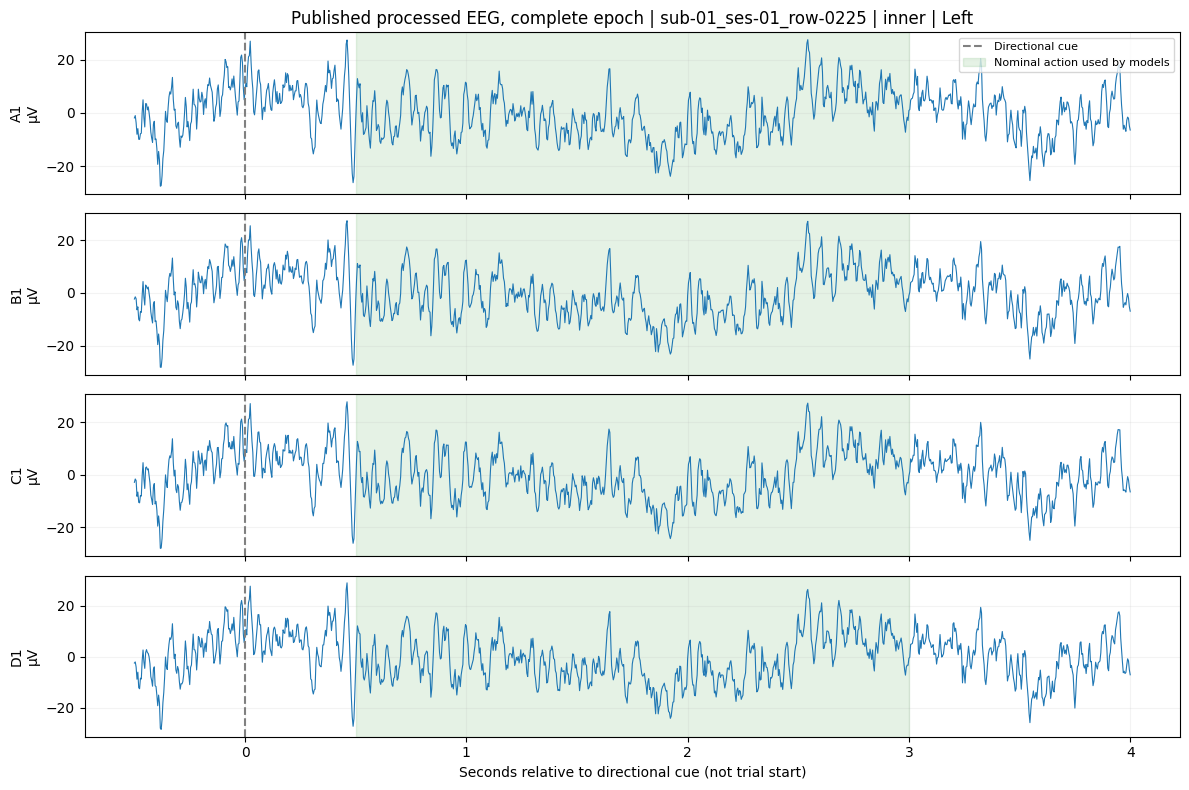

In [23]:
if EDA is not None:
    plot_eda_waveforms(EDA, trial_index=EDA_TRIAL_INDEX)

### EDA 3 — the wave after each actual preprocessing stage

Compare the published action signal with the actual extra 2–45 Hz filtering, 128-Hz EEGNet
input, and 200-Hz LaBraM input. The normalized EEGNet panel fits a demonstration normalizer
only on this condition's sampled inner-training trials. Actual models fit their own
normalizers on their full fold-training data; this EDA normalizer is never passed to them.

Axes retain their correct units. LaBraM divides microvolts by 100 and pads the 2.5-second
action to three seconds; gray shading identifies artificial padding, not measured brain
activity. No extra 2–45 Hz filter is imposed on LaBraM by this visualization.


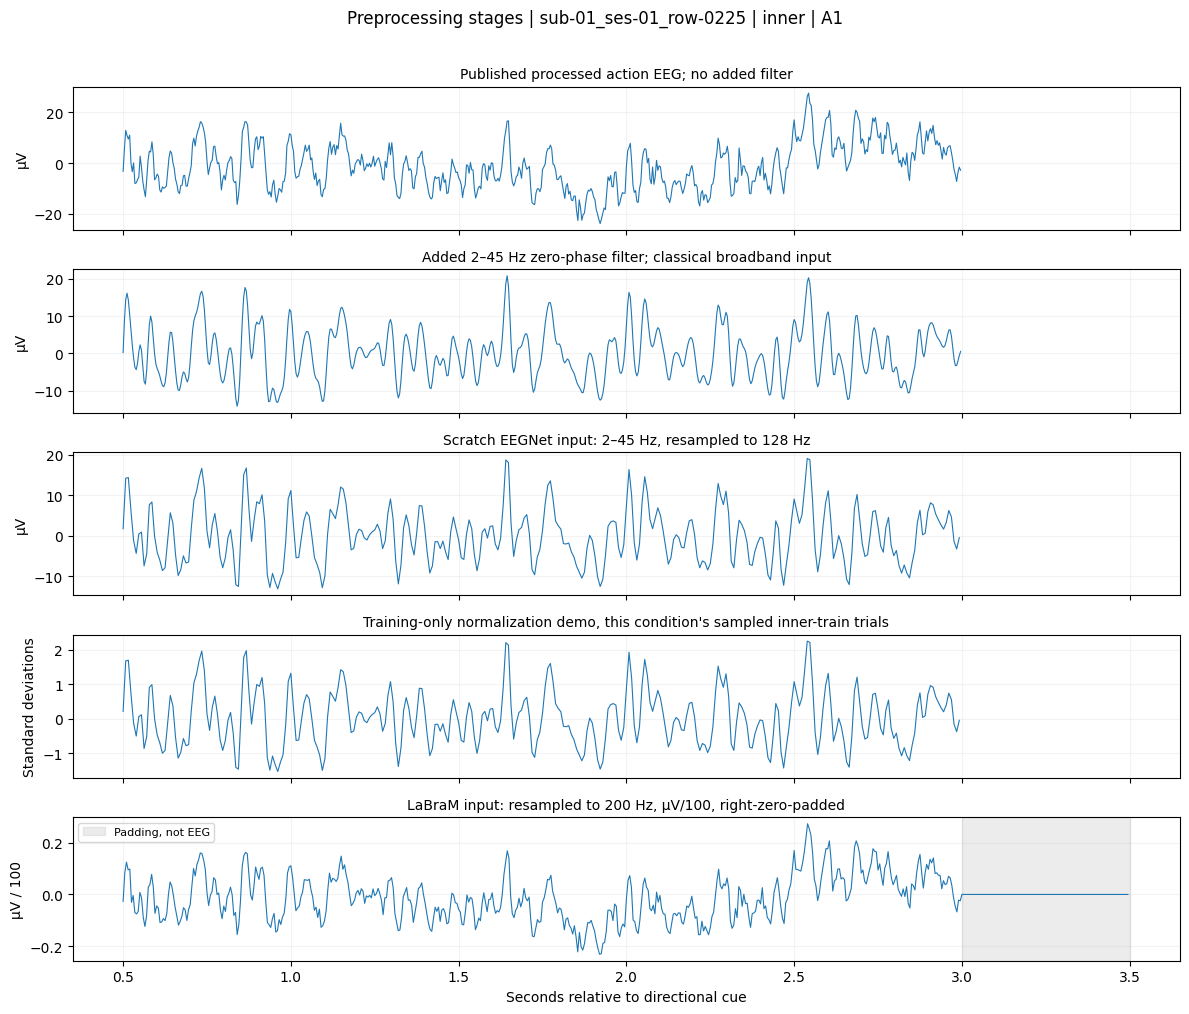

In [24]:
if EDA is not None:
    plot_eda_preprocessing(EDA, trial_index=EDA_TRIAL_INDEX, channel=EDA_CHANNEL)

### EDA 4 — spectra and one-trial time–frequency structure

Welch spectra average **power estimates per trial**, not phase-sensitive EEG waves. Each
condition has a separate panel. Curves show the supplied FIF, added filtering, and EEGNet's
resampled signal; inspect whether the expected frequencies are retained or suppressed.

The spectrogram uses one electrode/trial, 0.5-second analysis windows and 0.125-second steps.
Zero-padding gives 1-Hz display bins but does not improve the true spectral resolution.
It is a visualization, not a new feature representation. Power differences can reflect
artifacts as well as neural activity; do not equate visible differences with decoding accuracy.


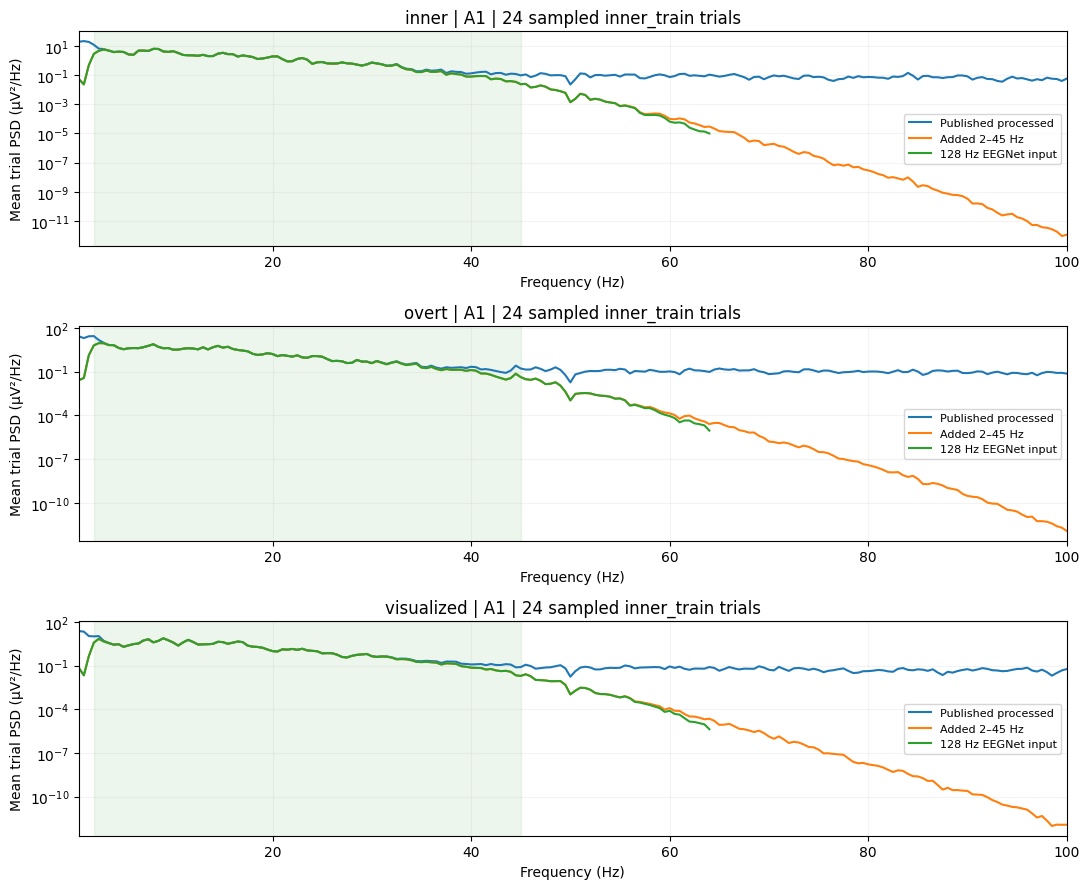

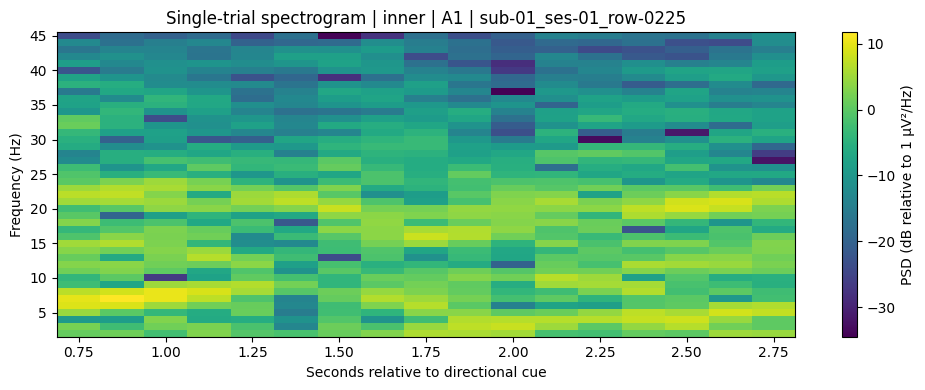

In [25]:
if EDA is not None:
    plot_eda_spectra(EDA, channel=EDA_CHANNEL)
    plot_eda_time_frequency(EDA, trial_index=EDA_TRIAL_INDEX, channel=EDA_CHANNEL)

### EDA 5 — extract and inspect the actual eight-window feature table

This calls the **same extractor used by the classical pipeline**: db2 DWT, AR order 4,
three wavelet levels, eight contiguous windows, and optional six-band bandpower fusion.
`CLASSICAL_FEATURE_SET="baseline"` does not remove this optional eight-window EDA; it
remains a descriptive illustration, not an automatically included training candidate.

The extractor uses no labels or population statistics. Its `fit` records input shape only.
Every original trial is one row. Raw feature columns, row IDs, units/timing schema and an
NPZ feature matrix are saved. A full 128-electrode fused row has 15,360 columns; eight
windows are **not eight independently labeled training examples**.


In [26]:
if EDA is not None and RUN_EDA_FEATURES:
    EDA_FEATURES = extract_eda_features(EDA, representation="bandpower_eight_window")
    display(EDA_FEATURES["schema"].head(16))
    display(pd.DataFrame(EDA_FEATURES["features"][:8, :12],
        columns=EDA_FEATURES["schema"].feature_name.iloc[:12],
        index=EDA["meta"].trial_id.iloc[:8]))
    print("Feature electrodes:", EDA_FEATURES["channel_names"])

EDA feature table: 72 original-trial rows × 15360 columns; 128 feature electrodes; bandpower_eight_window. No classifier was trained.


,input_column,feature_name,family,channel,window,component,start_offset_s,stop_offset_s,start_time_cue_s,stop_time_cue_s,start_time_trial_s,stop_time_trial_s
0,0,window01__A1__ar__lag1,ar,A1,1,lag1,0.0,0.3125,0.5,0.8125,1.0,1.3125
1,1,window01__A1__ar__lag2,ar,A1,1,lag2,0.0,0.3125,0.5,0.8125,1.0,1.3125
2,2,window01__A1__ar__lag3,ar,A1,1,lag3,0.0,0.3125,0.5,0.8125,1.0,1.3125
3,3,window01__A1__ar__lag4,ar,A1,1,lag4,0.0,0.3125,0.5,0.8125,1.0,1.3125
4,4,window01__A1__wavelet_entropy__A3,wavelet_entropy,A1,1,A3,0.0,0.3125,0.5,0.8125,1.0,1.3125
5,5,window01__A1__wavelet_entropy__D3,wavelet_entropy,A1,1,D3,0.0,0.3125,0.5,0.8125,1.0,1.3125
6,6,window01__A1__wavelet_entropy__D2,wavelet_entropy,A1,1,D2,0.0,0.3125,0.5,0.8125,1.0,1.3125
7,7,window01__A1__wavelet_entropy__D1,wavelet_entropy,A1,1,D1,0.0,0.3125,0.5,0.8125,1.0,1.3125
8,8,window01__A1__wavelet_log_variance__A3,wavelet_log_variance,A1,1,A3,0.0,0.3125,0.5,0.8125,1.0,1.3125
9,9,window01__A1__wavelet_log_variance__D3,wavelet_log_variance,A1,1,D3,0.0,0.3125,0.5,0.8125,1.0,1.3125


feature_name,window01__A1__ar__lag1,window01__A1__ar__lag2,window01__A1__ar__lag3,window01__A1__ar__lag4,window01__A1__wavelet_entropy__A3,window01__A1__wavelet_entropy__D3,window01__A1__wavelet_entropy__D2,window01__A1__wavelet_entropy__D1,window01__A1__wavelet_log_variance__A3,window01__A1__wavelet_log_variance__D3,window01__A1__wavelet_log_variance__D2,window01__A1__wavelet_log_variance__D1
trial_id,,,,,,,,,,,,
sub-01_ses-01_row-0225,1.701323,-1.792988,1.266105,-0.543697,0.792003,0.327316,0.787708,0.733982,5.416755,4.213902,3.902312,2.266325
sub-01_ses-01_row-0247,1.586554,-1.620607,1.304866,-0.483639,0.516321,0.894388,0.643539,0.843900,4.388237,3.206205,3.137279,2.212002
sub-01_ses-01_row-0320,1.582453,-1.714225,1.095743,-0.427677,0.602323,0.441412,0.562320,0.700638,4.546408,3.227413,4.489794,2.733542
sub-01_ses-01_row-0325,1.523283,-1.232974,0.994944,-0.452603,0.722716,0.672299,0.863671,0.750196,6.257884,4.610027,3.915796,1.644178
sub-01_ses-01_row-0330,1.704441,-1.664805,1.055559,-0.510898,0.750522,0.447734,0.657802,0.774210,5.565393,5.152838,4.761556,2.595511
sub-01_ses-01_row-0347,1.672900,-1.527141,1.102579,-0.546363,0.772474,0.551925,0.721035,0.797467,5.132612,5.194594,3.287370,2.194004
sub-01_ses-01_row-0354,1.236914,-1.286052,0.958955,-0.589564,0.740322,0.877267,0.765414,0.769786,4.539381,3.746354,3.838080,1.529987
sub-01_ses-01_row-0359,1.474522,-1.255691,0.842186,-0.433945,0.596059,0.620956,0.799967,0.786545,4.720965,3.860384,3.294892,1.703759


Feature electrodes: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B31', 'B32', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31', 'D32']


### EDA 6 — wave → eight windows → AR/entropy/variance

The first panel is the actual 128-Hz filtered wave with its eight boundaries. Subsequent
heatmaps show AR lag coefficients, normalized wavelet entropy, and log wavelet variance
for **one electrode and original trial**. Their units and color scales differ deliberately.
If the displayed electrode is not in a reduced feature montage, the first retained
feature electrode is used and printed below.

The DWT breakdown shows A3, D3, D2, D1 coefficients from one chosen window, with the exact
entropy/variance definitions. These are decimated coefficients, **not reconstructed EEG**;
coefficient indices are not original time coordinates. Boundary coefficients are retained.
Short 312.5-ms windows cannot precisely estimate slow rhythms.


Eight-window feature electrode: A1


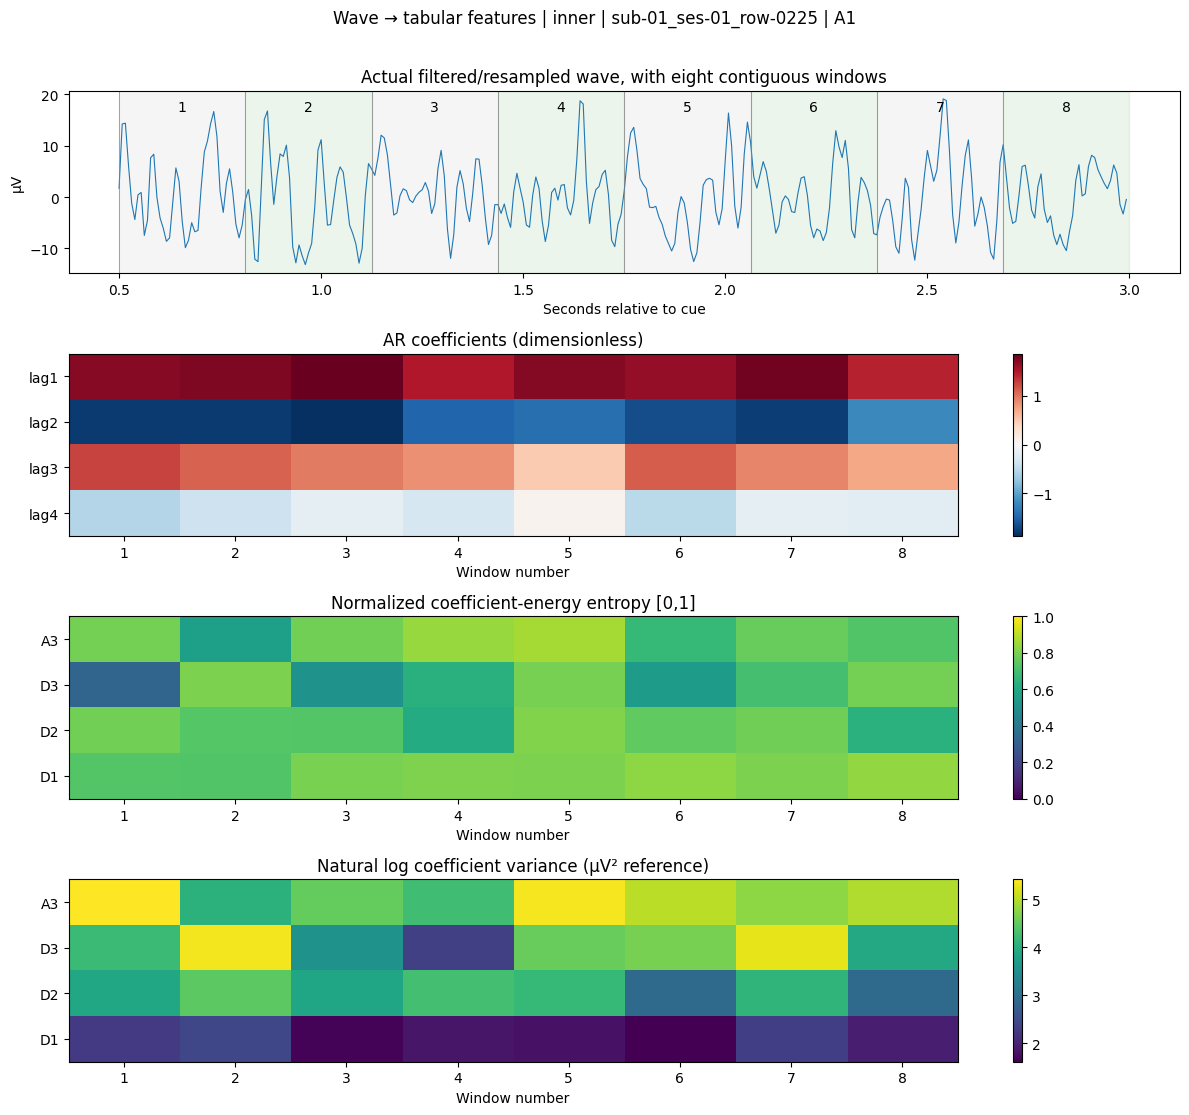

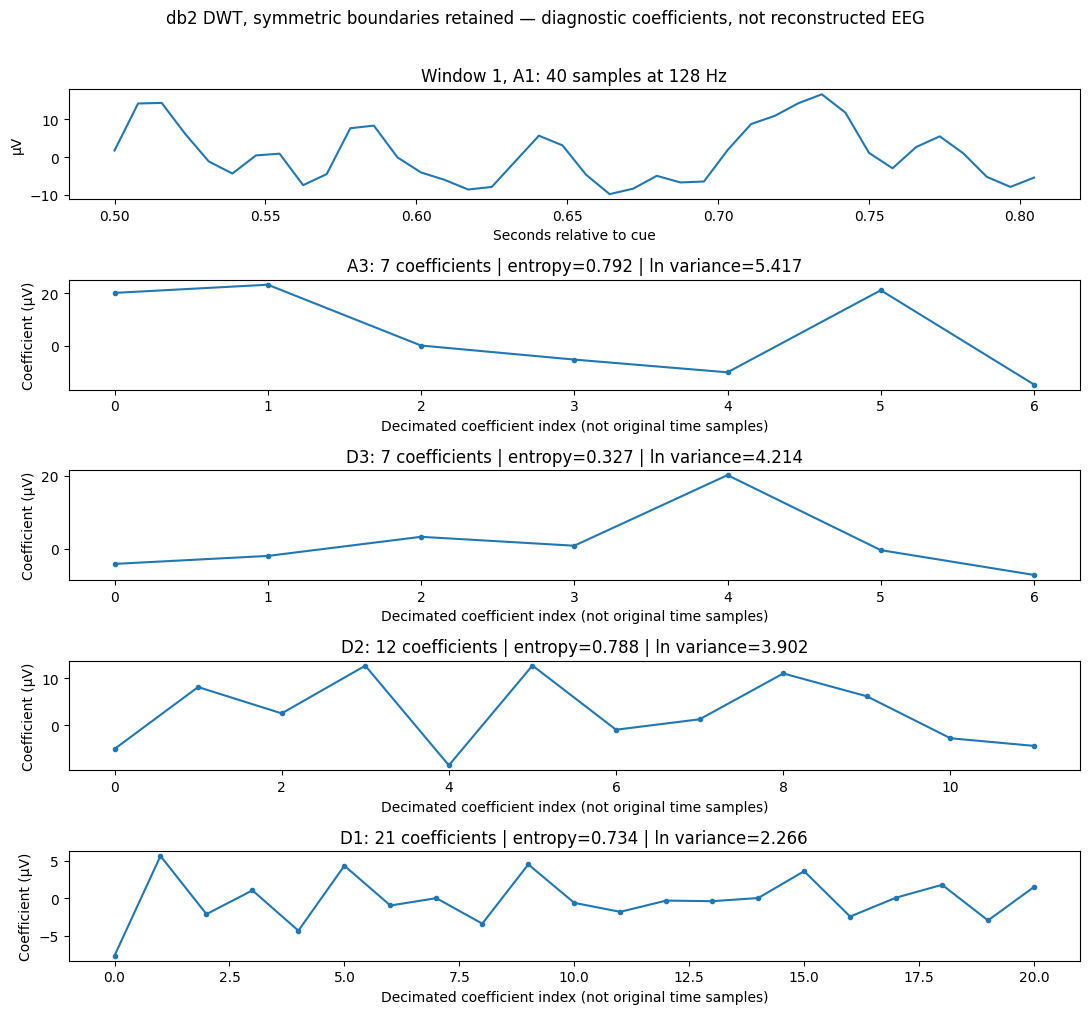

In [27]:
if EDA_FEATURES is not None:
    EDA_FEATURE_CHANNEL = (EDA_CHANNEL if EDA_CHANNEL in EDA_FEATURES["channel_names"]
                           else EDA_FEATURES["channel_names"][0])
    print("Eight-window feature electrode:", EDA_FEATURE_CHANNEL)
    plot_eda_eight_windows(EDA, EDA_FEATURES, trial_index=EDA_TRIAL_INDEX,
                          channel=EDA_FEATURE_CHANNEL)
    plot_eda_wavelet_components(EDA, EDA_FEATURES, trial_index=EDA_TRIAL_INDEX,
        channel=EDA_FEATURE_CHANNEL, window=EDA_WAVELET_WINDOW)

### EDA 7 — descriptive condition/class bandpower

For each trial, average fixed-band power over the feature electrodes, then take median
log power within a class/condition. Panels use the same color range and show their actual
sample counts. This is descriptive training-sample structure, not a statistical significance
test or classification score. Overt-speech activity may include muscle artifacts.


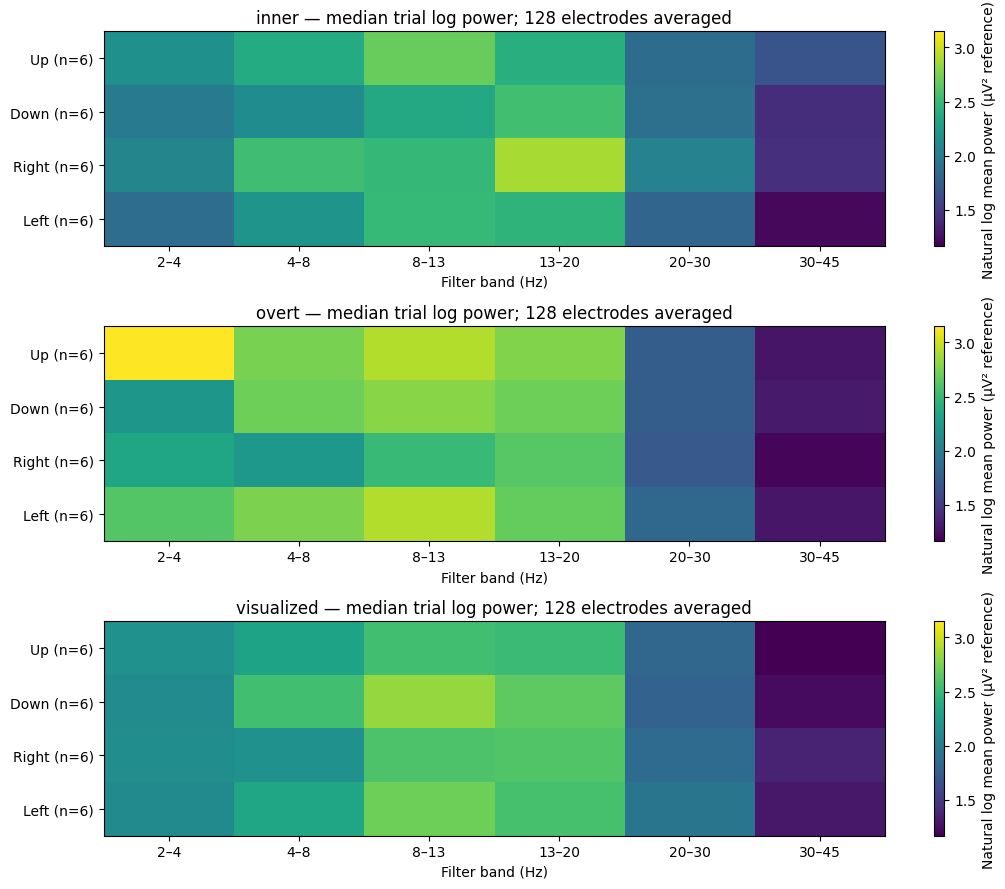

In [28]:
if EDA_FEATURES is not None:
    plot_eda_bandpower(EDA, EDA_FEATURES)

### EDA 8 — optional training-only feature preprocessing preview

For one condition, demonstrate constant-column removal, standardization and ANOVA selection
on the sampled inner-training rows only. The heatmap shows up to 32 selected standardized
feature columns, with labels and a saved schema. It does not train an SVM, evaluate holdouts,
or determine the actual model's selected features. Fold-training recomputes these operations.
Visible separation is expected from supervised selection and is not evidence of accuracy.
This preview requires at least two sampled training trials per class; smaller samples skip it.


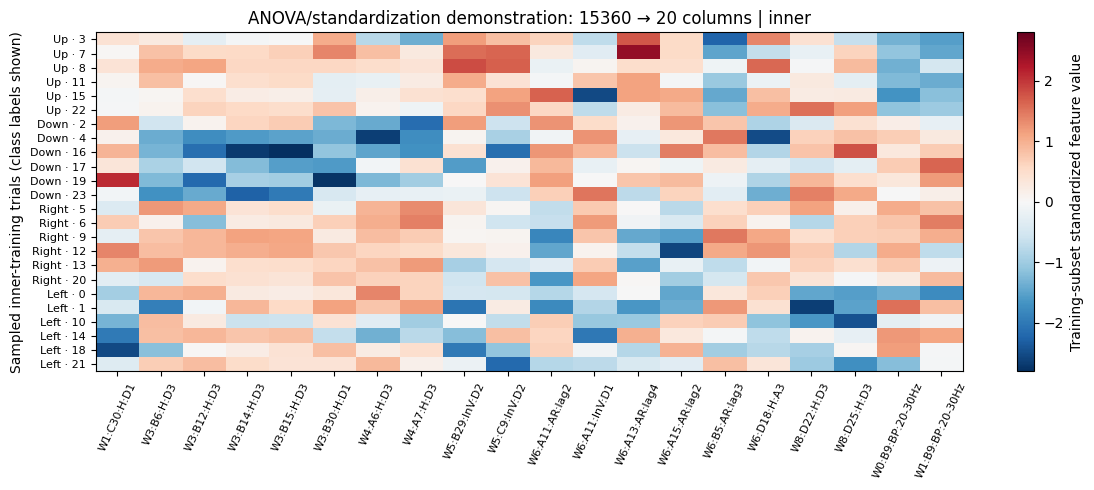

,input_column,feature_name,family,channel,window,component,start_offset_s,stop_offset_s,start_time_cue_s,stop_time_cue_s,start_time_trial_s,stop_time_trial_s,training_ANOVA_F
1123,1123,window01__C30__wavelet_entropy__D1,wavelet_entropy,C30,1,D1,0.0000,0.312500,0.5000,0.812500,1.0000,1.312500,9.218684
3521,3521,window03__B6__wavelet_entropy__D3,wavelet_entropy,B6,3,D3,0.6250,0.937500,1.1250,1.437500,1.6250,1.937500,6.970013
3593,3593,window03__B12__wavelet_entropy__D3,wavelet_entropy,B12,3,D3,0.6250,0.937500,1.1250,1.437500,1.6250,1.937500,9.025532
3617,3617,window03__B14__wavelet_entropy__D3,wavelet_entropy,B14,3,D3,0.6250,0.937500,1.1250,1.437500,1.6250,1.937500,10.631566
3629,3629,window03__B15__wavelet_entropy__D3,wavelet_entropy,B15,3,D3,0.6250,0.937500,1.1250,1.437500,1.6250,1.937500,10.862744
3811,3811,window03__B30__wavelet_entropy__D1,wavelet_entropy,B30,3,D1,0.6250,0.937500,1.1250,1.437500,1.6250,1.937500,14.041792
4673,4673,window04__A6__wavelet_entropy__D3,wavelet_entropy,A6,4,D3,0.9375,1.250000,1.4375,1.750000,1.9375,2.250000,7.839405
4685,4685,window04__A7__wavelet_entropy__D3,wavelet_entropy,A7,4,D3,0.9375,1.250000,1.4375,1.750000,1.9375,2.250000,7.193442
6874,6874,window05__B29__wavelet_log_variance__D2,wavelet_log_variance,B29,5,D2,1.2500,1.562500,1.7500,2.062500,2.2500,2.562500,8.055542
7018,7018,window05__C9__wavelet_log_variance__D2,wavelet_log_variance,C9,5,D2,1.2500,1.562500,1.7500,2.062500,2.2500,2.562500,6.964563


In [29]:
if EDA_FEATURES is not None and RUN_EDA_REDUCTION_PREVIEW:
    EDA_REDUCTION_CONDITION = (cfg.condition_id if cfg.condition_id in EDA["meta"].condition.unique()
                              else int(EDA["meta"].condition.iloc[0]))
    EDA_CLASS_COUNTS = EDA["meta"].loc[
        EDA["meta"].condition == EDA_REDUCTION_CONDITION, "y_true"].value_counts().reindex(CLASSES, fill_value=0)
    if EDA_PARTITION == "inner_train" and EDA_CLASS_COUNTS.min() >= 2:
        EDA_REDUCTION = preview_eda_feature_reduction(EDA, EDA_FEATURES,
            condition=EDA_REDUCTION_CONDITION, dimension=32)
        display(EDA_REDUCTION["schema"])
    else:
        print("ANOVA preview skipped: needs inner_train EDA with at least two trials/class.")

## 3. Optional SVM hard-versus-probability diagnostic

Enable `RUN_SVM_DECISION_AUDIT`. Two fixed linear/RBF SVMs use bandpower, 16 electrodes,
32 selected dimensions and C=1. They fit **only one inner-training partition of the first
outer-training fold**, scoring training and inner validation only. Outer test rows are never
scored here. This is a decision-rule check, not the complete eight-window search or tuning.

Both prediction rules and disagreements are saved. CUDA is used for SVM fits when requested.
All later candidates/folds are audited too, including inner selection, regardless of this switch.


In [30]:
SVM_DECISION_AUDIT = None
if RUN_SVM_DECISION_AUDIT:
    SVM_DECISION_AUDIT = run_svm_prediction_audit(cfg, n_channels=16)
    display(SVM_DECISION_AUDIT)

Subject 01 (inner): 200 trials; counts {0: 50, 1: 50, 2: 50, 3: 50}; median channel SD 10.17 microvolts


,subject,n_channels,kernel,stage,direct_accuracy,direct_balanced_accuracy,probability_argmax_accuracy,probability_argmax_balanced_accuracy,disagreement_rate
0,1,16,linear,training,0.905660,0.905983,0.801887,0.802350,0.179245
1,1,16,linear,inner_validation,0.277778,0.276099,0.259259,0.258242,0.111111
2,1,16,rbf,training,0.971698,0.971510,0.962264,0.962607,0.028302
3,1,16,rbf,inner_validation,0.259259,0.259615,0.259259,0.258242,0.111111


## 4–5. Condition controls, then representation/model experiments

Start inner-only smoke, then repeat overt and visualized as separate controls with
`TRAIN_CONDITIONS=(1,0,2)`. They use identical evaluation rules/budgets, but different trials.
Once checks look sensible, pilot/full searches compare whole-action/late context, long
overlapping scratch crops, eight-window descriptors/fusion, and the existing pretrained
frozen/partial/full modes against scratch neural procedures.

Quality inspection and controls diagnose failure modes; neither guarantees 50%. Short
window descriptors may be noisy, and overlapping views do not increase independent N.


## Optional CUDA check before the experiment

The runner automatically checks CUDA. You can also run this cell separately first.
The success message confirms that GPU binary fitting and four-class prediction were tested.


In [31]:
RUN_CUDA_PREFLIGHT = False
if RUN_CUDA_PREFLIGHT and SVM_BACKEND == "cuda":
    CUDA_SVM_REPORT = cuda_svm_preflight()


## Optional feature-table preview

Enable this cell to inspect four original trials and the schema before training. This extracts
fixed features only; it does not fit a scaler, select features, or train a classifier. Each row
is one original trial. The full raw table has thousands of columns; only the first 12 are shown.


In [32]:
SHOW_FEATURE_PREVIEW = False
if SHOW_FEATURE_PREVIEW:
    subjects = sorted({record[0] for record in discover_recordings(cfg.data_root)})
    subject = subjects[0] if cfg.subject_ids is None else cfg.subject_ids[0]
    preview_eeg, preview_names, preview_meta, _ = load_subject(cfg, subject)
    indices = channel_subsets(preview_names)[cfg.channel_counts[0]]
    names = [preview_names[index] for index in indices]
    feature_spec = next((spec for spec in candidate_list(cfg, "classical")
                         if spec["representation"] in ("eight_window", "bandpower_eight_window")), None)
    if feature_spec is None:
        print("Choose combined or eight_window to preview the new features.")
    else:
        preview_views = SubjectViews(preview_eeg[:4, indices], cfg.expected_sfreq)
        extractor = classical_extractor(feature_spec)
        matrix = extractor.fit_transform(classical_data(preview_views, feature_spec))
        schema = extractor.describe(names)
        table = pd.DataFrame(matrix[:, :12], columns=schema.feature_name.iloc[:12])
        table.insert(0, "trial_id", preview_meta.trial_id.iloc[:len(matrix)].to_numpy())
        print("Raw feature shape (original trials, columns):", matrix.shape)
        display(table)
        display(schema.head(24))
        display(pd.Series(extractor.metadata()))
        del preview_views, matrix, table, extractor
    del preview_eeg

## Easy runner — all enabled pipelines, conditions kept separate

First run the audit and review its output. The integrity gate checks that a successful
audit exists for these source files/subjects/timing conventions. This is an integrity gate,
not a claim that descriptive flags have been adjudicated automatically.

Enable `RUN_EXPERIMENTS` only after review. The first LaBraM run downloads its pinned
public checkpoint. CUDA SVM preflight runs automatically before fitting. Models run
sequentially; channel counts/pipelines share saved original-trial folds within each condition.
Preserve the complete output folder to resume and restore models.


In [ ]:
RESULTS = None
if RUN_EXPERIMENTS:
    RESULTS = run_condition_experiments(cfg, condition_ids=TRAIN_CONDITIONS)
    display(RESULTS["summary"])
else:
    print("Audit first. After review, enable RUN_EXPERIMENTS and rerun settings/configuration/runner.")

CUDA SVM CHECK PASSED: Tesla T4 (device 0); linear/RBF binary fitting and four-class probabilities verified.
Profile=pilot; subjects=[1]; channels=(128,); device=cuda
Each pipeline is selected inside outer training; each original trial receives one OOF prediction per CV seed.
Classical features/scaling: CPU. SVM requested backend: cuda. LDA remains CPU; neural training uses CUDA when available.
CUDA SVM is mandatory: the runner checks actual cuML fitting; no automatic CPU fallback.
 pipeline  candidates  outer_tasks  inner_fits  final_fits_max
classical          26            5         390               5
Subject 01 (inner): 200 trials; counts {0: 50, 1: 50, 2: 50, 3: 50}; median channel SD 10.17 microvolts


classical inner search:   0%|          | 0/26 [00:00<?, ?it/s]

classical | subject 01 | 128ch | fold 1/5 | inner=0.325 | test=0.150


classical inner search:   0%|          | 0/26 [00:00<?, ?it/s]

classical | subject 01 | 128ch | fold 2/5 | inner=0.331 | test=0.250


classical inner search:   0%|          | 0/26 [00:00<?, ?it/s]

classical | subject 01 | 128ch | fold 3/5 | inner=0.338 | test=0.300


classical inner search:   0%|          | 0/26 [00:00<?, ?it/s]

## Results and confusion matrices

Plots show exact trial-level OOF performance. The confusion plot averages subject recall
matrices so subjects with more trials do not dominate. In smoke mode these plots validate
the reporting path only. Confidence intervals require more than one subject.

In [ ]:
if RESULTS is not None:
    for condition_name, result in RESULTS["conditions"].items():
        print("Condition:", condition_name)
        display(result["subject_metrics"])
        plot_results(result)

## Restore saved results without training

Set `SAVED_RUN` to one of the printed `.../runs/<id>` directories. These CSVs are sufficient
for tables and confusion matrices. Keep the complete output root to restore the models too.

In [ ]:
SAVED_RUN = None  # e.g. "/kaggle/working/inner_speech_eight_window_audited/conditions/inner/runs/<id>"
if SAVED_RUN is not None:
    saved = Path(SAVED_RUN)
    restored_results = {
        "directory": saved,
        "oof": pd.read_csv(saved / "oof_predictions.csv"),
        "subject_metrics": pd.read_csv(saved / "subject_metrics.csv"),
        "summary": pd.read_csv(saved / "summary.csv"),
    }
    display(restored_results["summary"])
    plot_results(restored_results)

## Restore a trained fold model without fitting

`predict_saved_fold(bundle_path, action_eeg, channel_names, sfreq, cfg)` returns probabilities.
Pass `return_labels=True` to restore the **primary direct classification decisions**.
For SVM, do not replace those labels with `probabilities.argmax(1)`.

Input must be finite microvolt EEG, ordered as saved, already cropped to canonical
`[1.0,3.5)` = published cue-relative `[0.5,3.0)`, with 640 samples at 256 Hz.
Keep the full output tree so relative neural/encoder paths resolve. Only load trusted pickles.
Corrected timing/decision rules mean old notebook checkpoints cannot substitute for new fits.


## Optional shuffled-label control

This reruns the **complete nested procedure** with labels shuffled within subject/session.
It is off by default because it can cost as much as another experiment. One shuffle is a
basic diagnostic, not a p-value or proof of no leakage. Formal permutation testing needs
many repeats and an exchangeability assumption appropriate to the recording's blocks.
Keep these outputs labeled as diagnostic; they are stored as separate runs.

In [ ]:
RUN_SHUFFLED_LABEL_CONTROL = False
if RUN_SHUFFLED_LABEL_CONTROL:
    null_results = run_permutation_control(cfg, n_permutations=1)
    display(null_results)

## Output map

```text
inner_speech_eight_window_audited/
  investigation/<audit-id>/
    audit_settings.json, audit_manifest.json, recordings.json
    trial_quality.csv, channel_quality.csv
    condition_class_counts.csv, condition_quality_summary.csv
    largest_amplitude_trials.csv, *_outlier-*.png
    raw/                    optional BDF timing tables + matched traces
    svm_inner/              optional train-only decision diagnostic
  eda/<eda-id>/             sampled trial IDs and excluded holdout IDs; plots/PSD tables
    *_eight_window/         original feature arrays, schemas, selected-feature demo
  condition_comparison_summary.csv
  conditions/{inner,overt,visualized}/
    pretrained/, feature_cache/, splits/
    checkpoints/            models, histories, inner selection, integrity hashes
      .../decision_audit.json, svm_backend.json
      .../raw_feature_schema.csv, selected_feature_schema.csv
    runs/<run-id>/
      run_config.json, oof_predictions.csv, fold_metrics.csv
      subject_metrics.csv, subject_seed_metrics.csv, summary.csv
      prediction_rule_audit.csv
      confusion_matrices/, classification_reports/, figures/
```

QC flags do not exclude data. QC source identity uses path/size/mtime; model checkpoint
identity additionally hashes actual EEG/event contents. Preserve all folders for restoration.
Repeated seeds do not create independent subjects. Smoke scores are execution diagnostics.
